venv : python 3.10.10

Example : https://www.kaggle.com/code/ogrellier/home-credit-hyperopt-optimization

In [3]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Application _train_test

## Fusion Train et Test 
Car je vais leur appliquer les meme traitement
Il ne faudra pas oublier de les séparer à nouveau à la fin

In [83]:
num_rows=None
df = pd.read_csv('./input/application_train.csv', nrows= num_rows)
test_df = pd.read_csv('./input/application_test.csv', nrows= num_rows)
print("Train samples: {}, test samples: {}".format(len(df), len(test_df)))

Train samples: 307511, test samples: 48744


In [84]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [85]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
test_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    SK_ID_CURR                    48744 non-null  int64  
 1    NAME_CONTRACT_TYPE            48744 non-null  object 
 2    CODE_GENDER                   48744 non-null  object 
 3    FLAG_OWN_CAR                  48744 non-null  object 
 4    FLAG_OWN_REALTY               48744 non-null  object 
 5    CNT_CHILDREN                  48744 non-null  int64  
 6    AMT_INCOME_TOTAL              48744 non-null  float64
 7    AMT_CREDIT                    48744 non-null  float64
 8    AMT_ANNUITY                   48720 non-null  float64
 9    AMT_GOODS_PRICE               48744 non-null  float64
 10   NAME_TYPE_SUITE               47833 non-null  object 
 11   NAME_INCOME_TYPE              48744 non-null  object 
 12   NAME_EDUCATION_TYPE           48744 non-null

In [87]:
test_df.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df = pd.concat([df, test_df])

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356255 entries, 0 to 48743
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(66), int64(40), object(16)
memory usage: 334.3+ MB


In [90]:
df.loc[df['SK_ID_CURR']==100001]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,NaN,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
df.loc[df['SK_ID_CURR']==100002]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


In [92]:
df.reset_index(inplace=True)

In [93]:
df.loc[(df['SK_ID_CURR']==100001) | (df['SK_ID_CURR']==100002)]

,index,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
307511,0,100001,NaN,Cash loans,F,N,Y,0,135000.0,568800.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Premières explorations et transformations simples

In [94]:
docs = [_f for _f in df.columns if 'FLAG_DOC' in _f]
live = [_f for _f in df.columns if ('FLAG_' in _f) & ('FLAG_DOC' not in _f) & ('_FLAG_' not in _f)]
print(docs, live)

['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'] ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']


TARGET
0.0    282686
NaN     48744
1.0     24825
Name: count, dtype: int64

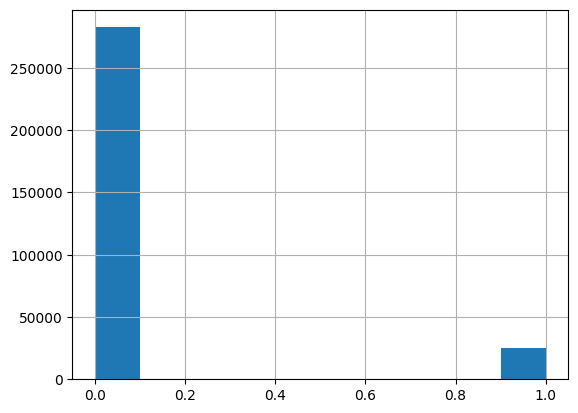

In [95]:
df['TARGET'].hist()
df['TARGET'].value_counts(dropna=False)

In [96]:
df['NAME_CONTRACT_TYPE'].value_counts(dropna=True)

NAME_CONTRACT_TYPE
Cash loans         326537
Revolving loans     29718
Name: count, dtype: int64

<Axes: >

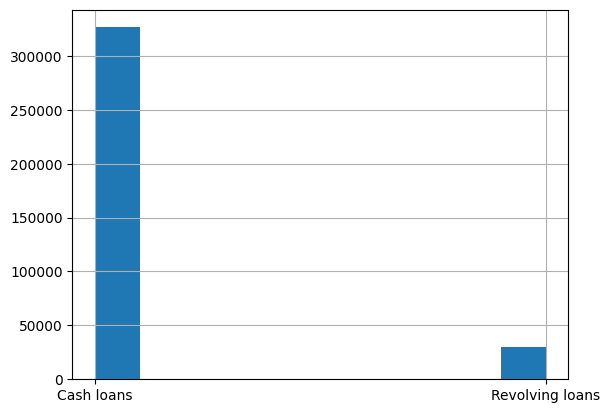

In [97]:
df['NAME_CONTRACT_TYPE'].hist()

In [98]:
# one-hot encoding
df = pd.get_dummies(df, columns=['NAME_CONTRACT_TYPE'], dtype=int)
print(df)

        index  SK_ID_CURR  TARGET CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
0           0      100002     1.0           M            N               Y   
1           1      100003     0.0           F            N               N   
2           2      100004     0.0           M            Y               Y   
3           3      100006     0.0           F            N               Y   
4           4      100007     0.0           M            N               Y   
...       ...         ...     ...         ...          ...             ...   
356250  48739      456221     NaN           F            N               Y   
356251  48740      456222     NaN           F            N               N   
356252  48741      456223     NaN           F            Y               Y   
356253  48742      456224     NaN           M            N               N   
356254  48743      456250     NaN           F            Y               N   

        CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY

In [99]:
# renomme pour eviter les blancs dans le nom des colonnes
df = df.rename(columns={'NAME_CONTRACT_TYPE_Cash loans' : 'NAME_CONTRACT_TYPE_CASH_LOAN',
                       'NAME_CONTRACT_TYPE_Revolving loans':'NAME_CONTRACT_TYPE_REVOLVING_LOAN'})

In [100]:
df.sample(1)

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_CASH_LOAN,NAME_CONTRACT_TYPE_REVOLVING_LOAN
266774,266774,409067,0.0,M,N,Y,0,270000.0,633681.0,30951.0,...,0,0,0.0,0.0,0.0,8.0,2.0,1.0,1,0


<Axes: >

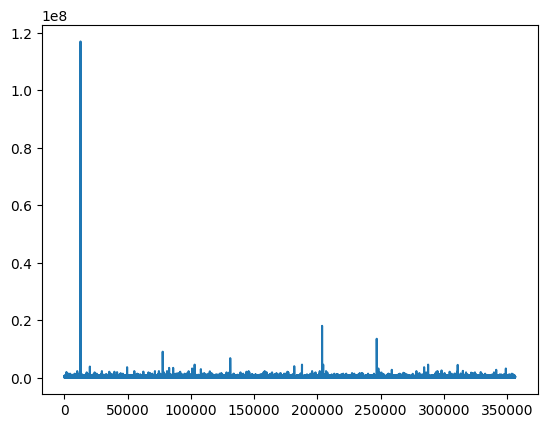

In [101]:
df['AMT_INCOME_TOTAL'].plot()

<Axes: >

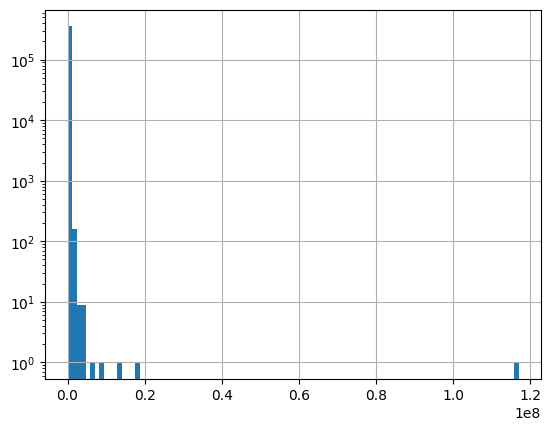

In [102]:
df['AMT_INCOME_TOTAL'].hist(bins=100, log=True)

<Axes: >

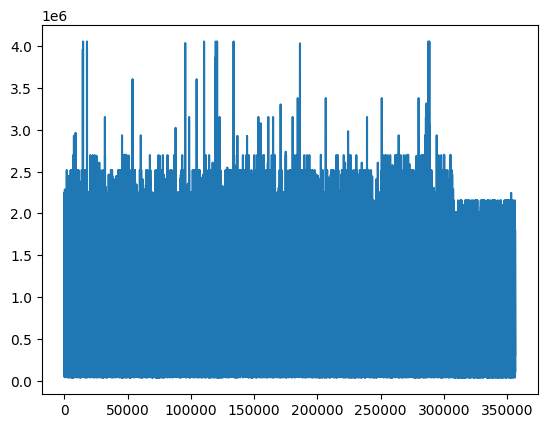

In [103]:
df['AMT_CREDIT'].plot()

<Axes: >

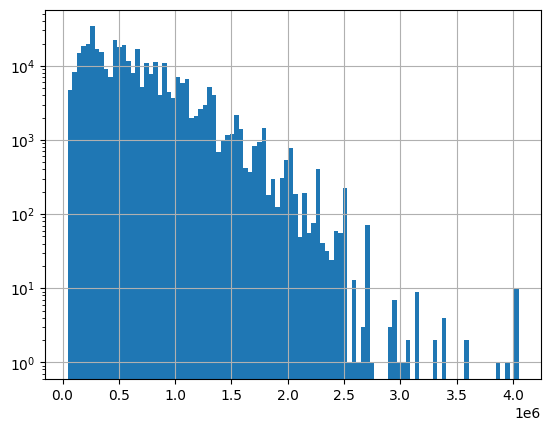

In [104]:
df['AMT_CREDIT'].hist(bins=100, log=True)

<Axes: >

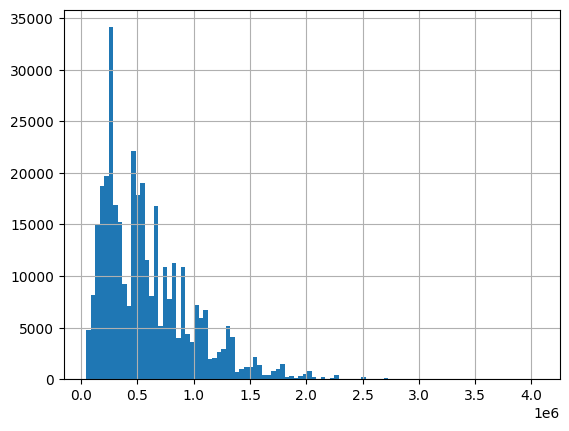

In [105]:
df['AMT_CREDIT'].hist(bins=100)

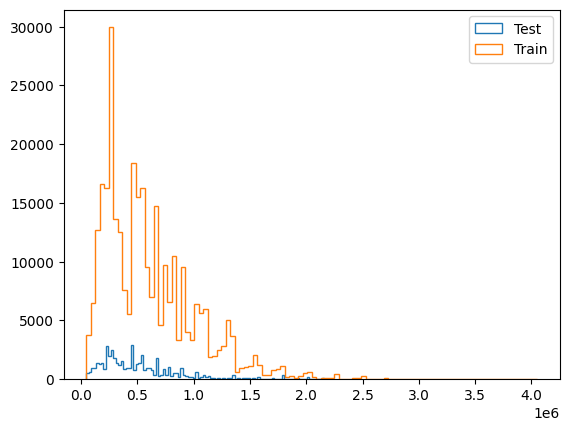

In [106]:
ax = plt.gca()
ax.hist(df.loc[df['TARGET'].isna(), 'AMT_CREDIT'], bins=100, histtype='step', label='Test')
ax.hist(df.loc[~df['TARGET'].isna(), 'AMT_CREDIT'], bins=100, histtype='step', label='Train')
ax.legend()

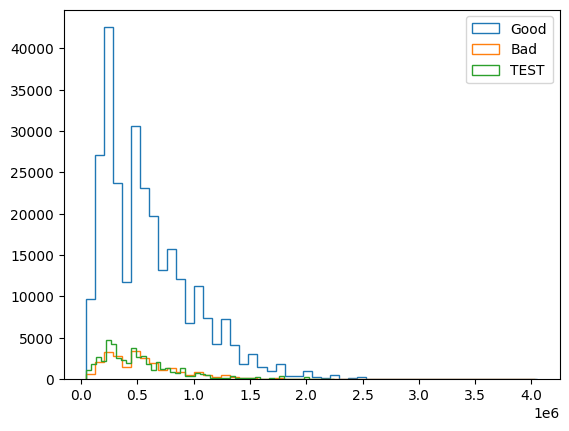

In [107]:
ax = plt.gca()
ax.hist(df.loc[df['TARGET']==0, 'AMT_CREDIT'], label='Good', histtype='step', bins=50)
ax.hist(df.loc[df['TARGET']==1, 'AMT_CREDIT'], label='Bad', histtype='step', bins=50)
ax.hist(df.loc[df['TARGET'].isna(), 'AMT_CREDIT'], label='TEST', histtype='step', bins=50)
ax.legend()

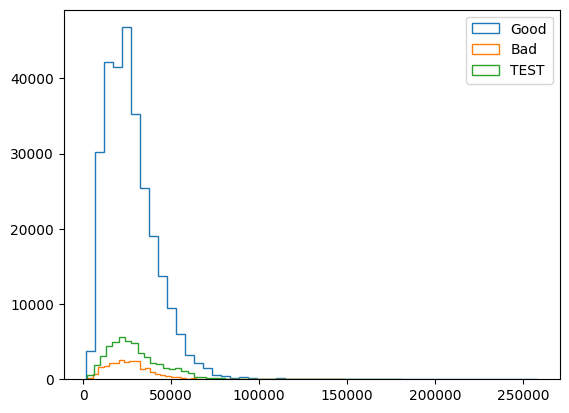

In [108]:
ax = plt.gca()
ax.hist(df.loc[df['TARGET']==0, 'AMT_ANNUITY'], label='Good', histtype='step', bins=50)
ax.hist(df.loc[df['TARGET']==1, 'AMT_ANNUITY'], label='Bad', histtype='step', bins=50)
ax.hist(df.loc[df['TARGET'].isna(), 'AMT_ANNUITY'], label='TEST', histtype='step', bins=50)
ax.legend()

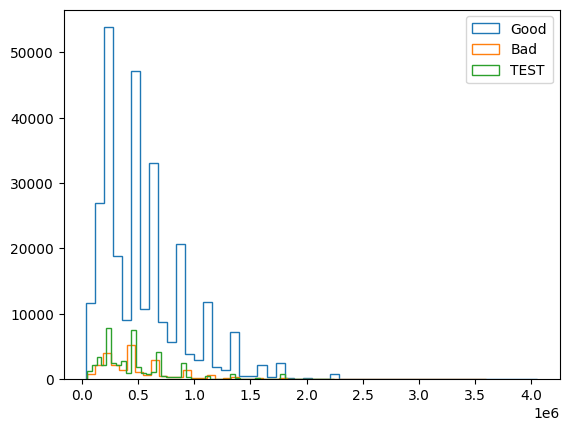

In [109]:
ax = plt.gca()
ax.hist(df.loc[df['TARGET']==0, 'AMT_GOODS_PRICE'], label='Good', histtype='step', bins=50)
ax.hist(df.loc[df['TARGET']==1, 'AMT_GOODS_PRICE'], label='Bad', histtype='step', bins=50)
ax.hist(df.loc[df['TARGET'].isna(), 'AMT_GOODS_PRICE'], label='TEST', histtype='step', bins=50)
ax.legend()

<Axes: >

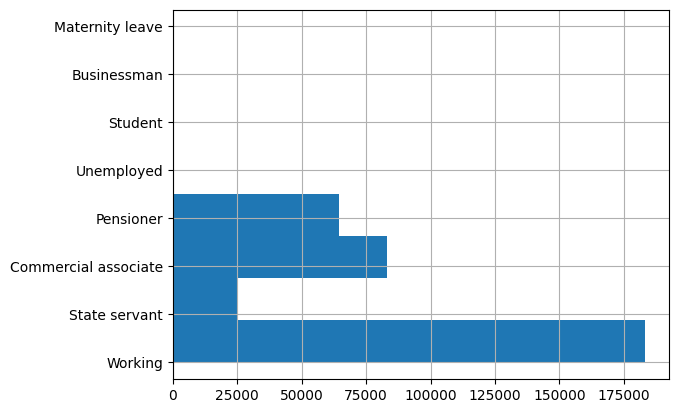

In [110]:
df['NAME_INCOME_TYPE'].hist(orientation='horizontal', bins=len(df['NAME_INCOME_TYPE'].unique()))

In [111]:
df['OCCUPATION_TYPE'].unique()

array(['Laborers', 'Core staff', 'Accountants', 'Managers', nan,
       'Drivers', 'Sales staff', 'Cleaning staff', 'Cooking staff',
       'Private service staff', 'Medicine staff', 'Security staff',
       'High skill tech staff', 'Waiters/barmen staff',
       'Low-skill Laborers', 'Realty agents', 'Secretaries', 'IT staff',
       'HR staff'], dtype=object)

<Axes: >

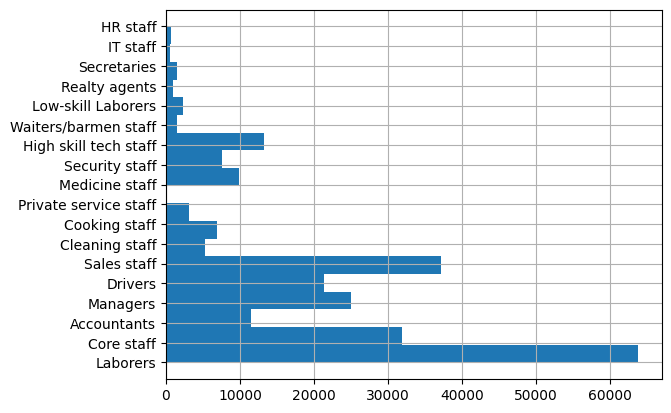

In [112]:
df['OCCUPATION_TYPE'].hist(orientation='horizontal', bins=len(df['OCCUPATION_TYPE'].unique()))

<Axes: >

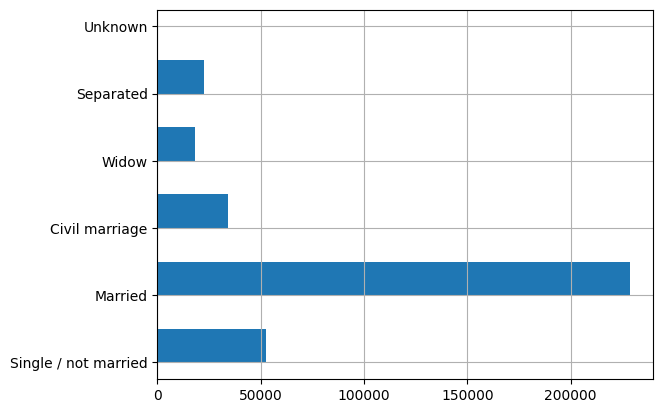

In [113]:
df['NAME_FAMILY_STATUS'].hist(orientation='horizontal')

<Axes: >

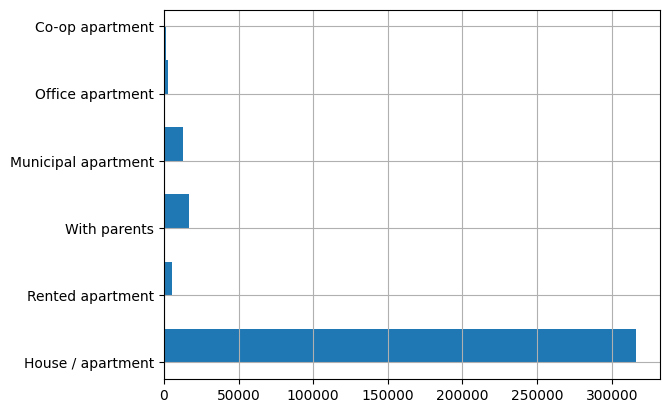

In [114]:
df['NAME_HOUSING_TYPE'].hist(orientation='horizontal')

<Axes: >

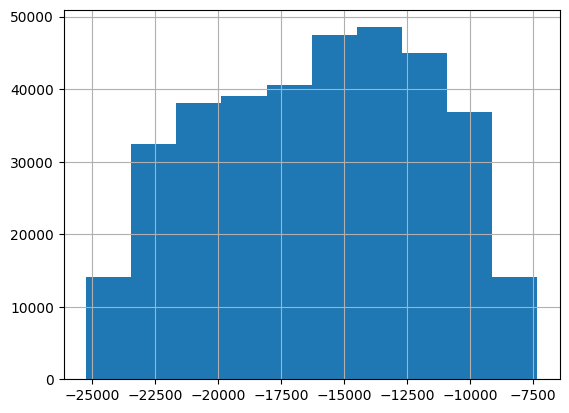

In [115]:
df['DAYS_BIRTH'].hist()

<Axes: >

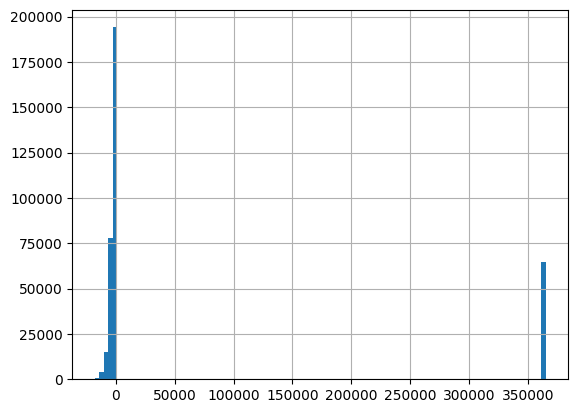

In [116]:
df['DAYS_EMPLOYED'].hist(bins=100)

In [117]:
df.loc[df['DAYS_EMPLOYED'] > 0, 'DAYS_EMPLOYED'].value_counts()

DAYS_EMPLOYED
365243    64648
Name: count, dtype: int64

In [118]:
df.loc[df['DAYS_EMPLOYED'] > 0, :].sample(1).melt().to_numpy()

array([['index', 254392],
       ['SK_ID_CURR', 394377],
       ['TARGET', 0.0],
       ['CODE_GENDER', 'F'],
       ['FLAG_OWN_CAR', 'Y'],
       ['FLAG_OWN_REALTY', 'Y'],
       ['CNT_CHILDREN', 0],
       ['AMT_INCOME_TOTAL', 270000.0],
       ['AMT_CREDIT', 1047501.0],
       ['AMT_ANNUITY', 55939.5],
       ['AMT_GOODS_PRICE', 990000.0],
       ['NAME_TYPE_SUITE', 'Spouse, partner'],
       ['NAME_INCOME_TYPE', 'Pensioner'],
       ['NAME_EDUCATION_TYPE', 'Secondary / secondary special'],
       ['NAME_FAMILY_STATUS', 'Married'],
       ['NAME_HOUSING_TYPE', 'House / apartment'],
       ['REGION_POPULATION_RELATIVE', 0.072508],
       ['DAYS_BIRTH', -22838],
       ['DAYS_EMPLOYED', 365243],
       ['DAYS_REGISTRATION', -3815.0],
       ['DAYS_ID_PUBLISH', -3435],
       ['OWN_CAR_AGE', 0.0],
       ['FLAG_MOBIL', 1],
       ['FLAG_EMP_PHONE', 0],
       ['FLAG_WORK_PHONE', 0],
       ['FLAG_CONT_MOBILE', 1],
       ['FLAG_PHONE', 0],
       ['FLAG_EMAIL', 0],
       ['OCCUPATION_

In [119]:
df.loc[df['DAYS_EMPLOYED'] > 0, ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']].value_counts(dropna=False)

NAME_INCOME_TYPE  OCCUPATION_TYPE  ORGANIZATION_TYPE
Pensioner         NaN              XNA                  64623
Unemployed        NaN              XNA                     23
Pensioner         Cleaning staff   XNA                      2
Name: count, dtype: int64

In [120]:
df.loc[df['ORGANIZATION_TYPE'] == 'XNA', 'NAME_INCOME_TYPE'].value_counts(dropna=False)

NAME_INCOME_TYPE
Pensioner     64625
Unemployed       23
Name: count, dtype: int64

In [121]:
df['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 183307
Commercial associate     83019
Pensioner                64635
State servant            25235
Unemployed                  23
Student                     20
Businessman                 11
Maternity leave              5
Name: count, dtype: int64

In [122]:
df['DAYS_EMPLOYED'].describe()

count    356255.000000
mean      64317.231413
std      141705.532576
min      -17912.000000
25%       -2781.000000
50%       -1224.000000
75%        -290.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [123]:
# pour les retraités DAYS_EMPLOYED est fixé à 365243 days
# je le fixe à la moyenne (hormi cette valeur bien entendu)
print('Valeur moyenne DAYS_EMPLOYED (uniquement sur les valeurs négatives) :', df.loc[df['DAYS_EMPLOYED']<=0, 'DAYS_EMPLOYED'].mean())
df.loc[df['DAYS_EMPLOYED'] > 0, 'DAYS_EMPLOYED'] = df.loc[df['DAYS_EMPLOYED']<=0, 'DAYS_EMPLOYED'].mean()
df['DAYS_EMPLOYED'].describe()

Valeur moyenne DAYS_EMPLOYED (uniquement sur les valeurs négatives) : -2396.6989372683097


C:\Users\innov\AppData\Local\Temp\ipykernel_17836\1981469973.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-2396.6989372683097' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['DAYS_EMPLOYED'] > 0, 'DAYS_EMPLOYED'] = df.loc[df['DAYS_EMPLOYED']<=0, 'DAYS_EMPLOYED'].mean()


count    356255.000000
mean      -2396.698937
std        2112.070957
min      -17912.000000
25%       -2781.000000
50%       -2243.000000
75%        -949.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

<Axes: >

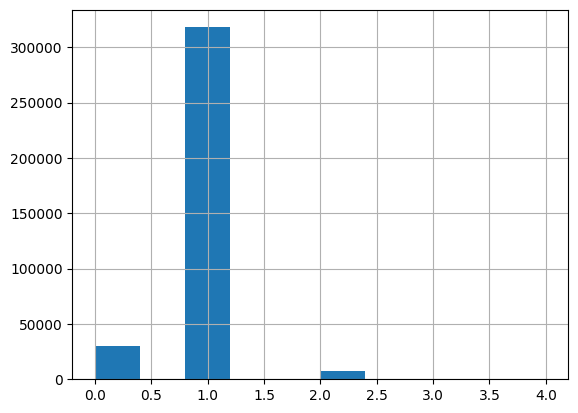

In [124]:
# Nombre total de doc fourni
docs = [_f for _f in df.columns if 'FLAG_DOC' in _f]
df['CNT_DOC_TOTAL'] = df[docs].sum(axis=1)
df['CNT_DOC_TOTAL'].hist()

In [125]:
df[docs].sample(10)

,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
270113,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
351910,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
327876,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
262657,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
120360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
285006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
107370,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
309828,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
201915,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
49284,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<Axes: >

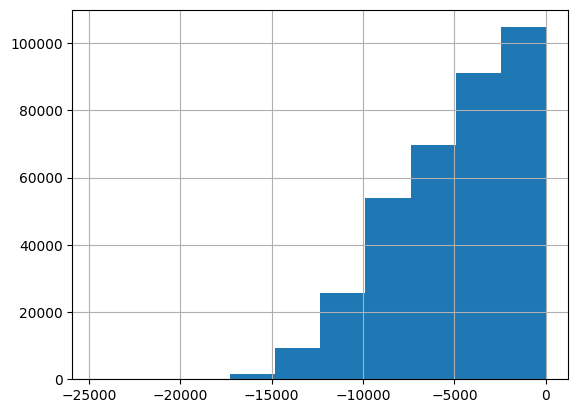

In [126]:
df['DAYS_REGISTRATION'].hist()

<Axes: >

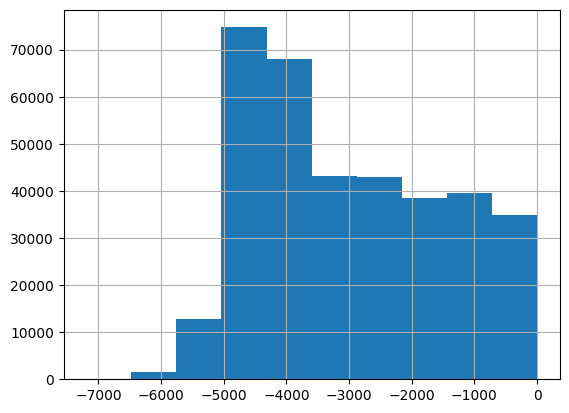

In [127]:
df['DAYS_ID_PUBLISH'].hist()

<Axes: >

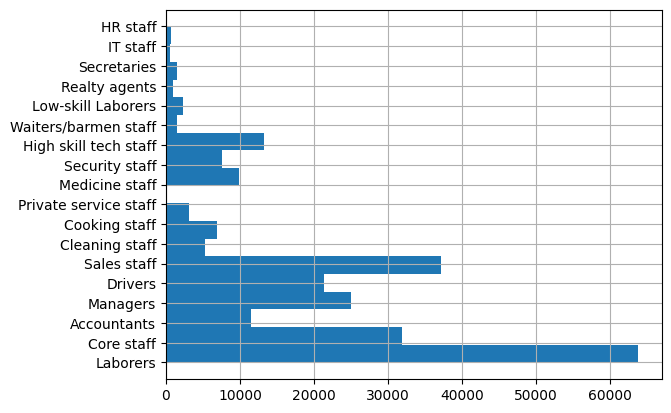

In [128]:
df['OCCUPATION_TYPE'].hist(orientation='horizontal', bins=len(df['OCCUPATION_TYPE'].unique()))

<Axes: >

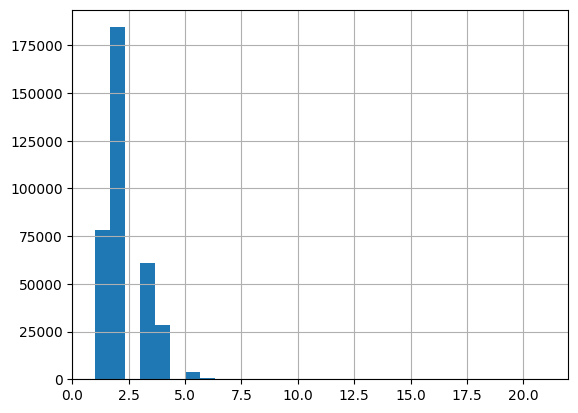

In [129]:
df['CNT_FAM_MEMBERS'].hist(bins=30)

<Axes: >

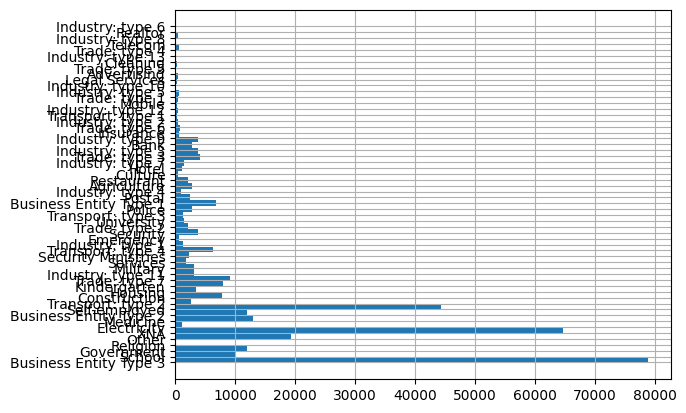

In [130]:
df['ORGANIZATION_TYPE'].hist(orientation='horizontal', bins=len(df['ORGANIZATION_TYPE'].unique()))

In [131]:
df['ORGANIZATION_TYPE'].value_counts(dropna=False)

ORGANIZATION_TYPE
Business Entity Type 3    78832
XNA                       64648
Self-employed             44332
Other                     19390
Medicine                  12909
Business Entity Type 2    12032
Government                11912
School                    10180
Trade: type 7              9134
Kindergarten               7918
Construction               7760
Business Entity Type 1     6871
Transport: type 4          6282
Trade: type 3              4070
Industry: type 9           3867
Industry: type 3           3767
Security                   3719
Housing                    3393
Military                   3164
Industry: type 11          3120
Bank                       2881
Police                     2782
Agriculture                2746
Transport: type 2          2652
Postal                     2451
Security Ministries        2315
Trade: type 2              2142
Restaurant                 2095
Services                   1877
University                 1548
Industry: type 7      

In [132]:
df['FLAG_DOCUMENT_2'].value_counts()

FLAG_DOCUMENT_2
0    356242
1        13
Name: count, dtype: int64

<Axes: >

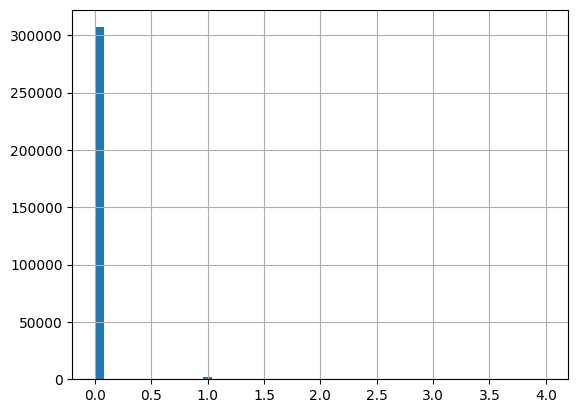

In [133]:
df['AMT_REQ_CREDIT_BUREAU_HOUR'].hist(bins=50)

<Axes: >

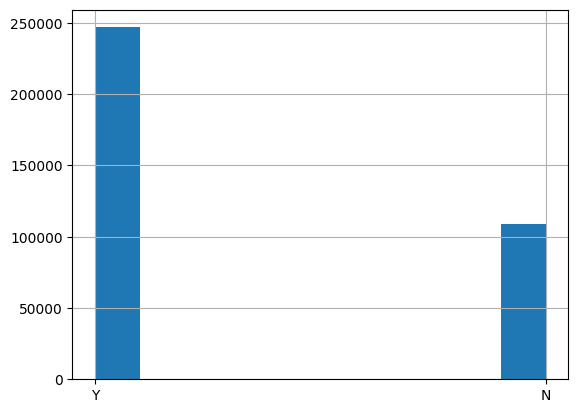

In [134]:
df['FLAG_OWN_REALTY'].hist()

In [135]:
# remplacer par valeur numérique
df.loc[df['FLAG_OWN_REALTY'] == 'Y', 'FLAG_OWN_REALTY'] = 1
df.loc[df['FLAG_OWN_REALTY'] == 'N', 'FLAG_OWN_REALTY'] = 0

<Axes: >

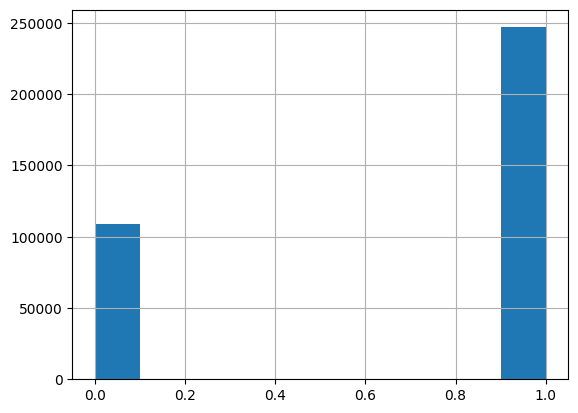

In [136]:
df['FLAG_OWN_REALTY'].hist()

In [137]:
df[['AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   AMT_INCOME_TOTAL  356255 non-null  float64
 1   CNT_FAM_MEMBERS   356253 non-null  float64
dtypes: float64(2)
memory usage: 5.4 MB


In [138]:
df.loc[df['CNT_FAM_MEMBERS'].isna(), :]

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_CASH_LOAN,NAME_CONTRACT_TYPE_REVOLVING_LOAN,CNT_DOC_TOTAL
41982,41982,148605,0.0,M,N,1,0,450000.0,675000.0,33750.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1
187348,187348,317181,0.0,F,N,1,0,202500.0,585000.0,29250.0,...,0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,1


In [139]:
df['CNT_FAM_MEMBERS'].value_counts()

CNT_FAM_MEMBERS
2.0     184411
1.0      78098
3.0      60774
4.0      28387
5.0       3990
6.0        451
7.0         93
8.0         22
9.0          7
10.0         6
13.0         3
14.0         2
12.0         2
20.0         2
16.0         2
15.0         1
11.0         1
21.0         1
Name: count, dtype: int64

In [140]:
# imputation à 1.0
df.loc[df['CNT_FAM_MEMBERS'].isna(), 'CNT_FAM_MEMBERS'] = 1.0

In [141]:
df['RATIO_INCOME_TO_FAM_MEMBERS'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

<Axes: >

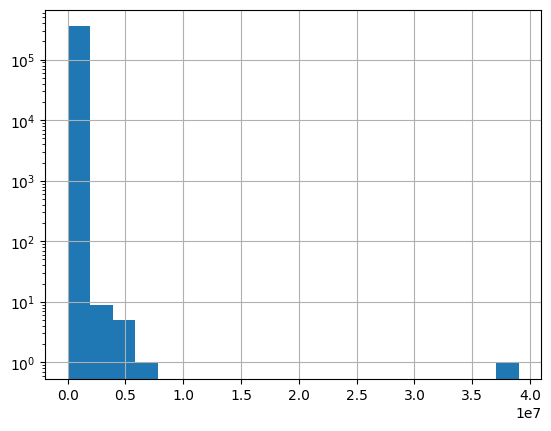

In [142]:
df['RATIO_INCOME_TO_FAM_MEMBERS'].hist(bins=20, log=True)

In [143]:
df.loc[df['AMT_INCOME_TOTAL']>1E8, :].melt().to_numpy()

array([['index', 12840],
       ['SK_ID_CURR', 114967],
       ['TARGET', 1.0],
       ['CODE_GENDER', 'F'],
       ['FLAG_OWN_CAR', 'N'],
       ['FLAG_OWN_REALTY', 1],
       ['CNT_CHILDREN', 1],
       ['AMT_INCOME_TOTAL', 117000000.0],
       ['AMT_CREDIT', 562491.0],
       ['AMT_ANNUITY', 26194.5],
       ['AMT_GOODS_PRICE', 454500.0],
       ['NAME_TYPE_SUITE', 'Unaccompanied'],
       ['NAME_INCOME_TYPE', 'Working'],
       ['NAME_EDUCATION_TYPE', 'Secondary / secondary special'],
       ['NAME_FAMILY_STATUS', 'Married'],
       ['NAME_HOUSING_TYPE', 'House / apartment'],
       ['REGION_POPULATION_RELATIVE', 0.010643],
       ['DAYS_BIRTH', -12615],
       ['DAYS_EMPLOYED', -922.0],
       ['DAYS_REGISTRATION', -6762.0],
       ['DAYS_ID_PUBLISH', -3643],
       ['OWN_CAR_AGE', nan],
       ['FLAG_MOBIL', 1],
       ['FLAG_EMP_PHONE', 1],
       ['FLAG_WORK_PHONE', 0],
       ['FLAG_CONT_MOBILE', 1],
       ['FLAG_PHONE', 0],
       ['FLAG_EMAIL', 0],
       ['OCCUPATION_TYPE'

In [144]:
df.loc[df['AMT_GOODS_PRICE'].isna(), 'NAME_CONTRACT_TYPE_REVOLVING_LOAN'].value_counts(dropna=False)

NAME_CONTRACT_TYPE_REVOLVING_LOAN
1    278
Name: count, dtype: int64

In [145]:
df.loc[df['NAME_CONTRACT_TYPE_REVOLVING_LOAN']==1, 'AMT_GOODS_PRICE'].describe()

count    2.944000e+04
mean     3.248995e+05
std      2.379516e+05
min      4.500000e+04
25%      1.800000e+05
50%      2.700000e+05
75%      3.600000e+05
max      2.250000e+06
Name: AMT_GOODS_PRICE, dtype: float64

In [146]:
# Imputation AMT_GOOD_PRICE à la valeur moyenne pour les contract de type Revolving
val_mean = df.loc[df['NAME_CONTRACT_TYPE_REVOLVING_LOAN']==1, 'AMT_GOODS_PRICE'].mean()
df.loc[df['AMT_GOODS_PRICE'].isna(), 'AMT_GOODS_PRICE'] = val_mean

In [147]:
df.loc[df['NAME_CONTRACT_TYPE_REVOLVING_LOAN']==1, 'AMT_GOODS_PRICE'].describe()

count    2.971800e+04
mean     3.248995e+05
std      2.368360e+05
min      4.500000e+04
25%      1.800000e+05
50%      2.700000e+05
75%      3.600000e+05
max      2.250000e+06
Name: AMT_GOODS_PRICE, dtype: float64

In [148]:
df.loc[df['AMT_GOODS_PRICE'].isna(), 'NAME_CONTRACT_TYPE_REVOLVING_LOAN'].value_counts(dropna=False)

Series([], Name: count, dtype: int64)

In [149]:
# Creation ratio 
df['RATIO_AMT_CREDIT_TO_AMT_GOODS_PRICE'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

<Axes: >

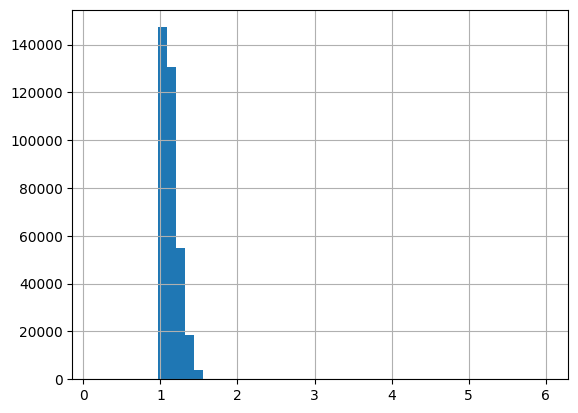

In [150]:
df['RATIO_AMT_CREDIT_TO_AMT_GOODS_PRICE'].hist(bins=50)

In [151]:
# Flag les types d'emplois STABLE : Pensioner OU State servant
def stable_income_type(income_type) :
    if (income_type == 'State servant') | (income_type == 'Pensioner') :
        return 1
    else :
        return 0

df['FLAG_STABLE_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].apply(stable_income_type)

In [152]:
df['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 183307
Commercial associate     83019
Pensioner                64635
State servant            25235
Unemployed                  23
Student                     20
Businessman                 11
Maternity leave              5
Name: count, dtype: int64

In [153]:
df['FLAG_STABLE_INCOME_TYPE'].value_counts()

FLAG_STABLE_INCOME_TYPE
0    266385
1     89870
Name: count, dtype: int64

In [154]:
df['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    78832
XNA                       64648
Self-employed             44332
Other                     19390
Medicine                  12909
Business Entity Type 2    12032
Government                11912
School                    10180
Trade: type 7              9134
Kindergarten               7918
Construction               7760
Business Entity Type 1     6871
Transport: type 4          6282
Trade: type 3              4070
Industry: type 9           3867
Industry: type 3           3767
Security                   3719
Housing                    3393
Military                   3164
Industry: type 11          3120
Bank                       2881
Police                     2782
Agriculture                2746
Transport: type 2          2652
Postal                     2451
Security Ministries        2315
Trade: type 2              2142
Restaurant                 2095
Services                   1877
University                 1548
Industry: type 7      

In [155]:
# Flag ORGANIZATION TYPE Les plus risquées = Self employed
df['FLAG_RISKED_ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(lambda x : 1 if x == 'Self-employed' else 0)

In [156]:
df.loc[df['FLAG_RISKED_ORGANIZATION_TYPE'] == 1, ['ORGANIZATION_TYPE']].value_counts()

ORGANIZATION_TYPE
Self-employed        44332
Name: count, dtype: int64

In [157]:
list_col = [col for col in df.columns if col.startswith('AMT_REQ_CREDIT_BUREAU_')]

In [158]:
list_col

['AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_YEAR']

In [159]:
df[list_col].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 6 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AMT_REQ_CREDIT_BUREAU_HOUR  308687 non-null  float64
 1   AMT_REQ_CREDIT_BUREAU_DAY   308687 non-null  float64
 2   AMT_REQ_CREDIT_BUREAU_WEEK  308687 non-null  float64
 3   AMT_REQ_CREDIT_BUREAU_MON   308687 non-null  float64
 4   AMT_REQ_CREDIT_BUREAU_QRT   308687 non-null  float64
 5   AMT_REQ_CREDIT_BUREAU_YEAR  308687 non-null  float64
dtypes: float64(6)
memory usage: 16.3 MB


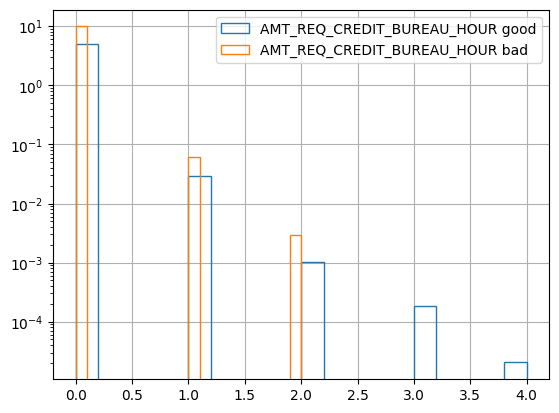

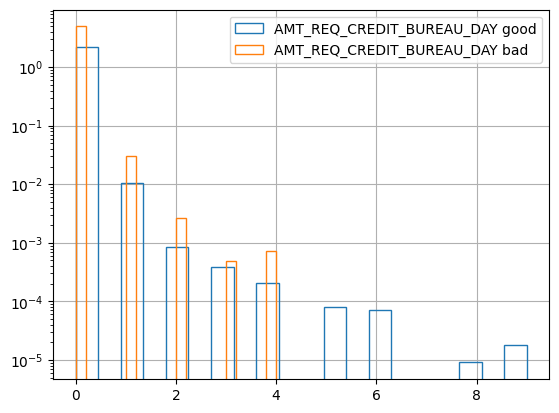

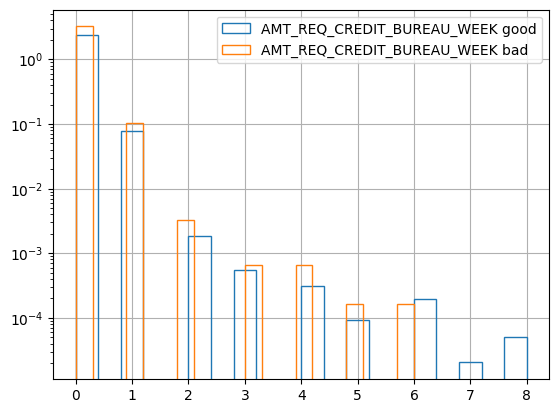

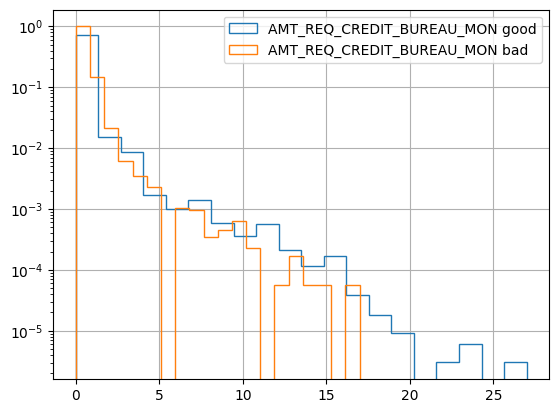

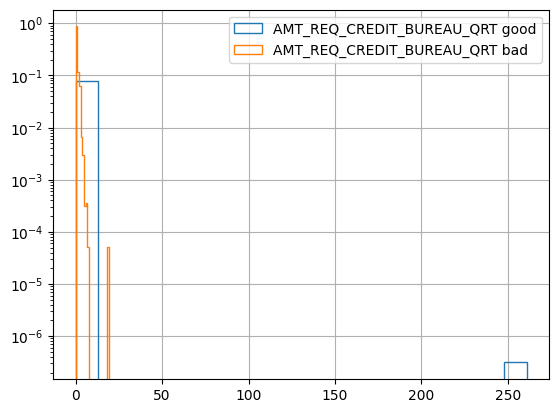

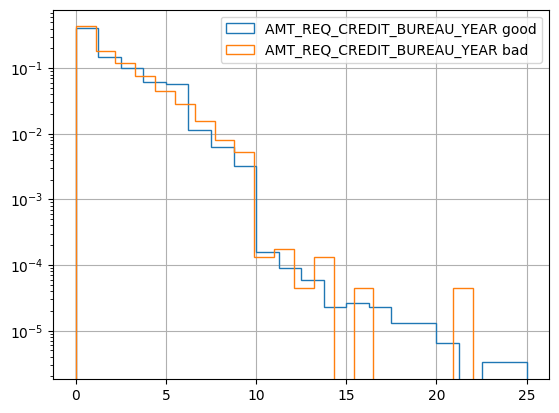

In [160]:
for col in list_col :
    df.loc[df['TARGET'] == 0, col].hist(log=True, density=True, histtype='step', label=col+' good', bins=20)
    df.loc[df['TARGET'] == 1, col].hist(log=True, density=True, histtype='step', label=col+' bad', bins=20)
    plt.legend()
    plt.show()

In [161]:
# Création compteur nb de requete dans la semaine précédente
df['NEW_AMT_REQ_CREDIT_BUREAU_WEEK'] = df['AMT_REQ_CREDIT_BUREAU_HOUR'] + df['AMT_REQ_CREDIT_BUREAU_DAY'] + df['AMT_REQ_CREDIT_BUREAU_WEEK']

# Crédit de Credit Bureau

## Premières explorations bureau_credit et bureau_balance

In [162]:
bureau = pd.read_csv('./input/bureau.csv')
bb = pd.read_csv('./input/bureau_balance.csv')

In [163]:
bureau.shape

(1716428, 17)

In [164]:
bb.shape

(27299925, 3)

In [165]:
bureau.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   SK_ID_CURR              1716428 non-null  int64  
 1   SK_ID_BUREAU            1716428 non-null  int64  
 2   CREDIT_ACTIVE           1716428 non-null  object 
 3   CREDIT_CURRENCY         1716428 non-null  object 
 4   DAYS_CREDIT             1716428 non-null  int64  
 5   CREDIT_DAY_OVERDUE      1716428 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     1610875 non-null  float64
 7   DAYS_ENDDATE_FACT       1082775 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  591940 non-null   float64
 9   CNT_CREDIT_PROLONG      1716428 non-null  int64  
 10  AMT_CREDIT_SUM          1716415 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     1458759 non-null  float64
 12  AMT_CREDIT_SUM_LIMIT    1124648 non-null  float64
 13  AMT_CREDIT_SUM_OVERDUE  1716428 non-null  float64
 14  CR

In [166]:
bureau.loc[bureau['AMT_CREDIT_SUM'].isna(), :]

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
218508,405791,6008179,Active,currency 1,0,0,NaN,NaN,NaN,0,NaN,654993.0,NaN,0.0,Another type of loan,-5,NaN
314570,418331,6064357,Active,currency 1,0,0,NaN,NaN,NaN,0,NaN,2250000.0,NaN,0.0,Another type of loan,-16,NaN
572703,367465,6299480,Active,currency 1,0,0,388.0,NaN,NaN,0,NaN,1204582.5,NaN,0.0,Another type of loan,-5,NaN
585311,371162,6452468,Closed,currency 1,0,0,NaN,-111.0,NaN,0,NaN,0.0,NaN,0.0,Another type of loan,-64,NaN
590328,209921,5491946,Closed,currency 1,-5,0,NaN,-46.0,NaN,0,NaN,0.0,NaN,0.0,Another type of loan,-36,NaN
814128,425959,6388671,Active,currency 1,0,0,NaN,NaN,NaN,0,NaN,185926.5,NaN,0.0,Another type of loan,-3,NaN
987620,375588,5078559,Active,currency 1,0,0,NaN,NaN,NaN,0,NaN,1309572.0,NaN,0.0,Another type of loan,-39,NaN
1055762,118044,6753699,Active,currency 1,-422,0,643.0,NaN,NaN,0,NaN,0.0,NaN,0.0,Consumer credit,-29,15979.5
1113131,139064,6121986,Closed,currency 1,0,0,NaN,-72.0,NaN,0,NaN,0.0,NaN,0.0,Another type of loan,-23,NaN
1172368,207533,5875729,Closed,currency 1,0,0,NaN,-441.0,NaN,0,NaN,0.0,NaN,0.0,Another type of loan,-77,NaN


In [167]:
# Je cut les qq crédits dont je n'ai pas le montant (je mets en doute la qualité de ces données)
bureau = bureau.loc[~bureau['AMT_CREDIT_SUM'].isna(), :]
bureau.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1716415 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   SK_ID_CURR              1716415 non-null  int64  
 1   SK_ID_BUREAU            1716415 non-null  int64  
 2   CREDIT_ACTIVE           1716415 non-null  object 
 3   CREDIT_CURRENCY         1716415 non-null  object 
 4   DAYS_CREDIT             1716415 non-null  int64  
 5   CREDIT_DAY_OVERDUE      1716415 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     1610871 non-null  float64
 7   DAYS_ENDDATE_FACT       1082770 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  591940 non-null   float64
 9   CNT_CREDIT_PROLONG      1716415 non-null  int64  
 10  AMT_CREDIT_SUM          1716415 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     1458746 non-null  float64
 12  AMT_CREDIT_SUM_LIMIT    1124648 non-null  float64
 13  AMT_CREDIT_SUM_OVERDUE  1716415 non-null  float64
 14  CREDIT_

In [168]:
bureau['CREDIT_ACTIVE'].value_counts(dropna=False)

CREDIT_ACTIVE
Closed      1079268
Active       630599
Sold           6527
Bad debt         21
Name: count, dtype: int64

In [169]:
bureau['CREDIT_TYPE'].value_counts(dropna=False)

CREDIT_TYPE
Consumer credit                                 1251612
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1007
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                                  1
Interbank credit                                      1
Name: count, dtype: int64

In [170]:
bureau['CREDIT_CURRENCY'].value_counts(dropna=False)

CREDIT_CURRENCY
currency 1    1715007
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

In [171]:
# je ne garde que "currency 1" ne sachant pas ce que cela représente, je fais l'hypothèse que la currency de loin la plus nombreuse est le dollar US
bureau = bureau.loc[bureau['CREDIT_CURRENCY'] == 'currency 1', :]
bureau.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1715007 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   SK_ID_CURR              1715007 non-null  int64  
 1   SK_ID_BUREAU            1715007 non-null  int64  
 2   CREDIT_ACTIVE           1715007 non-null  object 
 3   CREDIT_CURRENCY         1715007 non-null  object 
 4   DAYS_CREDIT             1715007 non-null  int64  
 5   CREDIT_DAY_OVERDUE      1715007 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     1609563 non-null  float64
 7   DAYS_ENDDATE_FACT       1081559 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  591636 non-null   float64
 9   CNT_CREDIT_PROLONG      1715007 non-null  int64  
 10  AMT_CREDIT_SUM          1715007 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     1457631 non-null  float64
 12  AMT_CREDIT_SUM_LIMIT    1124251 non-null  float64
 13  AMT_CREDIT_SUM_OVERDUE  1715007 non-null  float64
 14  CREDIT_

<Axes: >

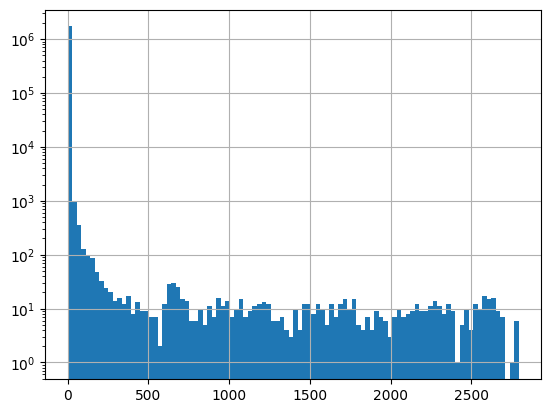

In [172]:
bureau['CREDIT_DAY_OVERDUE'].hist(bins=100, log=True)

<Axes: >

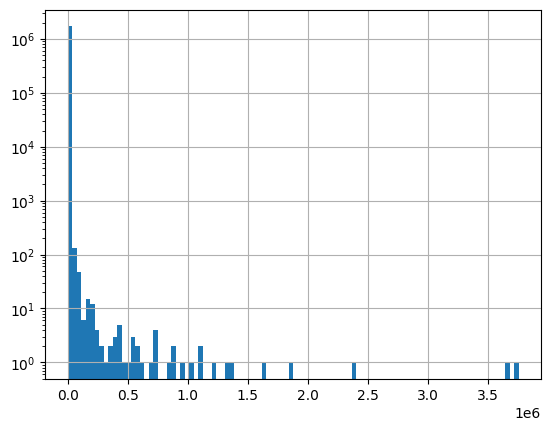

In [173]:
bureau['AMT_CREDIT_SUM_OVERDUE'].hist(bins=100, log=True)

## Vérification bonne compréhension des données de montant et overdue

### Quelques anomalies sur les montants

In [174]:
bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1715007 entries, 0 to 1716427
Data columns (total 4 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   CREDIT_ACTIVE           1715007 non-null  object 
 1   AMT_CREDIT_SUM          1715007 non-null  float64
 2   AMT_CREDIT_SUM_DEBT     1457631 non-null  float64
 3   AMT_CREDIT_SUM_OVERDUE  1715007 non-null  float64
dtypes: float64(3), object(1)
memory usage: 65.4+ MB


In [175]:
bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].groupby('CREDIT_ACTIVE').count()

,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE
CREDIT_ACTIVE,,,
Active,630418,556898,630418
Bad debt,21,15,21
Closed,1078057,897770,1078057
Sold,6511,2948,6511


In [176]:
bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].groupby('CREDIT_ACTIVE').describe().stack()

C:\Users\innov\AppData\Local\Temp\ipykernel_17836\1895386979.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].groupby('CREDIT_ACTIVE').describe().stack()


AMT_CREDIT_SUM  AMT_CREDIT_SUM_DEBT  \
CREDIT_ACTIVE                                              
Active        count    6.304180e+05         5.568980e+05   
              mean     5.301368e+05         3.517565e+05   
              std      1.227231e+06         1.027819e+06   
              min      0.000000e+00        -4.705600e+06   
              25%      9.000000e+04         5.647500e+03   
              50%      2.125125e+05         9.725400e+04   
              75%      4.950000e+05         3.062205e+05   
              max      1.701000e+08         1.701000e+08   
Bad debt      count    2.100000e+01         1.500000e+01   
              mean     1.496275e+05         3.212889e+04   
              std      1.412059e+05         6.670514e+04   
              min      1.429650e+04         0.000000e+00   
              25%      5.755050e+04         0.000000e+00   
              50%      1.035000e+05         0.000000e+00   
              75%      1.845000e+05         3.858750e+03   
              max      5.281650e+05         1.826326e+05   
Closed        count    1.078057e+06         8.977700e+05   
              mean     2.423311e+05         2.878667e+03   
              std      9.889765e+05         8.987605e+04   
              min      0.000000e+00        -4.551905e+05   
              25%      4.354776e+04         0.000000e+00   
              50%      9.211500e+04         0.000000e+00   
              75%      2.250000e+05         0.000000e+00   
              max      5.850000e+08         5.175000e+07   
Sold          count    6.511000e+03         2.948000e+03   
              mean     1.047077e+06         1.758937e+05   
              std      2.308368e+06         1.078197e+06   
              min      0.000000e+00         0.000000e+00   
              25%      1.011195e+05         0.000000e+00   
              50%      2.250000e+05         0.000000e+00   
              75%      7.862625e+05         0.000000e+00   
              max      5.294250e+07         1.867695e+07   

                     AMT_CREDIT_SUM_OVERDUE  
CREDIT_ACTIVE                                
Active        count            6.304180e+05  
              mean             8.976614e+01  
              std              9.103574e+03  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              0.000000e+00  
              max              3.756681e+06  
Bad debt      count            2.100000e+01  
              mean             4.581803e+04  
              std              1.191981e+05  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              7.717500e+03  
              max              5.033925e+05  
Closed        count            1.078057e+06  
              mean             2.683595e+00  
              std              1.920872e+03  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              0.000000e+00  
              max              1.851210e+06  
Sold          count            6.511000e+03  
              mean             7.107920e+02  
              std              2.465134e+04  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              0.000000e+00  
              max              1.329597e+06

Des crédits avec des montants nuls ?

In [177]:
bureau.loc[bureau['AMT_CREDIT_SUM'] == 0.0, :].sample(1).stack()

1020558  SK_ID_CURR                     155047
         SK_ID_BUREAU                  5939789
         CREDIT_ACTIVE                  Closed
         CREDIT_CURRENCY            currency 1
         DAYS_CREDIT                     -2788
         CREDIT_DAY_OVERDUE                  0
         DAYS_ENDDATE_FACT              -333.0
         CNT_CREDIT_PROLONG                  0
         AMT_CREDIT_SUM                    0.0
         AMT_CREDIT_SUM_DEBT               0.0
         AMT_CREDIT_SUM_OVERDUE            0.0
         CREDIT_TYPE               Credit card
         DAYS_CREDIT_UPDATE               -262
         AMT_ANNUITY                       0.0
dtype: object

In [178]:
bureau.loc[bureau['AMT_CREDIT_SUM'] == 0.0, ['CREDIT_TYPE', 'SK_ID_BUREAU']].count()

CREDIT_TYPE     66575
SK_ID_BUREAU    66575
dtype: int64

In [179]:
bureau.loc[bureau['AMT_CREDIT_SUM'] == 0.0, ['CREDIT_TYPE', 'SK_ID_BUREAU']].groupby(['CREDIT_TYPE']).count()

,SK_ID_BUREAU
CREDIT_TYPE,
Another type of loan,580
Consumer credit,143
Credit card,65851
Mortgage,1


In [180]:
bureau.loc[(bureau['AMT_CREDIT_SUM'] == 0.0) & (bureau['CREDIT_TYPE'] != 'Credit card'), :].sample(1).stack()

505785  SK_ID_CURR                              240734
        SK_ID_BUREAU                           6534151
        CREDIT_ACTIVE                           Closed
        CREDIT_CURRENCY                     currency 1
        DAYS_CREDIT                              -1555
        CREDIT_DAY_OVERDUE                           0
        DAYS_ENDDATE_FACT                       -839.0
        CNT_CREDIT_PROLONG                           0
        AMT_CREDIT_SUM                             0.0
        AMT_CREDIT_SUM_DEBT                        0.0
        AMT_CREDIT_SUM_LIMIT                       0.0
        AMT_CREDIT_SUM_OVERDUE                     0.0
        CREDIT_TYPE               Another type of loan
        DAYS_CREDIT_UPDATE                         -93
dtype: object

Des encours NaN ?

In [181]:
bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'].isna(), ['SK_ID_BUREAU']].count()

SK_ID_BUREAU    257376
dtype: int64

In [182]:
bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'].isna(), ['SK_ID_BUREAU', 'CREDIT_ACTIVE']].groupby('CREDIT_ACTIVE').count()

,SK_ID_BUREAU
CREDIT_ACTIVE,
Active,73520
Bad debt,6
Closed,180287
Sold,3563


In [183]:
bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'].isna(), :].sample(1).stack()

495472  SK_ID_CURR                         219750
        SK_ID_BUREAU                      6447708
        CREDIT_ACTIVE                      Closed
        CREDIT_CURRENCY                currency 1
        DAYS_CREDIT                         -2744
        CREDIT_DAY_OVERDUE                      0
        DAYS_CREDIT_ENDDATE               -2439.0
        DAYS_ENDDATE_FACT                 -2439.0
        AMT_CREDIT_MAX_OVERDUE                0.0
        CNT_CREDIT_PROLONG                      0
        AMT_CREDIT_SUM                   450000.0
        AMT_CREDIT_SUM_OVERDUE                0.0
        CREDIT_TYPE               Consumer credit
        DAYS_CREDIT_UPDATE                  -2434
dtype: object

In [184]:
# Impute les encours de crédit NaN à 0
bureau['AMT_CREDIT_SUM_DEBT'] = bureau['AMT_CREDIT_SUM_DEBT'].fillna(0)
bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1715007 entries, 0 to 1716427
Data columns (total 4 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   CREDIT_ACTIVE           1715007 non-null  object 
 1   AMT_CREDIT_SUM          1715007 non-null  float64
 2   AMT_CREDIT_SUM_DEBT     1715007 non-null  float64
 3   AMT_CREDIT_SUM_OVERDUE  1715007 non-null  float64
dtypes: float64(3), object(1)
memory usage: 65.4+ MB


Des encours de crédit négatifs ?

In [185]:
bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'] < 0.0, ['SK_ID_BUREAU']].count()

SK_ID_BUREAU    8416
dtype: int64

In [186]:
bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'] >= 0.0, ['SK_ID_BUREAU']].count()

SK_ID_BUREAU    1706591
dtype: int64

In [187]:
bureau.shape

(1715007, 17)

In [188]:
# je coupe les crédit à l'encours négatif
bureau = bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'] >= 0.0, :]

In [189]:
bureau.shape

(1706591, 17)

Pour les crédits clos, il reste du débit

In [190]:
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Closed', ['AMT_CREDIT_SUM_DEBT']].describe()

,AMT_CREDIT_SUM_DEBT
count,1.075861e+06
mean,2.404009e+03
std,8.210663e+04
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,5.175000e+07


In [191]:
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Closed', ['AMT_CREDIT_SUM_DEBT']].describe()

,AMT_CREDIT_SUM_DEBT
count,1.075861e+06
mean,2.404009e+03
std,8.210663e+04
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,5.175000e+07


<Axes: >

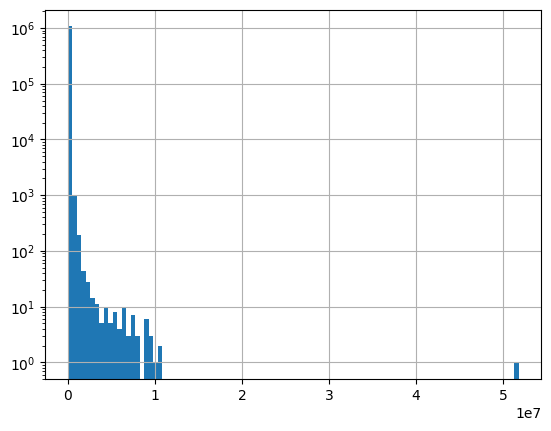

In [192]:
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Closed', 'AMT_CREDIT_SUM_DEBT'].hist(bins=100, log=True)

<Axes: >

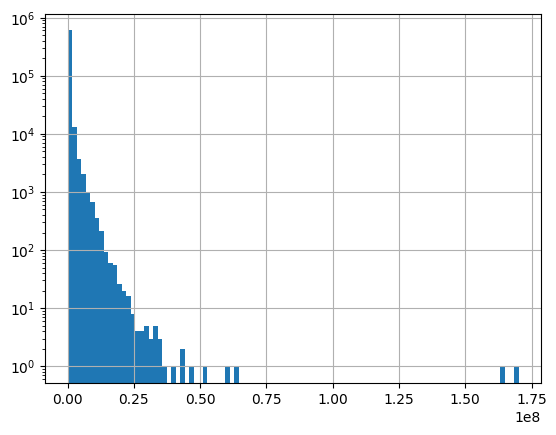

In [193]:
bureau.loc[bureau['CREDIT_ACTIVE'] == 'Active', 'AMT_CREDIT_SUM_DEBT'].hist(bins=100, log=True)

<Axes: >

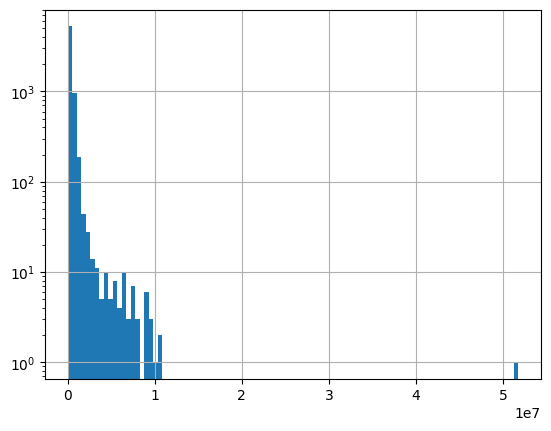

In [194]:
bureau.loc[(bureau['CREDIT_ACTIVE'] == 'Closed') & (bureau['AMT_CREDIT_SUM_DEBT'] > 0.0), 'AMT_CREDIT_SUM_DEBT'].hist(bins=100, log=True)

In [195]:
bureau.loc[(bureau['CREDIT_ACTIVE'] == 'Closed') & (bureau['AMT_CREDIT_SUM_DEBT'] > 0.0), 'AMT_CREDIT_SUM_DEBT'].count()

6580

In [196]:
bureau.loc[(bureau['CREDIT_ACTIVE'] == 'Closed') & (bureau['AMT_CREDIT_SUM_DEBT'] == 0.0), 'AMT_CREDIT_SUM_DEBT'].count()

1069281

Je les garde

In [197]:
bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].groupby('CREDIT_ACTIVE').describe().stack()

C:\Users\innov\AppData\Local\Temp\ipykernel_17836\1895386979.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].groupby('CREDIT_ACTIVE').describe().stack()


AMT_CREDIT_SUM  AMT_CREDIT_SUM_DEBT  \
CREDIT_ACTIVE                                              
Active        count    6.241980e+05         6.241980e+05   
              mean     5.347674e+05         3.139328e+05   
              std      1.232396e+06         9.768433e+05   
              min      0.000000e+00         0.000000e+00   
              25%      9.000000e+04         0.000000e+00   
              50%      2.205000e+05         7.019550e+04   
              75%      4.950000e+05         2.607885e+05   
              max      1.701000e+08         1.701000e+08   
Bad debt      count    2.100000e+01         2.100000e+01   
              mean     1.496275e+05         2.294921e+04   
              std      1.412059e+05         5.775727e+04   
              min      1.429650e+04         0.000000e+00   
              25%      5.755050e+04         0.000000e+00   
              50%      1.035000e+05         0.000000e+00   
              75%      1.845000e+05         0.000000e+00   
              max      5.281650e+05         1.826326e+05   
Closed        count    1.075861e+06         1.075861e+06   
              mean     2.425016e+05         2.404009e+03   
              std      9.899573e+05         8.210663e+04   
              min      0.000000e+00         0.000000e+00   
              25%      4.348800e+04         0.000000e+00   
              50%      9.191250e+04         0.000000e+00   
              75%      2.250000e+05         0.000000e+00   
              max      5.850000e+08         5.175000e+07   
Sold          count    6.511000e+03         6.511000e+03   
              mean     1.047077e+06         7.963980e+04   
              std      2.308368e+06         7.306989e+05   
              min      0.000000e+00         0.000000e+00   
              25%      1.011195e+05         0.000000e+00   
              50%      2.250000e+05         0.000000e+00   
              75%      7.862625e+05         0.000000e+00   
              max      5.294250e+07         1.867695e+07   

                     AMT_CREDIT_SUM_OVERDUE  
CREDIT_ACTIVE                                
Active        count            6.241980e+05  
              mean             9.066064e+01  
              std              9.148815e+03  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              0.000000e+00  
              max              3.756681e+06  
Bad debt      count            2.100000e+01  
              mean             4.581803e+04  
              std              1.191981e+05  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              7.717500e+03  
              max              5.033925e+05  
Closed        count            1.075861e+06  
              mean             2.689073e+00  
              std              1.922831e+03  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              0.000000e+00  
              max              1.851210e+06  
Sold          count            6.511000e+03  
              mean             7.107920e+02  
              std              2.465134e+04  
              min              0.000000e+00  
              25%              0.000000e+00  
              50%              0.000000e+00  
              75%              0.000000e+00  
              max              1.329597e+06

CREDIT_MAX_OVERDUE a beaucoup de NaN

In [198]:
bureau[['CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_CREDIT_MAX_OVERDUE']].info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1706591 entries, 0 to 1716427
Data columns (total 5 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   CREDIT_ACTIVE           1706591 non-null  object 
 1   AMT_CREDIT_SUM          1706591 non-null  float64
 2   AMT_CREDIT_SUM_DEBT     1706591 non-null  float64
 3   AMT_CREDIT_SUM_OVERDUE  1706591 non-null  float64
 4   AMT_CREDIT_MAX_OVERDUE  583220 non-null   float64
dtypes: float64(4), object(1)
memory usage: 78.1+ MB


J'impute MAX_OVERDUE à 0

In [199]:
bureau['AMT_CREDIT_MAX_OVERDUE'] = bureau['AMT_CREDIT_MAX_OVERDUE'].fillna(0)

In [200]:
bureau.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1706591 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   SK_ID_CURR              1706591 non-null  int64  
 1   SK_ID_BUREAU            1706591 non-null  int64  
 2   CREDIT_ACTIVE           1706591 non-null  object 
 3   CREDIT_CURRENCY         1706591 non-null  object 
 4   DAYS_CREDIT             1706591 non-null  int64  
 5   CREDIT_DAY_OVERDUE      1706591 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     1601147 non-null  float64
 7   DAYS_ENDDATE_FACT       1079363 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  1706591 non-null  float64
 9   CNT_CREDIT_PROLONG      1706591 non-null  int64  
 10  AMT_CREDIT_SUM          1706591 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     1706591 non-null  float64
 12  AMT_CREDIT_SUM_LIMIT    1115835 non-null  float64
 13  AMT_CREDIT_SUM_OVERDUE  1706591 non-null  float64
 14  CREDIT_

In [201]:
bureau[['AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_CREDIT_MAX_OVERDUE']].describe()

,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE,AMT_CREDIT_MAX_OVERDUE
count,1.706591e+06,1.706591e+06,1.706591e+06,1.706591e+06
mean,3.524684e+05,1.166428e+05,3.813064e+01,1.258080e+03
std,1.102395e+06,6.146294e+05,5.954737e+03,1.194466e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.166857e+04,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.255500e+05,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.150000e+05,3.986415e+03,0.000000e+00,0.000000e+00
max,5.850000e+08,1.701000e+08,3.756681e+06,1.159872e+08


### Tous les crédits dans bureau non pas d'enregistrement dans bureau_balance ?

In [202]:
bb.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Non-Null Count     Dtype 
---  ------          --------------     ----- 
 0   SK_ID_BUREAU    27299925 non-null  int64 
 1   MONTHS_BALANCE  27299925 non-null  int64 
 2   STATUS          27299925 non-null  object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [203]:
print('nb valeur unique dans bureau : ', bureau['SK_ID_BUREAU'].nunique(), ' et dans Bureau_balance :', bb['SK_ID_BUREAU'].nunique())

nb valeur unique dans bureau :  1706591  et dans Bureau_balance : 817395


In [204]:
list_sk_id_bureau = bb['SK_ID_BUREAU'].unique()
bureau.loc[~bureau['SK_ID_BUREAU'].isin(list_sk_id_bureau), ['SK_ID_BUREAU', 'CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].groupby('CREDIT_ACTIVE').count()

,SK_ID_BUREAU,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE
CREDIT_ACTIVE,,,,
Active,343100,343100,343100,343100
Bad debt,18,18,18,18
Closed,586963,586963,586963,586963
Sold,3584,3584,3584,3584


In [205]:
list_sk_id_bureau = bb['SK_ID_BUREAU'].unique()
bureau.loc[bureau['SK_ID_BUREAU'].isin(list_sk_id_bureau), ['SK_ID_BUREAU', 'CREDIT_ACTIVE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE']].groupby('CREDIT_ACTIVE').count()

,SK_ID_BUREAU,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE
CREDIT_ACTIVE,,,,
Active,281098,281098,281098,281098
Bad debt,3,3,3,3
Closed,488898,488898,488898,488898
Sold,2927,2927,2927,2927


Je n'arrive pas à comprendre pourquoi 

In [206]:
import random
id_test = random.choice(list_sk_id_bureau)
bb.loc[bb['SK_ID_BUREAU'] == id_test, :]

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
3688356,6025721,0,C
3688357,6025721,-1,C
3688358,6025721,-2,C
3688359,6025721,-3,C
3688360,6025721,-4,C
3688361,6025721,-5,C
3688362,6025721,-6,C
3688363,6025721,-7,C
3688364,6025721,-8,C
3688365,6025721,-9,C


In [207]:
# Je regarde un crédit au hasard
id_test = bureau.loc[bureau['CREDIT_ACTIVE'] == 'Active', 'SK_ID_BUREAU'].sample(1).to_list()[0]
bureau.loc[bureau['SK_ID_BUREAU'] == id_test, :].melt()

,variable,value
0,SK_ID_CURR,153420
1,SK_ID_BUREAU,5659700
2,CREDIT_ACTIVE,Active
3,CREDIT_CURRENCY,currency 1
4,DAYS_CREDIT,-212
5,CREDIT_DAY_OVERDUE,0
6,DAYS_CREDIT_ENDDATE,2345.0
7,DAYS_ENDDATE_FACT,NaN
8,AMT_CREDIT_MAX_OVERDUE,0.0
9,CNT_CREDIT_PROLONG,0


In [208]:
bb.loc[bb['SK_ID_BUREAU'] == id_test, :]

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
12330508,5659700,0,0
12330509,5659700,-1,0
12330510,5659700,-2,0
12330511,5659700,-3,0
12330512,5659700,-4,0
12330513,5659700,-5,0
12330514,5659700,-6,0
12330515,5659700,-7,0


## Calcul Aggrégas

In [209]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1706591 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 234.4+ MB


In [267]:
bureau_agg = bureau.groupby(['SK_ID_CURR']).agg({'SK_ID_BUREAU' : 'count',
                                                 'AMT_CREDIT_SUM' : 'sum',
                                                 'AMT_CREDIT_SUM_DEBT' : 'sum',
                                                 'AMT_CREDIT_SUM_OVERDUE' : 'sum',
                                                 'AMT_CREDIT_MAX_OVERDUE' : 'max'})

bureau_agg.rename(columns={'SK_ID_BUREAU': 'CNT_CREDIT',
                           'AMT_CREDIT_SUM': 'AMT_CREDIT_SUM',
                           'AMT_CREDIT_MAX_OVERDUE': 'AMT_CREDIT_MAX_OVERDUE',
                           'AMT_CREDIT_SUM_DEBT': 'AMT_CREDIT_SUM_DEBT',
                           'AMT_CREDIT_SUM_OVERDUE': 'AMT_CREDIT_SUM_OVERDUE'},
                 inplace=True)
bureau_agg

,CNT_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE,AMT_CREDIT_MAX_OVERDUE
SK_ID_CURR,,,,,
100001,7,1453365.000,596686.500,0.0,0.000
100002,8,865055.565,245781.000,0.0,5043.645
100003,4,1017400.500,0.000,0.0,0.000
100004,2,189037.800,0.000,0.0,0.000
100005,3,657126.000,568408.500,0.0,0.000
...,...,...,...,...,...
456249,13,3693858.660,163071.000,0.0,18945.000
456250,3,3086459.550,2232040.095,0.0,0.000
456253,4,3960000.000,1795833.000,0.0,0.000


In [268]:
bureau_agg.reset_index(inplace=True)
bureau_agg.head()

,SK_ID_CURR,CNT_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE,AMT_CREDIT_MAX_OVERDUE
0,100001,7,1453365.000,596686.5,0.0,0.000
1,100002,8,865055.565,245781.0,0.0,5043.645
2,100003,4,1017400.500,0.0,0.0,0.000
3,100004,2,189037.800,0.0,0.0,0.000
4,100005,3,657126.000,568408.5,0.0,0.000


In [269]:
bureau_agg.describe()

,SK_ID_CURR,CNT_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE,AMT_CREDIT_MAX_OVERDUE
count,305702.000000,305702.000000,3.057020e+05,3.057020e+05,3.057020e+05,3.057020e+05
mean,278048.224585,5.582531,1.967666e+06,6.511623e+05,2.128655e+02,5.943363e+03
std,102849.770332,4.396329,4.011969e+06,1.611479e+06,1.569441e+04,2.819727e+05
min,100001.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,188879.250000,2.000000,3.456289e+05,0.000000e+00,0.000000e+00,0.000000e+00
50%,277894.500000,4.000000,9.749844e+05,1.734412e+05,0.000000e+00,0.000000e+00
75%,367186.750000,8.000000,2.335212e+06,6.763095e+05,0.000000e+00,1.302750e+02
max,456255.000000,116.000000,1.017958e+09,3.344983e+08,3.756681e+06,1.159872e+08


# Historique des crédits dans Home Credit

## Sélection des applications ayant donné un crédit

In [212]:
previous_app = pd.read_csv('./input/previous_application.csv')
pos_cash = pd.read_csv('./input/POS_CASH_balance.csv')
installment= pd.read_csv('./input/installments_payments.csv')
credit_card = pd.read_csv('./input/credit_card_balance.csv')

In [213]:
print('previous_app', previous_app.shape, 'pos_cash', pos_cash.shape, 'installment', installment.shape, 'credit_card', credit_card.shape)

previous_app (1670214, 37) pos_cash (10001358, 8) installment (13605401, 8) credit_card (3840312, 23)


In [214]:
previous_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [215]:
previous_app.sample(1).stack()

1146714  SK_ID_PREV                                     1493229
         SK_ID_CURR                                      109258
         NAME_CONTRACT_TYPE                     Revolving loans
         AMT_ANNUITY                                     4500.0
         AMT_APPLICATION                                    0.0
         AMT_CREDIT                                     90000.0
         WEEKDAY_APPR_PROCESS_START                      FRIDAY
         HOUR_APPR_PROCESS_START                             20
         FLAG_LAST_APPL_PER_CONTRACT                          Y
         NFLAG_LAST_APPL_IN_DAY                               1
         NAME_CASH_LOAN_PURPOSE                             XAP
         NAME_CONTRACT_STATUS                          Approved
         DAYS_DECISION                                    -2887
         NAME_PAYMENT_TYPE                                  XNA
         CODE_REJECT_REASON                                 XAP
         NAME_CLIENT_TYPE               

In [216]:
previous_app['NAME_CONTRACT_STATUS'].value_counts(dropna=False)

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [217]:
previous_app['FLAG_LAST_APPL_PER_CONTRACT'].value_counts(dropna=False)

FLAG_LAST_APPL_PER_CONTRACT
Y    1661739
N       8475
Name: count, dtype: int64

In [218]:
previous_app['NFLAG_LAST_APPL_IN_DAY'].value_counts(dropna=False)

NFLAG_LAST_APPL_IN_DAY
1    1664314
0       5900
Name: count, dtype: int64

In [219]:
previous_app['CODE_REJECT_REASON'].value_counts(dropna=True)

CODE_REJECT_REASON
XAP       1353093
HC         175231
LIMIT       55680
SCO         37467
CLIENT      26436
SCOFR       12811
XNA          5244
VERIF        3535
SYSTEM        717
Name: count, dtype: int64

In [220]:
previous_app.loc[previous_app['NAME_CONTRACT_STATUS'] == 'Approved', 'CODE_REJECT_REASON'].value_counts(dropna=True)

CODE_REJECT_REASON
XAP    1036773
XNA          8
Name: count, dtype: int64

In [221]:
previous_app['NAME_PORTFOLIO'].value_counts(dropna=True)

NAME_PORTFOLIO
POS      691011
Cash     461563
XNA      372230
Cards    144985
Cars        425
Name: count, dtype: int64

In [222]:
# Je ne sélectionne que les applications qui ont abouti à un crédit approuvé
mask = ((previous_app['NAME_CONTRACT_STATUS'] == 'Approved') &
        (previous_app['FLAG_LAST_APPL_PER_CONTRACT'] == 'Y') &
        (previous_app['NFLAG_LAST_APPL_IN_DAY'] == 1))
previous_app = previous_app.loc[mask, :]
previous_app.shape

(1036044, 37)

### Répercuter la sélection sur les tables de balance

In [223]:
# Répercution sélection sur previous_app sur les fichiers de balance
def selectionne_balance(fichier) :
    print('*** AVANT')
    fichier.info(verbose=True, show_counts=True)
    fichier = pd.merge(previous_app['SK_ID_PREV'], fichier, on='SK_ID_PREV', how='left', validate='one_to_many')
    # J'enlève les SK_ID_CURR créeé à NaN pour les crédits qui n'étaient pas du bon type de fichier
    fichier = fichier.loc[~fichier['SK_ID_CURR'].isna(), :]
    print(' ')
    print('*** APRES')
    fichier.info(verbose=True, show_counts=True)
    return fichier

credit_card = selectionne_balance(credit_card)
pos_cash = selectionne_balance(pos_cash)
installment = selectionne_balance(installment)

*** AVANT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   SK_ID_PREV                  3840312 non-null  int64  
 1   SK_ID_CURR                  3840312 non-null  int64  
 2   MONTHS_BALANCE              3840312 non-null  int64  
 3   AMT_BALANCE                 3840312 non-null  float64
 4   AMT_CREDIT_LIMIT_ACTUAL     3840312 non-null  int64  
 5   AMT_DRAWINGS_ATM_CURRENT    3090496 non-null  float64
 6   AMT_DRAWINGS_CURRENT        3840312 non-null  float64
 7   AMT_DRAWINGS_OTHER_CURRENT  3090496 non-null  float64
 8   AMT_DRAWINGS_POS_CURRENT    3090496 non-null  float64
 9   AMT_INST_MIN_REGULARITY     3535076 non-null  float64
 10  AMT_PAYMENT_CURRENT         3072324 non-null  float64
 11  AMT_PAYMENT_TOTAL_CURRENT   3840312 non-null  float64
 12  AMT_RECEIVABLE_PRINCIPAL    3840312 non-null  

In [224]:
installment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12345851 entries, 0 to 12423660
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              float64
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   float64
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(7), int64(1)
memory usage: 847.7 MB


In [225]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1036044 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036043 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-null   

##  Exploration Installment, POS_Cash et Credit_card

### Répartition entre les différentes tables

In [145]:
installment.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 12345851 entries, 0 to 12423660
Data columns (total 8 columns):
 #   Column                  Non-Null Count     Dtype  
---  ------                  --------------     -----  
 0   SK_ID_PREV              12345851 non-null  int64  
 1   SK_ID_CURR              12345851 non-null  float64
 2   NUM_INSTALMENT_VERSION  12345851 non-null  float64
 3   NUM_INSTALMENT_NUMBER   12345851 non-null  float64
 4   DAYS_INSTALMENT         12345851 non-null  float64
 5   DAYS_ENTRY_PAYMENT      12343387 non-null  float64
 6   AMT_INSTALMENT          12345851 non-null  float64
 7   AMT_PAYMENT             12343387 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 847.7 MB


In [146]:
print('Nb de SK_ID_PREV unique :')
print('Previous_app: ', previous_app['SK_ID_PREV'].nunique())
print('pos_cash: ', pos_cash['SK_ID_PREV'].nunique())
print('installement: ', installment['SK_ID_PREV'].nunique())
print('credit_card: ', credit_card['SK_ID_PREV'].nunique())

Nb de SK_ID_PREV unique :
Previous_app:  1036044
pos_cash:  898274
installement:  958234
credit_card:  92854


7,5% des crédits non pas d'installment ??? (cf plus loin)

In [147]:
previous_app['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Consumer loans     626203
Cash loans         312154
Revolving loans     97687
Name: count, dtype: int64

In [148]:
# Je prends des exemples de ID par type de contract
list_SK_ID_PREV = []
for i in range(3) :
    ligne = [previous_app.loc[previous_app['NAME_CONTRACT_TYPE'] == 'Consumer loans', 'SK_ID_PREV'].sample(1).to_list()[0],
             previous_app.loc[previous_app['NAME_CONTRACT_TYPE'] == 'Cash loans', 'SK_ID_PREV'].sample(1).to_list()[0],
             previous_app.loc[previous_app['NAME_CONTRACT_TYPE'] == 'Revolving loans', 'SK_ID_PREV'].sample(1).to_list()[0]]
    list_SK_ID_PREV.append(ligne)
print(list_SK_ID_PREV)

[[1160153, 2748603, 1319828], [2044814, 2391340, 1130991], [2821039, 2451509, 1548590]]


In [149]:
# Je vérifie dans quel fichiers balance ils ont des enregistrements
list_contract = previous_app['NAME_CONTRACT_TYPE'].unique().tolist()
for i in range(len(list_SK_ID_PREV)):
    for j in range(len(list_contract)):
        id_test = list_SK_ID_PREV[i][j]
        print('*** ', previous_app.loc[previous_app['SK_ID_PREV'] == id_test, 'NAME_CONTRACT_TYPE'].to_list()[0], ' : ', id_test)
        print('pos_cash: ', pos_cash.loc[pos_cash['SK_ID_PREV'].isin([id_test]), 'SK_ID_PREV'].count())
        print('credit_card: ', credit_card.loc[credit_card['SK_ID_PREV'].isin([id_test]), 'SK_ID_PREV'].count())
        print('installment: ', installment.loc[installment['SK_ID_PREV'].isin([id_test]), 'SK_ID_PREV'].count())

***  Consumer loans  :  1160153
pos_cash:  7
credit_card:  0
installment:  6
***  Cash loans  :  2748603
pos_cash:  26
credit_card:  0
installment:  26
***  Revolving loans  :  1319828
pos_cash:  0
credit_card:  7
installment:  17
***  Consumer loans  :  2044814
pos_cash:  2
credit_card:  0
installment:  1
***  Cash loans  :  2391340
pos_cash:  13
credit_card:  0
installment:  12
***  Revolving loans  :  1130991
pos_cash:  0
credit_card:  12
installment:  22
***  Consumer loans  :  2821039
pos_cash:  7
credit_card:  0
installment:  6
***  Cash loans  :  2451509
pos_cash:  12
credit_card:  0
installment:  11
***  Revolving loans  :  1548590
pos_cash:  0
credit_card:  47
installment:  85


### Plus simple de faire un merge et une pivot_table

In [150]:
# Nb enregistrement dans balance par crédit
pos_cash_agg = pos_cash.groupby('SK_ID_PREV').agg(
    CNT_POS_CASH_BALANCE = ('SK_ID_PREV', 'count')
)
credit_card_agg = credit_card.groupby('SK_ID_PREV').agg(
    CNT_CREDIT_CARD_BALANCE = ('SK_ID_PREV', 'count')
)
installment_agg = installment.groupby('SK_ID_PREV').agg(
    CNT_INSTALLMENT = ('SK_ID_PREV', 'count')
)

In [151]:
previous_app_agg = pd.merge(previous_app, pos_cash_agg, on='SK_ID_PREV', how='left', validate='one_to_many')
previous_app_agg = pd.merge(previous_app_agg, credit_card_agg, on='SK_ID_PREV', how='left', validate='one_to_many')
previous_app_agg = pd.merge(previous_app_agg, installment_agg, on='SK_ID_PREV', how='left', validate='one_to_many')
previous_app_agg

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,CNT_POS_CASH_BALANCE,CNT_CREDIT_CARD_BALANCE,CNT_INSTALLMENT
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0,2.0,NaN,1.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0,5.0,NaN,5.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0,10.0,NaN,9.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0,12.0,NaN,11.0
4,1383531,199383,Cash loans,23703.930,315000.0,340573.5,NaN,315000.0,SATURDAY,8,...,Cash X-Sell: low,365243.0,-654.0,-144.0,-144.0,-137.0,1.0,19.0,NaN,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036039,2300464,352015,Consumer loans,14704.290,267295.5,311400.0,0.0,267295.5,WEDNESDAY,12,...,POS industry with interest,365243.0,-508.0,362.0,-358.0,-351.0,0.0,8.0,NaN,6.0
1036040,2357031,334635,Consumer loans,6622.020,87750.0,64291.5,29250.0,87750.0,TUESDAY,15,...,POS industry with interest,365243.0,-1604.0,-1274.0,-1304.0,-1297.0,0.0,13.0,NaN,11.0
1036041,2659632,249544,Consumer loans,11520.855,105237.0,102523.5,10525.5,105237.0,MONDAY,12,...,POS household with interest,365243.0,-1457.0,-1187.0,-1187.0,-1181.0,0.0,11.0,NaN,10.0
1036042,2785582,400317,Cash loans,18821.520,180000.0,191880.0,NaN,180000.0,WEDNESDAY,9,...,Cash X-Sell: low,365243.0,-1155.0,-825.0,-825.0,-817.0,1.0,13.0,NaN,12.0


In [152]:
# Nombre de lignes dans les tables Balance et Installment par type de crédit :
pd.pivot_table(previous_app_agg, index = 'NAME_CONTRACT_TYPE', values = ['CNT_POS_CASH_BALANCE', 'CNT_CREDIT_CARD_BALANCE', 'CNT_INSTALLMENT'],
              aggfunc = 'sum')

,CNT_CREDIT_CARD_BALANCE,CNT_INSTALLMENT,CNT_POS_CASH_BALANCE
NAME_CONTRACT_TYPE,,,
Cash loans,0.0,3773433.0,3658665.0
Consumer loans,0.0,5579454.0,5994726.0
Revolving loans,2755820.0,2992964.0,0.0


Correspondances avec les types de contract :
* Consumer loans : pos_cash
* Cash loans : pos_cash
* Revolving loans : credit_card

Installement pour les trois types de contrat

In [153]:
# Même si tous les types de contrat sont représentés dans INSTALLMENT, tous les crédits ne sont pas représenté dans INSTALLMENT : il reste des NaN 
previous_app_agg['CNT_INSTALLMENT'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1036044 entries, 0 to 1036043
Series name: CNT_INSTALLMENT
Non-Null Count   Dtype  
--------------   -----  
958234 non-null  float64
dtypes: float64(1)
memory usage: 7.9 MB


Voir plus loin l'exploration de ces crédits sans Installment

In [154]:
pos_cash['NAME_CONTRACT_STATUS'].value_counts(dropna=False)

NAME_CONTRACT_STATUS
Active                   8863280
Completed                 691017
Signed                     86896
Returned to the store       5434
Approved                    4905
Demand                      1800
Amortized debt                44
Canceled                      15
Name: count, dtype: int64

### J'examine pos_cash_balance

In [155]:
id_test = previous_app.loc[previous_app['NAME_CONTRACT_TYPE'] == 'Consumer loans', 'SK_ID_PREV'].sample(1).to_list()[0]
pos_cash.loc[pos_cash['SK_ID_PREV'] == id_test, :].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
251539,2835722,450920.0,-40.0,10.0,10.0,Active,0.0,0.0
251542,2835722,450920.0,-39.0,10.0,9.0,Active,0.0,0.0
251538,2835722,450920.0,-38.0,10.0,8.0,Active,0.0,0.0
251541,2835722,450920.0,-37.0,10.0,7.0,Active,0.0,0.0
251540,2835722,450920.0,-36.0,10.0,6.0,Active,0.0,0.0
251543,2835722,450920.0,-35.0,5.0,0.0,Completed,0.0,0.0


In [156]:
installment.loc[installment['SK_ID_PREV'] == id_test, :].sort_values('DAYS_INSTALMENT')

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
306829,2835722,450920.0,1.0,1.0,-1186.0,-1200.0,11040.255,11040.255
306828,2835722,450920.0,1.0,2.0,-1156.0,-1170.0,11040.255,11040.255
306827,2835722,450920.0,1.0,3.0,-1126.0,-1138.0,11040.255,11040.255
306831,2835722,450920.0,1.0,4.0,-1096.0,-1101.0,11040.255,11040.255
306830,2835722,450920.0,2.0,5.0,-1066.0,-1080.0,58498.515,58498.515


In [157]:
id_test = previous_app.loc[previous_app['NAME_CONTRACT_TYPE'] == 'Cash loans', 'SK_ID_PREV'].sample(1).to_list()[0]
pos_cash.loc[pos_cash['SK_ID_PREV'] == id_test, :].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
361748,2554014,171781.0,-37.0,30.0,30.0,Active,0.0,0.0
361742,2554014,171781.0,-36.0,30.0,29.0,Active,0.0,0.0
361744,2554014,171781.0,-35.0,30.0,28.0,Active,0.0,0.0
361749,2554014,171781.0,-34.0,30.0,27.0,Active,0.0,0.0
361751,2554014,171781.0,-33.0,30.0,26.0,Active,0.0,0.0
361747,2554014,171781.0,-32.0,30.0,25.0,Active,0.0,0.0
361743,2554014,171781.0,-31.0,30.0,24.0,Active,0.0,0.0
361753,2554014,171781.0,-30.0,30.0,23.0,Active,0.0,0.0
361741,2554014,171781.0,-29.0,30.0,22.0,Active,0.0,0.0
361746,2554014,171781.0,-28.0,30.0,21.0,Active,0.0,0.0


In [158]:
installment.loc[installment['SK_ID_PREV'] == id_test, :].sort_values('DAYS_INSTALMENT')

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
443092,2554014,171781.0,1.0,1.0,-1080.0,-1082.0,62323.335,62323.335
443105,2554014,171781.0,1.0,2.0,-1050.0,-1052.0,62323.335,62323.335
443099,2554014,171781.0,1.0,3.0,-1020.0,-1023.0,62323.335,62323.335
443097,2554014,171781.0,1.0,4.0,-990.0,-990.0,62323.335,62323.335
443087,2554014,171781.0,1.0,5.0,-960.0,-960.0,62323.335,62323.335
443100,2554014,171781.0,1.0,6.0,-930.0,-931.0,62323.335,62323.335
443098,2554014,171781.0,1.0,7.0,-900.0,-900.0,62323.335,62323.335
443085,2554014,171781.0,1.0,8.0,-870.0,-869.0,62323.335,62323.335
443094,2554014,171781.0,1.0,9.0,-840.0,-842.0,62323.335,62323.335
443083,2554014,171781.0,1.0,10.0,-810.0,-812.0,62323.335,62323.335


### J'examine credit_card_balance

In [159]:
sel_credit_card = ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

In [160]:
id_test = previous_app.loc[previous_app['NAME_CONTRACT_TYPE'] == 'Revolving loans', 'SK_ID_PREV'].sample(1).to_list()[0]
credit_card.loc[credit_card['SK_ID_PREV'] == id_test, sel_credit_card].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
747842,1155171,302422.0,-10.0,0.000,157500.0,141687.000,0.000,99000.000,99000.000,0.000,0.000,0.000,Active,0.0,0.0
747834,1155171,302422.0,-9.0,119227.500,157500.0,119227.500,0.000,42912.000,40662.000,119227.500,119227.500,119227.500,Active,0.0,0.0
747840,1155171,302422.0,-8.0,96952.500,157500.0,0.000,2250.000,22500.000,16527.375,96952.500,96952.500,96952.500,Active,0.0,0.0
747839,1155171,302422.0,-7.0,67034.160,157500.0,0.000,5972.625,18000.000,12909.690,65806.515,67034.160,67034.160,Active,0.0,0.0
747837,1155171,302422.0,-6.0,79982.910,157500.0,10627.875,5090.310,9000.000,4689.000,78848.190,79982.910,79982.910,Active,0.0,0.0
747838,1155171,302422.0,-5.0,69881.625,157500.0,23845.500,4311.000,22500.000,17995.320,68939.010,69881.625,69881.625,Active,0.0,0.0
747841,1155171,302422.0,-4.0,92988.135,180000.0,0.000,4504.680,1192.275,1192.275,90246.735,92988.135,92988.135,Active,0.0,0.0
747833,1155171,302422.0,-3.0,103319.685,180000.0,74731.950,4622.580,45000.000,37632.735,102345.525,103319.685,103319.685,Active,0.0,0.0
747836,1155171,302422.0,-2.0,103297.680,180000.0,0.000,7367.265,13500.000,7064.955,101700.855,103297.680,103297.680,Active,0.0,0.0
747835,1155171,302422.0,-1.0,119723.175,180000.0,0.000,6435.045,0.000,0.000,115200.855,119723.175,119723.175,Active,0.0,0.0


In [161]:
installment.loc[installment['SK_ID_PREV'] == id_test, :].sort_values('DAYS_INSTALMENT')

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
2541371,1155171,302422.0,0.0,1.0,-287.0,-287.0,99000.000,99000.000
2541358,1155171,302422.0,0.0,3.0,-264.0,-264.0,40662.000,40662.000
2541367,1155171,302422.0,0.0,2.0,-248.0,-264.0,2250.000,2250.000
2541370,1155171,302422.0,0.0,5.0,-237.0,-237.0,16527.375,16527.375
2541357,1155171,302422.0,0.0,4.0,-218.0,-237.0,5972.625,5972.625
2541361,1155171,302422.0,0.0,7.0,-195.0,-195.0,12909.690,12909.690
2541373,1155171,302422.0,0.0,6.0,-187.0,-195.0,5090.310,5090.310
2541366,1155171,302422.0,0.0,9.0,-166.0,-166.0,4689.000,4689.000
2541359,1155171,302422.0,0.0,8.0,-157.0,-166.0,4311.000,4311.000
2541356,1155171,302422.0,0.0,11.0,-137.0,-137.0,17995.320,17995.320


In [162]:
previous_app.loc[previous_app['SK_ID_PREV'] == id_test].melt()

,variable,value
0,SK_ID_PREV,1155171
1,SK_ID_CURR,302422
2,NAME_CONTRACT_TYPE,Revolving loans
3,AMT_ANNUITY,7875.0
4,AMT_APPLICATION,157500.0
5,AMT_CREDIT,157500.0
6,AMT_DOWN_PAYMENT,NaN
7,AMT_GOODS_PRICE,157500.0
8,WEEKDAY_APPR_PROCESS_START,SUNDAY
9,HOUR_APPR_PROCESS_START,15


## Distinction crédits clos et en cours

In [163]:
print('Nb de SK_ID_PREV unique :')
print('Previous_app: ', previous_app['SK_ID_PREV'].nunique())
print('pos_cash: ', pos_cash['SK_ID_PREV'].nunique())
print('installement: ', installment['SK_ID_PREV'].nunique())
print('credit_card: ', credit_card['SK_ID_PREV'].nunique())

Nb de SK_ID_PREV unique :
Previous_app:  1036044
pos_cash:  898274
installement:  958234
credit_card:  92854


In [164]:
# Vérifie que SK_ID_PREV est une clé unique
previous_app.duplicated(subset=['SK_ID_PREV'], keep='first').sum()

0

<Axes: >

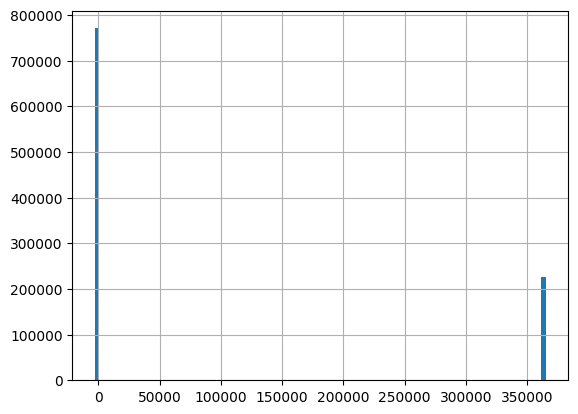

In [165]:
previous_app['DAYS_TERMINATION'].hist(bins=100)

In [166]:
# Crédits en cours :
previous_app.loc[previous_app['DAYS_TERMINATION']>300000, 'DAYS_TERMINATION'].value_counts()

DAYS_TERMINATION
365243.0    225745
Name: count, dtype: int64

In [167]:
# Crédits clos :
previous_app.loc[previous_app['DAYS_TERMINATION'] != 365243.0, 'DAYS_TERMINATION'].count()

770695

In [168]:
# Crédits en cours mais non activé :
previous_app.loc[previous_app['DAYS_TERMINATION'].isna(), 'DAYS_TERMINATION'].value_counts(dropna=False)

DAYS_TERMINATION
NaN    39604
Name: count, dtype: int64

In [169]:
# je retrouve bien tou les crédits 
39604+770695+225745

1036044

## Crédits sans données de paiement

In [170]:
# Même si tous les types de contrat sont représentés dans INSTALLMENT, tous les crédits ne sont pas représenté dans INSTALLMENT : il reste des NaN 
previous_app_agg['CNT_INSTALLMENT'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1036044 entries, 0 to 1036043
Series name: CNT_INSTALLMENT
Non-Null Count   Dtype  
--------------   -----  
958234 non-null  float64
dtypes: float64(1)
memory usage: 7.9 MB


In [171]:
# 7.5 % des crédits non pas d'installment
1036044-958234

77810

In [172]:
# Ils se décomposent en :
#   encours non activé (NaN)
#   en cours (365243.0)
previous_app_agg.loc[previous_app_agg['CNT_INSTALLMENT'].isna(), 'DAYS_TERMINATION'].value_counts(dropna=False)

DAYS_TERMINATION
 NaN         39211
 365243.0    34071
-39.0           30
-42.0           29
-84.0           26
             ...  
-362.0           1
-408.0           1
-663.0           1
-775.0           1
-557.0           1
Name: count, Length: 506, dtype: int64

In [173]:
# Le reste étant les clos
previous_app_agg.loc[(previous_app_agg['CNT_INSTALLMENT'].isna()) & (previous_app_agg['DAYS_TERMINATION'] < 0), 'DAYS_TERMINATION'].count()

4528

In [174]:
# Ma décomposition est correcte
39211+34071+4528

77810

In [175]:
# Le reste étant les clos : ce ne sont que des révolving non utilisés
previous_app_agg.loc[(previous_app_agg['CNT_INSTALLMENT'].isna()) & (previous_app_agg['DAYS_TERMINATION'] < 0), 'NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Revolving loans    4528
Name: count, dtype: int64

In [176]:
# Les encours sont essentiellement des revolving
previous_app_agg.loc[(previous_app_agg['CNT_INSTALLMENT'].isna()) & (previous_app_agg['DAYS_TERMINATION'] > 0), 'NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Revolving loans    26734
Consumer loans      6888
Cash loans           449
Name: count, dtype: int64

In [177]:
# Les encours sont essentiellement des revolving
previous_app_agg.loc[(previous_app_agg['CNT_INSTALLMENT'].isna()) & (previous_app_agg['DAYS_TERMINATION'].isna()), 'NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         23667
Consumer loans     11557
Revolving loans     3987
Name: count, dtype: int64

## Montant crédit Nan et valeurs à zéro

In [178]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1036044 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036043 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-null   

In [179]:
# Impute 1 NaN à Zero
previous_app['AMT_CREDIT'] = previous_app['AMT_CREDIT'].fillna(0)

In [180]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1036044 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-null   

<Axes: >

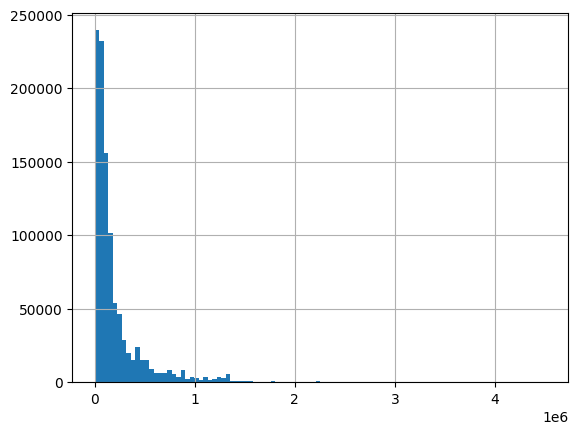

In [181]:
previous_app['AMT_CREDIT'].hist(bins=100)

In [182]:
previous_app['AMT_CREDIT'].describe()

count    1.036044e+06
mean     2.024648e+05
std      2.751960e+05
min      0.000000e+00
25%      4.797000e+04
50%      1.021455e+05
75%      2.250000e+05
max      4.509688e+06
Name: AMT_CREDIT, dtype: float64

In [183]:
previous_app.loc[previous_app['AMT_CREDIT'] == 0.0, 'NAME_CONTRACT_TYPE'].value_counts(dropna=False)

NAME_CONTRACT_TYPE
Revolving loans    1552
Name: count, dtype: int64

In [184]:
list_app = previous_app.loc[previous_app['AMT_CREDIT'] == 0.0, 'SK_ID_PREV'].to_list()
len(list_app)

1552

In [185]:
import random
id_test = random.choice(list_app)
sel_credit_card = ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
credit_card.loc[credit_card['SK_ID_PREV'] == id_test, sel_credit_card].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


In [186]:
installment.loc[installment['SK_ID_PREV'] == id_test].sort_values('NUM_INSTALMENT_NUMBER')

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT


In [187]:
previous_app.loc[previous_app['SK_ID_PREV'] == id_test, :].stack()

145600  SK_ID_PREV                                  1753078
        SK_ID_CURR                                   264742
        NAME_CONTRACT_TYPE                  Revolving loans
        AMT_ANNUITY                                     0.0
        AMT_APPLICATION                                 0.0
        AMT_CREDIT                                      0.0
        AMT_GOODS_PRICE                                 0.0
        WEEKDAY_APPR_PROCESS_START                   FRIDAY
        HOUR_APPR_PROCESS_START                          10
        FLAG_LAST_APPL_PER_CONTRACT                       Y
        NFLAG_LAST_APPL_IN_DAY                            1
        NAME_CASH_LOAN_PURPOSE                          XAP
        NAME_CONTRACT_STATUS                       Approved
        DAYS_DECISION                                   -37
        NAME_PAYMENT_TYPE                               XNA
        CODE_REJECT_REASON                              XAP
        NAME_TYPE_SUITE                 

In [188]:
id_test_curr = previous_app.loc[previous_app['SK_ID_PREV'] == id_test, 'SK_ID_CURR'].to_list()[0]
df.loc[df['SK_ID_CURR'] == id_test_curr, ['SK_ID_CURR', 'AMT_CREDIT', 'AMT_ANNUITY']].stack()

330167  SK_ID_CURR     264742.0
        AMT_CREDIT     450000.0
        AMT_ANNUITY     36081.0
dtype: float64

Je ne touche pas au montant nul, car je n'arrive pas à trouver de valeur pour imputer

## Calcul aggrégas par crédit (à sauter)

### Dernier Status contract

In [189]:
pos_cash.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9653391 entries, 0 to 9791160
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             float64
 2   MONTHS_BALANCE         float64
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 float64
 7   SK_DPD_DEF             float64
dtypes: float64(6), int64(1), object(1)
memory usage: 662.8+ MB


In [190]:
mask = pos_cash.groupby('SK_ID_PREV')['MONTHS_BALANCE'].idxmax()  # Récupère les index de la dernière ligne de chaque groupe
pos_cash_status = pos_cash.loc[mask, ['SK_ID_PREV', 'NAME_CONTRACT_STATUS']]  # récupère les status
pos_cash_status.columns = ['SK_ID_PREV', 'NAME_CONTRACT_STATUS_FINAL']
pos_cash_status

,SK_ID_PREV,NAME_CONTRACT_STATUS_FINAL
235786,1000001,Completed
448612,1000002,Completed
8910331,1000003,Active
8267612,1000004,Completed
3081794,1000005,Completed
...,...,...
2497221,2843492,Completed
6155261,2843494,Completed
6187282,2843495,Completed
8998211,2843498,Completed


In [191]:
# Je remonte la donnée dans previous_app
previous_app = pd.merge(previous_app, pos_cash_status,
                        on='SK_ID_PREV', how='left',
                        validate='many_to_one')

In [192]:
previous_app['NAME_CONTRACT_STATUS_FINAL'].value_counts(dropna=False)

NAME_CONTRACT_STATUS_FINAL
Completed                663035
Active                   233570
NaN                      137770
Signed                     1271
Returned to the store       300
Approved                     58
Demand                       35
Amortized debt                3
Canceled                      2
Name: count, dtype: int64

In [193]:
credit_card.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2755820 entries, 12 to 3698995
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  float64
 2   MONTHS_BALANCE              float64
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     float64
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        float64
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE_CUM

In [194]:
credit_card['NAME_CONTRACT_STATUS'].value_counts()

NAME_CONTRACT_STATUS
Active           2667301
Completed          77688
Signed             10297
Sent proposal        510
Refused               17
Approved               5
Demand                 2
Name: count, dtype: int64

In [195]:
mask = credit_card.groupby('SK_ID_PREV')['MONTHS_BALANCE'].idxmax()  # Récupère les index de la dernière ligne de chaque groupe
credit_card_status = credit_card.loc[mask, ['SK_ID_PREV', 'NAME_CONTRACT_STATUS']]  # récupère les status
credit_card_status.columns = ['SK_ID_PREV', 'NAME_CONTRACT_STATUS_FINAL']
credit_card_status

,SK_ID_PREV,NAME_CONTRACT_STATUS_FINAL
3360982,1000018,Active
3140971,1000030,Active
260959,1000031,Active
509445,1000035,Active
2666707,1000077,Active
...,...,...
1459610,2843461,Active
2323352,2843477,Active
818817,2843478,Active
656296,2843493,Active


In [196]:
# Je remonte la donnée dans previous_app
previous_app = pd.merge(previous_app, credit_card_status,
                        on='SK_ID_PREV', how='left',
                        validate='many_to_one')

In [197]:
previous_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 39 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   SK_ID_PREV                    1036044 non-null  int64  
 1   SK_ID_CURR                    1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE            1036044 non-null  object 
 3   AMT_ANNUITY                   1036040 non-null  float64
 4   AMT_APPLICATION               1036044 non-null  float64
 5   AMT_CREDIT                    1036044 non-null  float64
 6   AMT_DOWN_PAYMENT              662114 non-null   float64
 7   AMT_GOODS_PRICE               993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START    1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START       1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT   1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY        1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT           

In [198]:
# je complète les valeurs NaN par le 2eme merge
previous_app['NAME_CONTRACT_STATUS_FINAL'] = previous_app['NAME_CONTRACT_STATUS_FINAL_x'].fillna(previous_app['NAME_CONTRACT_STATUS_FINAL_y'])
# Je supprime les 2 colonnes intermédiaires
previous_app = previous_app.drop(columns=['NAME_CONTRACT_STATUS_FINAL_x', 'NAME_CONTRACT_STATUS_FINAL_y'])
previous_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 38 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [199]:
previous_app['NAME_CONTRACT_STATUS_FINAL'].value_counts(dropna=False)

NAME_CONTRACT_STATUS_FINAL
Completed                673968
Active                   315451
NaN                       44916
Signed                     1309
Returned to the store       300
Approved                     58
Demand                       37
Amortized debt                3
Canceled                      2
Name: count, dtype: int64

In [200]:
# Je crée un status final 'Unknown' pour les crédits n'ayant pas d'enregistrement dans les balances
previous_app['NAME_CONTRACT_STATUS_FINAL'] = previous_app['NAME_CONTRACT_STATUS_FINAL'].fillna('Unknown')

In [201]:
previous_app['NAME_CONTRACT_STATUS_FINAL'].value_counts(dropna=False)

NAME_CONTRACT_STATUS_FINAL
Completed                673968
Active                   315451
Unknown                   44916
Signed                     1309
Returned to the store       300
Approved                     58
Demand                       37
Amortized debt                3
Canceled                      2
Name: count, dtype: int64

In [202]:
# je vérifie si DAYS_TERMINATION > 0 correspond au clos : c'est faux !
previous_app.loc[previous_app['DAYS_TERMINATION'] > 0, 'NAME_CONTRACT_STATUS_FINAL'].value_counts(dropna=False)

NAME_CONTRACT_STATUS_FINAL
Active                   218979
Unknown                    5494
Signed                      892
Returned to the store       294
Approved                     39
Demand                       32
Completed                    10
Amortized debt                3
Canceled                      2
Name: count, dtype: int64

### Montant MAX en défaut de paiement

In [203]:
installment.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 12345851 entries, 0 to 12423660
Data columns (total 8 columns):
 #   Column                  Non-Null Count     Dtype  
---  ------                  --------------     -----  
 0   SK_ID_PREV              12345851 non-null  int64  
 1   SK_ID_CURR              12345851 non-null  float64
 2   NUM_INSTALMENT_VERSION  12345851 non-null  float64
 3   NUM_INSTALMENT_NUMBER   12345851 non-null  float64
 4   DAYS_INSTALMENT         12345851 non-null  float64
 5   DAYS_ENTRY_PAYMENT      12343387 non-null  float64
 6   AMT_INSTALMENT          12345851 non-null  float64
 7   AMT_PAYMENT             12343387 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 847.7 MB


Overdue sur le mois si :
* pas de paiement sur le mois
* ou paiement en retard

In [204]:
installment_agg0 = installment.groupby('SK_ID_PREV')[['SK_ID_PREV', 'DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT', 'AMT_INSTALMENT']] \
.apply(lambda sub: sub.loc[sub['DAYS_ENTRY_PAYMENT'].isna(), 'AMT_INSTALMENT'].max())

In [205]:
installment_agg0.shape

(958234,)

In [206]:
installment_agg0

SK_ID_PREV
1000001   NaN
1000002   NaN
1000003   NaN
1000004   NaN
1000005   NaN
           ..
2843494   NaN
2843495   NaN
2843496   NaN
2843498   NaN
2843499   NaN
Length: 958234, dtype: float64

In [207]:
installment_agg1 = installment.groupby('SK_ID_PREV')[['SK_ID_PREV', 'DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT', 'AMT_INSTALMENT']] \
.apply(lambda sub: sub.loc[(sub['DAYS_ENTRY_PAYMENT'] - sub['DAYS_INSTALMENT']) > 0, 'AMT_INSTALMENT'].max())

In [208]:
installment_agg = pd.DataFrame({'SK_ID_PREV' : installment_agg0.index.to_list(),
                                'AMT_PREV_MAX_OVERDUE0' : installment_agg0.to_list(), 
                                'AMT_PREV_MAX_OVERDUE2' : installment_agg1.to_list()})
installment_agg.head()

,SK_ID_PREV,AMT_PREV_MAX_OVERDUE0,AMT_PREV_MAX_OVERDUE2
0,1000001,NaN,NaN
1,1000002,NaN,NaN
2,1000003,NaN,NaN
3,1000004,NaN,NaN
4,1000005,NaN,14713.605


In [209]:
installment_agg = installment_agg.fillna(0)
installment_agg

,SK_ID_PREV,AMT_PREV_MAX_OVERDUE0,AMT_PREV_MAX_OVERDUE2
0,1000001,0.0,0.000
1,1000002,0.0,0.000
2,1000003,0.0,0.000
3,1000004,0.0,0.000
4,1000005,0.0,14713.605
...,...,...,...
958229,2843494,0.0,0.000
958230,2843495,0.0,23556.195
958231,2843496,0.0,0.000
958232,2843498,0.0,0.000


In [210]:
installment_agg['AMT_PREV_MAX_OVERDUE'] = installment_agg[['AMT_PREV_MAX_OVERDUE0', 'AMT_PREV_MAX_OVERDUE2']].max(axis=1)
installment_agg

,SK_ID_PREV,AMT_PREV_MAX_OVERDUE0,AMT_PREV_MAX_OVERDUE2,AMT_PREV_MAX_OVERDUE
0,1000001,0.0,0.000,0.000
1,1000002,0.0,0.000,0.000
2,1000003,0.0,0.000,0.000
3,1000004,0.0,0.000,0.000
4,1000005,0.0,14713.605,14713.605
...,...,...,...,...
958229,2843494,0.0,0.000,0.000
958230,2843495,0.0,23556.195,23556.195
958231,2843496,0.0,0.000,0.000
958232,2843498,0.0,0.000,0.000


In [211]:
installment_agg.loc[installment_agg['AMT_PREV_MAX_OVERDUE0'] > 0]

,SK_ID_PREV,AMT_PREV_MAX_OVERDUE0,AMT_PREV_MAX_OVERDUE2,AMT_PREV_MAX_OVERDUE
1467,1001758,96.435,1890.000,1890.000
2892,1003474,130.500,2153.970,2153.970
3474,1004174,1350.000,3450.735,3450.735
4466,1005373,67.500,0.000,67.500
5841,1007055,130.500,3375.000,3375.000
...,...,...,...,...
954535,2835350,16367.985,0.000,16367.985
955739,2837223,116.550,23854.050,23854.050
956863,2841786,67.500,0.000,67.500
957556,2842600,20538.765,0.000,20538.765


In [212]:
# Vérification par échantillonage
id_test = installment.loc[installment['DAYS_ENTRY_PAYMENT'].isna(), 'SK_ID_PREV'].sample(1).to_list()[0]
installment.loc[installment['SK_ID_PREV'] == id_test].sort_values('DAYS_INSTALMENT')

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
8256020,2676077,356907.0,1.0,1.0,-521.0,-537.0,28019.115,28019.115
8256012,2676077,356907.0,1.0,2.0,-491.0,-505.0,28019.115,28019.115
8256007,2676077,356907.0,1.0,3.0,-461.0,-477.0,28019.115,28019.115
8256015,2676077,356907.0,1.0,4.0,-431.0,-441.0,28019.115,28019.115
8256019,2676077,356907.0,1.0,5.0,-401.0,-410.0,28019.115,28019.115
8256021,2676077,356907.0,1.0,6.0,-371.0,-379.0,28019.115,28019.115
8256010,2676077,356907.0,1.0,7.0,-341.0,-349.0,28019.115,28019.115
8256016,2676077,356907.0,1.0,8.0,-311.0,-316.0,28019.115,28019.115
8256013,2676077,356907.0,1.0,9.0,-281.0,-287.0,28019.115,28019.115
8256011,2676077,356907.0,1.0,10.0,-251.0,-287.0,28019.115,28019.115


In [213]:
installment_agg.loc[installment_agg['SK_ID_PREV'] == id_test]

,SK_ID_PREV,AMT_PREV_MAX_OVERDUE0,AMT_PREV_MAX_OVERDUE2,AMT_PREV_MAX_OVERDUE
875079,2676077,28019.115,28019.115,28019.115


In [214]:
# Je remonte la donnée dans previous_app
previous_app = pd.merge(previous_app, installment_agg[['SK_ID_PREV', 'AMT_PREV_MAX_OVERDUE']],
                        on='SK_ID_PREV', how='left',
                        validate='many_to_one')

In [215]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 39 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [216]:
# J'impute à zéro pour les crédits n'ayant pas de données dans installment 
previous_app['AMT_PREV_MAX_OVERDUE'] = previous_app['AMT_PREV_MAX_OVERDUE'].fillna(0)

In [217]:
previous_app['AMT_PREV_MAX_OVERDUE'].describe()

count    1.036044e+06
mean     4.389280e+03
std      1.423895e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.175145e+03
max      2.425427e+06
Name: AMT_PREV_MAX_OVERDUE, dtype: float64

### Current credit overdue

In [218]:
installment.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 12345851 entries, 0 to 12423660
Data columns (total 8 columns):
 #   Column                  Non-Null Count     Dtype  
---  ------                  --------------     -----  
 0   SK_ID_PREV              12345851 non-null  int64  
 1   SK_ID_CURR              12345851 non-null  float64
 2   NUM_INSTALMENT_VERSION  12345851 non-null  float64
 3   NUM_INSTALMENT_NUMBER   12345851 non-null  float64
 4   DAYS_INSTALMENT         12345851 non-null  float64
 5   DAYS_ENTRY_PAYMENT      12343387 non-null  float64
 6   AMT_INSTALMENT          12345851 non-null  float64
 7   AMT_PAYMENT             12343387 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 847.7 MB


In [219]:
installment_agg = installment[['SK_ID_PREV', 'AMT_INSTALMENT', 'AMT_PAYMENT']].groupby('SK_ID_PREV').sum()
installment_agg

,AMT_INSTALMENT,AMT_PAYMENT
SK_ID_PREV,,
1000001,68443.425,68443.425
1000002,37235.565,37235.565
1000003,14854.050,14854.050
1000004,33523.155,33523.155
1000005,161735.310,147021.705
...,...,...
2843494,982794.465,982794.465
2843495,797530.185,797530.185
2843496,312334.605,304333.155


In [220]:
installment_agg.rename(columns={'AMT_INSTALMENT': 'AMT_PREV_SUM_INSTALLMENT',
                                 'AMT_PAYMENT': 'AMT_PREV_SUM_PAYMENT'}, inplace=True)
installment_agg

,AMT_PREV_SUM_INSTALLMENT,AMT_PREV_SUM_PAYMENT
SK_ID_PREV,,
1000001,68443.425,68443.425
1000002,37235.565,37235.565
1000003,14854.050,14854.050
1000004,33523.155,33523.155
1000005,161735.310,147021.705
...,...,...
2843494,982794.465,982794.465
2843495,797530.185,797530.185
2843496,312334.605,304333.155


In [221]:
installment_agg['AMT_PREV_SUM_OVERDUE'] = installment_agg['AMT_PREV_SUM_INSTALLMENT'] - installment_agg['AMT_PREV_SUM_PAYMENT']
installment_agg.reset_index(inplace=True)
installment_agg

,SK_ID_PREV,AMT_PREV_SUM_INSTALLMENT,AMT_PREV_SUM_PAYMENT,AMT_PREV_SUM_OVERDUE
0,1000001,68443.425,68443.425,0.000
1,1000002,37235.565,37235.565,0.000
2,1000003,14854.050,14854.050,0.000
3,1000004,33523.155,33523.155,0.000
4,1000005,161735.310,147021.705,14713.605
...,...,...,...,...
958229,2843494,982794.465,982794.465,0.000
958230,2843495,797530.185,797530.185,0.000
958231,2843496,312334.605,304333.155,8001.450
958232,2843498,414321.435,414321.435,0.000


<Axes: >

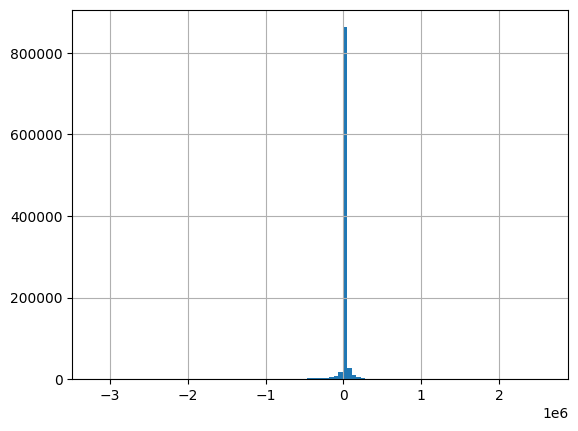

In [222]:
installment_agg['AMT_PREV_SUM_OVERDUE'].hist(bins=100)

In [223]:
pd.cut(installment_agg['AMT_PREV_SUM_OVERDUE'], bins=[-1E7, -0.001, 0.001, 1E7], include_lowest=True).value_counts()

AMT_PREV_SUM_OVERDUE
(-0.001, 0.001]            700461
(0.001, 10000000.0]        207875
(-10000000.001, -0.001]     49898
Name: count, dtype: int64

In [224]:
# 5.5% crédit avec Remaining balance négative ?
list_id = installment_agg.loc[installment_agg['AMT_PREV_SUM_OVERDUE'] < 0, 'SK_ID_PREV'].to_list()

In [225]:
previous_app.loc[previous_app['SK_ID_PREV'] == id_test].stack()

690155  SK_ID_PREV                                 2676077
        SK_ID_CURR                                  356907
        NAME_CONTRACT_TYPE                      Cash loans
        AMT_ANNUITY                              28019.115
        AMT_APPLICATION                           675000.0
        AMT_CREDIT                                790830.0
        AMT_GOODS_PRICE                           675000.0
        WEEKDAY_APPR_PROCESS_START               WEDNESDAY
        HOUR_APPR_PROCESS_START                         14
        FLAG_LAST_APPL_PER_CONTRACT                      Y
        NFLAG_LAST_APPL_IN_DAY                           1
        NAME_CASH_LOAN_PURPOSE                         XNA
        NAME_CONTRACT_STATUS                      Approved
        DAYS_DECISION                                 -552
        NAME_PAYMENT_TYPE                              XNA
        CODE_REJECT_REASON                             XAP
        NAME_CLIENT_TYPE                          Repeat

In [226]:
# Je regarde par échantillonage
id_test = random.choice(list_id)
installment_agg.loc[installment_agg['SK_ID_PREV'] == id_test]

,SK_ID_PREV,AMT_PREV_SUM_INSTALLMENT,AMT_PREV_SUM_PAYMENT,AMT_PREV_SUM_OVERDUE
412031,1764837,156647.79,260202.33,-103554.54


In [227]:
installment.loc[installment['SK_ID_PREV'] == id_test].sort_values('DAYS_INSTALMENT')

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
1047790,1764837,151837.0,1.0,1.0,-272.0,-280.0,26407.215,45054.540
1047791,1764837,151837.0,2.0,1.0,-272.0,-280.0,18647.325,45054.540
1047787,1764837,151837.0,4.0,2.0,-242.0,-249.0,4513.410,27000.000
1047788,1764837,151837.0,3.0,2.0,-242.0,-249.0,22486.590,27000.000
1047785,1764837,151837.0,5.0,3.0,-212.0,-218.0,21310.245,31500.000
1047786,1764837,151837.0,6.0,3.0,-212.0,-218.0,10189.755,31500.000
1047789,1764837,151837.0,7.0,4.0,-182.0,-185.0,17797.635,17797.635
1047792,1764837,151837.0,8.0,5.0,-152.0,-156.0,35295.615,35295.615


In [228]:
credit_card.loc[credit_card['SK_ID_PREV'] == id_test].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


In [229]:
pos_cash.loc[pos_cash['SK_ID_PREV'] == id_test].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
847270,1764837,151837.0,-10.0,6.0,6.0,Active,0.0,0.0
847268,1764837,151837.0,-9.0,6.0,5.0,Active,0.0,0.0
847265,1764837,151837.0,-8.0,6.0,4.0,Active,0.0,0.0
847269,1764837,151837.0,-7.0,6.0,3.0,Active,0.0,0.0
847266,1764837,151837.0,-6.0,6.0,2.0,Active,0.0,0.0
847267,1764837,151837.0,-5.0,5.0,0.0,Completed,0.0,0.0


In [230]:
# Je remonte la donnée dans previous_app
previous_app = pd.merge(previous_app, installment_agg,
                        on='SK_ID_PREV', how='left',
                        validate='many_to_one')

In [231]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [232]:
# J'impute à zéro pour les crédits n'ayant pas de données dans installment 
previous_app['AMT_PREV_SUM_INSTALLMENT'] = previous_app['AMT_PREV_SUM_INSTALLMENT'].fillna(0)
previous_app['AMT_PREV_SUM_PAYMENT'] = previous_app['AMT_PREV_SUM_PAYMENT'].fillna(0)
previous_app['AMT_PREV_SUM_OVERDUE'] = previous_app['AMT_PREV_SUM_OVERDUE'].fillna(0)
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

### Montant encours de crédit pour les non Revolving

In [233]:
previous_app['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Consumer loans     626203
Cash loans         312154
Revolving loans     97687
Name: count, dtype: int64

In [234]:
626203+312154+97687

1036044

In [235]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036040 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [236]:
# J'impute les 4 ANNUITY à zéro
previous_app['AMT_ANNUITY'] = previous_app['AMT_ANNUITY'].fillna(0)

In [237]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [238]:
# pour les crédits classiques (hors revolving)
mask = previous_app['NAME_CONTRACT_TYPE'] == 'Revolving loans'
previous_app.loc[~mask, 'AMT_PREV_SUM_DEBT'] = previous_app.loc[~mask, 'AMT_CREDIT'] + previous_app.loc[~mask, 'AMT_ANNUITY'] - previous_app.loc[~mask, 'AMT_PREV_SUM_INSTALLMENT']

In [239]:
previous_app.loc[~mask, ['AMT_PREV_SUM_DEBT', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_PREV_SUM_INSTALLMENT']]

,AMT_PREV_SUM_DEBT,AMT_CREDIT,AMT_ANNUITY,AMT_PREV_SUM_INSTALLMENT
0,1591.155,17145.0,1730.430,17284.275
1,578916.540,679671.0,25188.615,125943.075
2,15958.620,136444.5,15060.735,135546.615
3,-45302.040,470790.0,47041.335,563133.375
4,-55055.475,340573.5,23703.930,419332.905
...,...,...,...,...
1036039,-27659.295,311400.0,14704.290,353763.585
1036040,-8358.345,64291.5,6622.020,79271.865
1036041,-1144.215,102523.5,11520.855,115188.570
1036042,-15133.140,191880.0,18821.520,225834.660


In [240]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 43 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [241]:
# Je vérifie que tous les non revolviong ont bien un AMT_PREV_SUM_DEBT
previous_app.loc[~mask, 'SK_ID_PREV'].count()

938357

Je vérifie les valeurs

In [242]:
mask = (previous_app['NAME_CONTRACT_TYPE'] != 'Revolving loans') \
& (previous_app['NAME_CONTRACT_STATUS_FINAL'] == 'Active')
previous_app_sel = previous_app.loc[mask]

<Axes: >

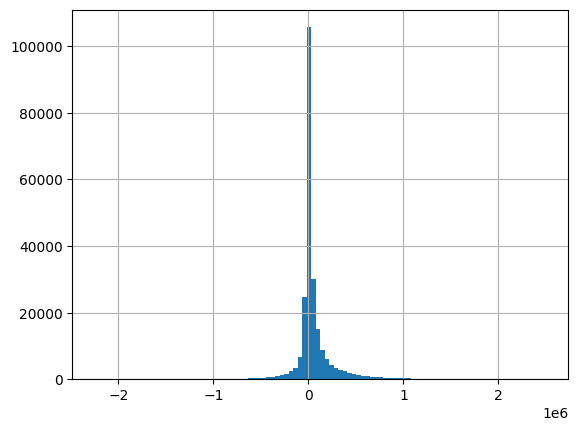

In [243]:
(previous_app_sel['AMT_PREV_SUM_DEBT']).hist(bins=100)

In [244]:
pd.cut(previous_app_sel['AMT_PREV_SUM_DEBT'], bins=[-1E7, -0.1, 0.1, 1E7], include_lowest=True).value_counts()

AMT_PREV_SUM_DEBT
(0.1, 10000000.0]        132103
(-10000000.001, -0.1]    101465
(-0.1, 0.1]                   2
Name: count, dtype: int64

In [245]:
list_id = previous_app.loc[mask & \
(previous_app_sel['AMT_PREV_SUM_DEBT'] > 0),
'SK_ID_PREV'].to_list()

In [246]:
id_test = random.choice(list_id)
previous_app.loc[previous_app['SK_ID_PREV'] == id_test].stack()

54414  SK_ID_PREV                                         1369648
       SK_ID_CURR                                          242596
       NAME_CONTRACT_TYPE                          Consumer loans
       AMT_ANNUITY                                       5620.095
       AMT_APPLICATION                                    79650.0
       AMT_CREDIT                                         79650.0
       AMT_DOWN_PAYMENT                                       0.0
       AMT_GOODS_PRICE                                    79650.0
       WEEKDAY_APPR_PROCESS_START                        THURSDAY
       HOUR_APPR_PROCESS_START                                 16
       FLAG_LAST_APPL_PER_CONTRACT                              Y
       NFLAG_LAST_APPL_IN_DAY                                   1
       RATE_DOWN_PAYMENT                                      0.0
       NAME_CASH_LOAN_PURPOSE                                 XAP
       NAME_CONTRACT_STATUS                              Approved
       DAY

In [247]:
installment.loc[installment['SK_ID_PREV'] == id_test, ['AMT_INSTALMENT', 'AMT_PAYMENT']].sum()

AMT_INSTALMENT    61821.045
AMT_PAYMENT       61821.045
dtype: float64

In [248]:
installment.loc[installment['SK_ID_PREV'] == id_test].sort_values('DAYS_INSTALMENT')

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
637727,1369648,242596.0,1.0,1.0,-356.0,-376.0,5620.095,5620.095
637733,1369648,242596.0,1.0,2.0,-326.0,-338.0,5620.095,5620.095
637729,1369648,242596.0,1.0,3.0,-296.0,-324.0,5620.095,5620.095
637726,1369648,242596.0,1.0,4.0,-266.0,-288.0,5620.095,5620.095
637725,1369648,242596.0,1.0,5.0,-236.0,-261.0,5620.095,5620.095
637724,1369648,242596.0,1.0,6.0,-206.0,-227.0,5620.095,5620.095
637731,1369648,242596.0,1.0,7.0,-176.0,-197.0,5620.095,5620.095
637728,1369648,242596.0,1.0,8.0,-146.0,-172.0,5620.095,5620.095
637732,1369648,242596.0,1.0,9.0,-116.0,-140.0,5620.095,5620.095
637734,1369648,242596.0,1.0,10.0,-86.0,-111.0,5620.095,5620.095


In [249]:
pos_cash.loc[pos_cash['SK_ID_PREV'] == id_test].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
518568,1369648,242596.0,-13.0,18.0,18.0,Active,0.0,0.0
518563,1369648,242596.0,-12.0,18.0,17.0,Active,0.0,0.0
518557,1369648,242596.0,-11.0,18.0,16.0,Active,0.0,0.0
518562,1369648,242596.0,-10.0,18.0,15.0,Active,0.0,0.0
518558,1369648,242596.0,-9.0,18.0,14.0,Active,0.0,0.0
518564,1369648,242596.0,-8.0,18.0,13.0,Active,0.0,0.0
518565,1369648,242596.0,-7.0,18.0,12.0,Active,0.0,0.0
518566,1369648,242596.0,-6.0,18.0,11.0,Active,0.0,0.0
518560,1369648,242596.0,-5.0,18.0,10.0,Active,0.0,0.0
518561,1369648,242596.0,-4.0,18.0,9.0,Active,0.0,0.0


In [250]:
credit_card.loc[credit_card['SK_ID_PREV'] == id_test].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


### Montant encours crédit pour les Revolving

In [251]:
# Je prends le montant engagé du mois le plus récent
mask = credit_card.groupby('SK_ID_PREV')['MONTHS_BALANCE'].idxmax()  # Récupère les index de la dernière ligne de chaque groupe
credit_card_debt = credit_card.loc[mask, ['SK_ID_PREV', 'AMT_TOTAL_RECEIVABLE']]  # récupère le dernier engagement
credit_card_debt

,SK_ID_PREV,AMT_TOTAL_RECEIVABLE
3360982,1000018,136024.920
3140971,1000030,103027.275
260959,1000031,135786.690
509445,1000035,0.000
2666707,1000077,0.000
...,...,...
1459610,2843461,44589.735
2323352,2843477,0.000
818817,2843478,0.000
656296,2843493,69261.345


In [252]:
credit_card.loc[credit_card['SK_ID_PREV'] == 1000018].sort_values('MONTHS_BALANCE')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
3360981,1000018,394447.0,-6.0,38879.145,45000.0,13500.0,51042.645,0.0,37542.645,0.00,...,37542.645,37542.645,3.0,15.0,0.0,12.0,0.0,Active,0.0,0.0
3360980,1000018,394447.0,-5.0,40934.070,45000.0,0.0,2335.500,0.0,2335.500,2250.00,...,40934.070,40934.070,0.0,2.0,0.0,2.0,1.0,Active,0.0,0.0
3360984,1000018,394447.0,-4.0,44360.505,45000.0,0.0,2032.560,0.0,2032.560,2250.00,...,44360.505,44360.505,0.0,2.0,0.0,2.0,2.0,Active,0.0,0.0
3360983,1000018,394447.0,-3.0,113862.285,135000.0,13500.0,69156.945,0.0,55656.945,2263.77,...,109150.785,109150.785,3.0,14.0,0.0,11.0,3.0,Active,0.0,0.0
3360982,1000018,394447.0,-2.0,136695.420,135000.0,0.0,22827.330,0.0,22827.330,6206.67,...,136024.920,136024.920,0.0,11.0,0.0,11.0,4.0,Active,0.0,0.0


In [253]:
previous_app.loc[previous_app['SK_ID_PREV'] == 1000018].stack()

943821  SK_ID_PREV                                  1000018
        SK_ID_CURR                                   394447
        NAME_CONTRACT_TYPE                  Revolving loans
        AMT_ANNUITY                                  2250.0
        AMT_APPLICATION                             45000.0
        AMT_CREDIT                                  45000.0
        AMT_GOODS_PRICE                             45000.0
        WEEKDAY_APPR_PROCESS_START                   SUNDAY
        HOUR_APPR_PROCESS_START                          10
        FLAG_LAST_APPL_PER_CONTRACT                       Y
        NFLAG_LAST_APPL_IN_DAY                            1
        NAME_CASH_LOAN_PURPOSE                          XAP
        NAME_CONTRACT_STATUS                       Approved
        DAYS_DECISION                                  -176
        NAME_PAYMENT_TYPE                               XNA
        CODE_REJECT_REASON                              XAP
        NAME_TYPE_SUITE                 

In [254]:
# Je remonte la donnée dans previous_app
previous_app = pd.merge(previous_app, credit_card_debt,
                        on='SK_ID_PREV', how='left',
                        validate='many_to_one')

In [255]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 44 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [256]:
# Il manque environ 5000 revolving dans credit_card (par rapport à previous_app)
938357+92854

1031211

In [257]:

mask = previous_app['NAME_CONTRACT_TYPE'] == 'Revolving loans'
# pour les crédits classiques (hors revolving)
list_id = previous_app.loc[~mask, 'SK_ID_PREV'].to_list()
print('Pour les crédits non revolving :')
print('Nb dans previous_app : ', len(list_id))
print('Nb dans pos_cash : ', pos_cash.loc[pos_cash['SK_ID_PREV'].isin(list_id), 'SK_ID_PREV'].nunique())
# Pour les révolving
list_id = previous_app.loc[mask, 'SK_ID_PREV'].to_list()
print('Pour les crédits revolving :')
print('Nb dans previous_app : ', len(list_id))
print('Nb dans pos_cash : ', credit_card.loc[credit_card['SK_ID_PREV'].isin(list_id), 'SK_ID_PREV'].nunique())


Pour les crédits non revolving :
Nb dans previous_app :  938357
Nb dans pos_cash :  898274
Pour les crédits revolving :
Nb dans previous_app :  97687
Nb dans pos_cash :  92854


In [258]:
# J'impute les valeurs NaN (qui sont les crédits non revolving) avec le DEBT déjà calculé :
previous_app['AMT_TOTAL_RECEIVABLE'] = previous_app['AMT_TOTAL_RECEIVABLE'].fillna(previous_app['AMT_PREV_SUM_DEBT'])

In [259]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 44 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [260]:
# Il reste environ 5000 crédits sans AMT_TOTAL_RECEIVABLE qui n'ont pas d'info dans la balance
# J'impute avec Montant_credit + Annuity - somme installment
previous_app['AMT_TOTAL_RECEIVABLE'] = previous_app['AMT_TOTAL_RECEIVABLE'].fillna( \
    previous_app['AMT_CREDIT'] + previous_app['AMT_ANNUITY'] - previous_app['AMT_PREV_SUM_INSTALLMENT'])

In [261]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 44 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [262]:
# je ne garde que la dernière colonne
previous_app.pop('AMT_PREV_SUM_DEBT')

0            1591.155
1          578916.540
2           15958.620
3          -45302.040
4          -55055.475
              ...    
1036039    -27659.295
1036040     -8358.345
1036041     -1144.215
1036042    -15133.140
1036043   -295533.000
Name: AMT_PREV_SUM_DEBT, Length: 1036044, dtype: float64

In [263]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 43 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [264]:
previous_app = previous_app.rename(columns={'AMT_TOTAL_RECEIVABLE' : 'AMT_PREV_SUM_DEBT'})

In [265]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 43 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

### Montant crédit

In [266]:
# Facile pour les crédits classiques (hors revolving) : egale à AMT_CREDIT
# Pour les revolving, il faudra mettre à jour cette donnée si présent dans la balance
# Pour tous les crédits, j'initialise à AMT_CREDIT
previous_app['AMT_PREV_CREDIT'] = previous_app['AMT_CREDIT']

In [268]:
# Pour les crédits révolving, préférer AMT_CREDIT_LIMIT_ACTUAL par rapport à AMT_CREDIT, qui semble être actualisée chaque mois 
# contrairement à AMT_CREDIT qui semble fixe
# Je prends la limite d'engagement du mois le plus récent
mask = credit_card.groupby('SK_ID_PREV')['MONTHS_BALANCE'].idxmax()  # Récupère les index de la dernière ligne de chaque groupe
credit_card_debt = credit_card.loc[mask, ['SK_ID_PREV', 'AMT_CREDIT_LIMIT_ACTUAL']]  # récupère le dernier engagement
credit_card_debt

,SK_ID_PREV,AMT_CREDIT_LIMIT_ACTUAL
3360982,1000018,135000.0
3140971,1000030,112500.0
260959,1000031,144000.0
509445,1000035,225000.0
2666707,1000077,135000.0
...,...,...
1459610,2843461,45000.0
2323352,2843477,0.0
818817,2843478,0.0
656296,2843493,225000.0


In [269]:
# Je remonte la donnée dans previous_app
previous_app = pd.merge(previous_app, credit_card_debt,
                        on='SK_ID_PREV', how='left',
                        validate='many_to_one')

In [270]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 45 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [271]:
# J'impute les valeurs NaN (qui sont les crédits non revolving) avec le Montant déjà calculé :
previous_app['AMT_CREDIT_LIMIT_ACTUAL'] = previous_app['AMT_CREDIT_LIMIT_ACTUAL'].fillna(previous_app['AMT_PREV_CREDIT'])

In [272]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 45 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [273]:
# je ne garde que la dernière colonne
previous_app.pop('AMT_PREV_CREDIT')

0           17145.0
1          679671.0
2          136444.5
3          470790.0
4          340573.5
             ...   
1036039    311400.0
1036040     64291.5
1036041    102523.5
1036042    191880.0
1036043    360000.0
Name: AMT_PREV_CREDIT, Length: 1036044, dtype: float64

In [274]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 44 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [275]:
previous_app = previous_app.rename(columns={'AMT_CREDIT_LIMIT_ACTUAL' : 'AMT_PREV_CREDIT'})

In [276]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 44 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1036044 non-null  int64  
 1   SK_ID_CURR                   1036044 non-null  int64  
 2   NAME_CONTRACT_TYPE           1036044 non-null  object 
 3   AMT_ANNUITY                  1036044 non-null  float64
 4   AMT_APPLICATION              1036044 non-null  float64
 5   AMT_CREDIT                   1036044 non-null  float64
 6   AMT_DOWN_PAYMENT             662114 non-null   float64
 7   AMT_GOODS_PRICE              993275 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 9   HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1036044 non-null  int64  
 12  RATE_DOWN_PAYMENT            662114 non-nu

In [277]:
# Sauvegarde previous_app
previous_app.to_csv('./input/previous_application_20241230.csv')

## Calcul aggrégas par client (reprendre ici)

In [226]:
# Sauvegarde previous_app (calcul des aggrégas par crédit)
previous_app = pd.read_csv('./input/previous_application_20241230.csv')

In [227]:
previous_app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036044 entries, 0 to 1036043
Data columns (total 45 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Unnamed: 0                   1036044 non-null  int64  
 1   SK_ID_PREV                   1036044 non-null  int64  
 2   SK_ID_CURR                   1036044 non-null  int64  
 3   NAME_CONTRACT_TYPE           1036044 non-null  object 
 4   AMT_ANNUITY                  1036044 non-null  float64
 5   AMT_APPLICATION              1036044 non-null  float64
 6   AMT_CREDIT                   1036044 non-null  float64
 7   AMT_DOWN_PAYMENT             662114 non-null   float64
 8   AMT_GOODS_PRICE              993275 non-null   float64
 9   WEEKDAY_APPR_PROCESS_START   1036044 non-null  object 
 10  HOUR_APPR_PROCESS_START      1036044 non-null  int64  
 11  FLAG_LAST_APPL_PER_CONTRACT  1036044 non-null  object 
 12  NFLAG_LAST_APPL_IN_DAY       1036044 non-n

In [228]:
previous_app_agg = previous_app.groupby(['SK_ID_CURR']).agg({'SK_ID_PREV' : 'count',
                                                 'AMT_PREV_CREDIT' : 'sum',
                                                 'AMT_PREV_SUM_DEBT' : 'sum',
                                                 'AMT_PREV_SUM_OVERDUE' : 'sum',
                                                 'AMT_PREV_MAX_OVERDUE' : 'max'})

previous_app_agg.rename(columns={'SK_ID_PREV': 'CNT_PREV',
                           'AMT_PREV_CREDIT': 'AMT_PREV_SUM'},
                 inplace=True)
previous_app_agg

,CNT_PREV,AMT_PREV_SUM,AMT_PREV_SUM_DEBT,AMT_PREV_SUM_OVERDUE,AMT_PREV_MAX_OVERDUE
SK_ID_CURR,,,,,
100001,1,23787.0,-1512.900,0.000,0.000
100002,1,179055.0,-31318.920,0.000,0.000
100003,3,1452573.0,3370.320,0.000,0.000
100004,1,20106.0,4174.785,0.000,0.000
100005,1,40153.5,-11195.145,0.000,4813.200
...,...,...,...,...,...
456251,1,40455.0,-5389.560,0.000,0.000
456252,1,56821.5,6476.760,0.000,10074.465
456253,2,41251.5,-2485.710,3973.095,3973.095


In [239]:
previous_app_agg.reset_index(inplace=True)
previous_app_agg.head()

,SK_ID_CURR,CNT_PREV,AMT_PREV_SUM,AMT_PREV_SUM_DEBT,AMT_PREV_SUM_OVERDUE,AMT_PREV_MAX_OVERDUE
0,100001,1,23787.0,-1512.900,0.0,0.0
1,100002,1,179055.0,-31318.920,0.0,0.0
2,100003,3,1452573.0,3370.320,0.0,0.0
3,100004,1,20106.0,4174.785,0.0,0.0
4,100005,1,40153.5,-11195.145,0.0,4813.2


In [240]:
previous_app_agg.describe()

,SK_ID_CURR,CNT_PREV,AMT_PREV_SUM,AMT_PREV_SUM_DEBT,AMT_PREV_SUM_OVERDUE,AMT_PREV_MAX_OVERDUE
count,337625.000000,337625.000000,3.376250e+05,3.376250e+05,3.376250e+05,3.376250e+05
mean,278133.990649,3.068623,6.102880e+05,3.581907e+04,-7.891161e+03,9.516258e+03
std,102881.427531,2.130614,7.548081e+05,3.259557e+05,1.781971e+05,2.275016e+04
min,100001.000000,1.000000,0.000000e+00,-3.567144e+06,-4.417384e+06,0.000000e+00
25%,189044.000000,1.000000,1.299645e+05,-3.976573e+04,0.000000e+00,0.000000e+00
50%,278195.000000,3.000000,3.210390e+05,-2.831850e+02,0.000000e+00,2.581830e+03
75%,367291.000000,4.000000,7.939395e+05,6.658294e+04,1.503436e+04,1.300739e+04
max,456255.000000,27.000000,1.048602e+07,8.078266e+06,3.037736e+06,2.425427e+06


# Remonté aggrégas sur Application

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Columns: 130 entries, index to NEW_AMT_REQ_CREDIT_BUREAU_WEEK
dtypes: float64(70), int32(2), int64(43), object(15)
memory usage: 350.6+ MB


In [243]:
previous_app_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337625 entries, 0 to 337624
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   SK_ID_CURR            337625 non-null  int64  
 1   CNT_PREV              337625 non-null  int64  
 2   AMT_PREV_SUM          337625 non-null  float64
 3   AMT_PREV_SUM_DEBT     337625 non-null  float64
 4   AMT_PREV_SUM_OVERDUE  337625 non-null  float64
 5   AMT_PREV_MAX_OVERDUE  337625 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 15.5 MB


In [270]:
bureau_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305702 entries, 0 to 305701
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   SK_ID_CURR              305702 non-null  int64  
 1   CNT_CREDIT              305702 non-null  int64  
 2   AMT_CREDIT_SUM          305702 non-null  float64
 3   AMT_CREDIT_SUM_DEBT     305702 non-null  float64
 4   AMT_CREDIT_SUM_OVERDUE  305702 non-null  float64
 5   AMT_CREDIT_MAX_OVERDUE  305702 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 14.0 MB


In [256]:
# Tous les clients dans Application non pas forcément de crédit dans Previous_app et dans Bureau
print('Nb client ID unique :')
print('Application :', df['SK_ID_CURR'].nunique())
print('Previous_app :', previous_app_agg['SK_ID_CURR'].nunique())
print('bureau :', bureau_agg['SK_ID_CURR'].nunique())

Nb client ID unique :
Application : 356255
Previous_app : 337625
bureau : 305702


In [272]:
# Je remonte les données dans application
df = pd.merge(df, previous_app_agg,
              on='SK_ID_CURR', how='left',
              validate='many_to_one')

In [273]:
# Je remonte les données dans application
df = pd.merge(df, bureau_agg,
              on='SK_ID_CURR', how='left',
              validate='many_to_one')

In [274]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 140 columns):
 #    Column                               Non-Null Count   Dtype  
---   ------                               --------------   -----  
 0    index                                356255 non-null  int64  
 1    SK_ID_CURR                           356255 non-null  int64  
 2    TARGET                               307511 non-null  float64
 3    CODE_GENDER                          356255 non-null  object 
 4    FLAG_OWN_CAR                         356255 non-null  object 
 5    FLAG_OWN_REALTY                      356255 non-null  object 
 6    CNT_CHILDREN                         356255 non-null  int64  
 7    AMT_INCOME_TOTAL                     356255 non-null  float64
 8    AMT_CREDIT                           356255 non-null  float64
 9    AMT_ANNUITY                          356219 non-null  float64
 10   AMT_GOODS_PRICE                      356255 non-null  float64
 11 

In [276]:
# clients n'ayant aucun historique :
list_id = df.loc[(df['CNT_PREV'].isna()) & (df['CNT_CREDIT'].isna()), 'SK_ID_CURR'].to_list()
print('Nb clients n\'ayant aucun historique : ', len(list_id))
print('vérification dans previous_app : ', previous_app_agg.loc[previous_app_agg['SK_ID_CURR'].isin(list_id), 'SK_ID_CURR'].count())
print('vérification dans bureau : ', bureau_agg.loc[bureau_agg['SK_ID_CURR'].isin(list_id), 'SK_ID_CURR'].count())

Nb clients n'ayant aucun historique :  2847
vérification dans previous_app :  0
vérification dans bureau :  0


### Imputation des clients sans historique

In [285]:
df.iloc[:, 130:140].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CNT_PREV                337625 non-null  float64
 1   AMT_PREV_SUM            337625 non-null  float64
 2   AMT_PREV_SUM_DEBT       337625 non-null  float64
 3   AMT_PREV_SUM_OVERDUE    337625 non-null  float64
 4   AMT_PREV_MAX_OVERDUE    337625 non-null  float64
 5   CNT_CREDIT              305702 non-null  float64
 6   AMT_CREDIT_SUM          305702 non-null  float64
 7   AMT_CREDIT_SUM_DEBT     305702 non-null  float64
 8   AMT_CREDIT_SUM_OVERDUE  305702 non-null  float64
 9   AMT_CREDIT_MAX_OVERDUE  305702 non-null  float64
dtypes: float64(10)
memory usage: 27.2 MB


In [286]:
df.iloc[:, 130:140] = df.iloc[:, 130:140].fillna(0)
df.iloc[:, 130:140].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CNT_PREV                356255 non-null  float64
 1   AMT_PREV_SUM            356255 non-null  float64
 2   AMT_PREV_SUM_DEBT       356255 non-null  float64
 3   AMT_PREV_SUM_OVERDUE    356255 non-null  float64
 4   AMT_PREV_MAX_OVERDUE    356255 non-null  float64
 5   CNT_CREDIT              356255 non-null  float64
 6   AMT_CREDIT_SUM          356255 non-null  float64
 7   AMT_CREDIT_SUM_DEBT     356255 non-null  float64
 8   AMT_CREDIT_SUM_OVERDUE  356255 non-null  float64
 9   AMT_CREDIT_MAX_OVERDUE  356255 non-null  float64
dtypes: float64(10)
memory usage: 27.2 MB


## Somme des indicateurs selon les 2 sources Bureau et Prev

In [289]:
# Calcul indicateurs sur l'ensemble des crédits historiques
df['CNT_ALL'] = df['CNT_PREV'] + df['CNT_CREDIT']
df['AMT_ALL_SUM'] = df['AMT_PREV_SUM'] + df['AMT_CREDIT_SUM']
df['AMT_ALL_SUM_DEBT'] = df['AMT_PREV_SUM_DEBT'] + df['AMT_CREDIT_SUM_DEBT']
df['AMT_ALL_SUM_OVERDUE'] = df['AMT_PREV_SUM_OVERDUE'] + df['AMT_CREDIT_SUM_OVERDUE']
df['AMT_ALL_MAX_OVERDUE'] = df[['AMT_CREDIT_MAX_OVERDUE', 'AMT_PREV_MAX_OVERDUE']].max(axis=1)

In [290]:
df.iloc[:, 130:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CNT_PREV                356255 non-null  float64
 1   AMT_PREV_SUM            356255 non-null  float64
 2   AMT_PREV_SUM_DEBT       356255 non-null  float64
 3   AMT_PREV_SUM_OVERDUE    356255 non-null  float64
 4   AMT_PREV_MAX_OVERDUE    356255 non-null  float64
 5   CNT_CREDIT              356255 non-null  float64
 6   AMT_CREDIT_SUM          356255 non-null  float64
 7   AMT_CREDIT_SUM_DEBT     356255 non-null  float64
 8   AMT_CREDIT_SUM_OVERDUE  356255 non-null  float64
 9   AMT_CREDIT_MAX_OVERDUE  356255 non-null  float64
 10  CNT_ALL                 356255 non-null  float64
 11  AMT_ALL_SUM             356255 non-null  float64
 12  AMT_ALL_SUM_DEBT        356255 non-null  float64
 13  AMT_ALL_SUM_OVERDUE     356255 non-null  float64
 14  AMT_ALL_MAX_OVERDUE 

In [292]:
df.iloc[:, 130:].sample(1).stack()

255084  CNT_PREV                        2.000
        AMT_PREV_SUM                55174.500
        AMT_PREV_SUM_DEBT          -30498.210
        AMT_PREV_SUM_OVERDUE        33446.655
        AMT_PREV_MAX_OVERDUE         9000.000
        CNT_CREDIT                      7.000
        AMT_CREDIT_SUM            1581701.400
        AMT_CREDIT_SUM_DEBT       1303148.925
        AMT_CREDIT_SUM_OVERDUE          0.000
        AMT_CREDIT_MAX_OVERDUE      23044.815
        CNT_ALL                         9.000
        AMT_ALL_SUM               1636875.900
        AMT_ALL_SUM_DEBT          1272650.715
        AMT_ALL_SUM_OVERDUE         33446.655
        AMT_ALL_MAX_OVERDUE         23044.815
dtype: float64

# Création features sur Application

## Le client

### Hot-encoding Features catégorielles

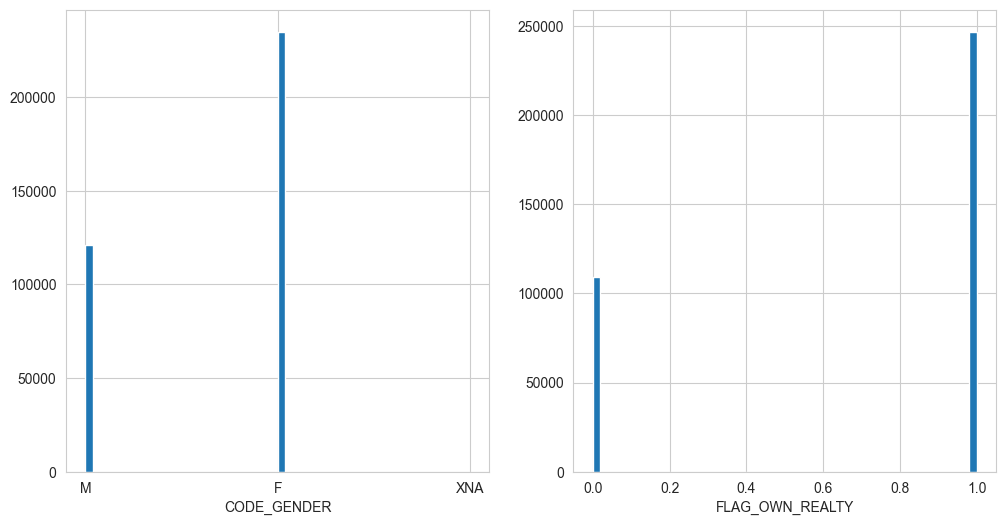

In [335]:
domain_features=['CODE_GENDER', 'FLAG_OWN_REALTY']

fig, axs = plt.subplots(1, 2, figsize=(12,6))
i = 0
for feature in domain_features :
    i += 1
    plt.subplot(1, 2, i)
    df[feature].hist(bins=50)
    plt.xlabel(feature)


In [336]:
df['CODE_GENDER'].value_counts()

CODE_GENDER
F      235126
M      121125
XNA         4
Name: count, dtype: int64

In [ ]:
# one-hot encoding
df = pd.get_dummies(df, columns=['CODE_GENDER'], dtype=int)

In [339]:
df.iloc[:, 144:].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   CODE_GENDER_F    356255 non-null  int32
 1   CODE_GENDER_M    356255 non-null  int32
 2   CODE_GENDER_XNA  356255 non-null  int32
dtypes: int32(3)
memory usage: 4.1 MB


### Distribution des features

In [382]:
# From https://www.kaggle.com/code/seifmechi/credit-default-risk

def plot_distribution(df, FEATURES):
    i = 0
    t1 = df.loc[df['TARGET'] != 0]
    t0 = df.loc[df['TARGET'] == 0]
    
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(5, 2, figsize=(16, 20), layout='constrained')

    for feature in FEATURES:
        if feature != 'TARGET':
            i += 1
            plt.subplot(5, 2, i)
#            sns.kdeplot(t1[feature], bw_method=0.5, color='red', label="TARGET = 1")
#            sns.kdeplot(t0[feature], bw_method=0.5, label="default = 0")
            plt.hist([t1[feature], t0[feature]], density=True, label=['Target', 'No target'])
            plt.ylabel('Density distribution', fontsize=12)
            plt.xlabel(feature, fontsize=12)
            plt.xticks(fontsize=12, rotation=90)  # Set the font size for x-axis labels
            plt.yticks(fontsize=12)  # Set the font size for y-axis labels
            plt.legend()

    plt.tight_layout()  # Adjust the spacing between subplots
    plt.show()



In [361]:
domain_features=['DAYS_BIRTH', 'CODE_GENDER_F', 'FLAG_RISKED_ORGANIZATION_TYPE', 
                 'RATIO_INCOME_TO_FAM_MEMBERS', 'FLAG_STABLE_INCOME_TYPE',
                 'FLAG_OWN_REALTY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
                ]

C:\Users\innov\AppData\Local\Temp\ipykernel_17836\2186146958.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()  # Adjust the spacing between subplots


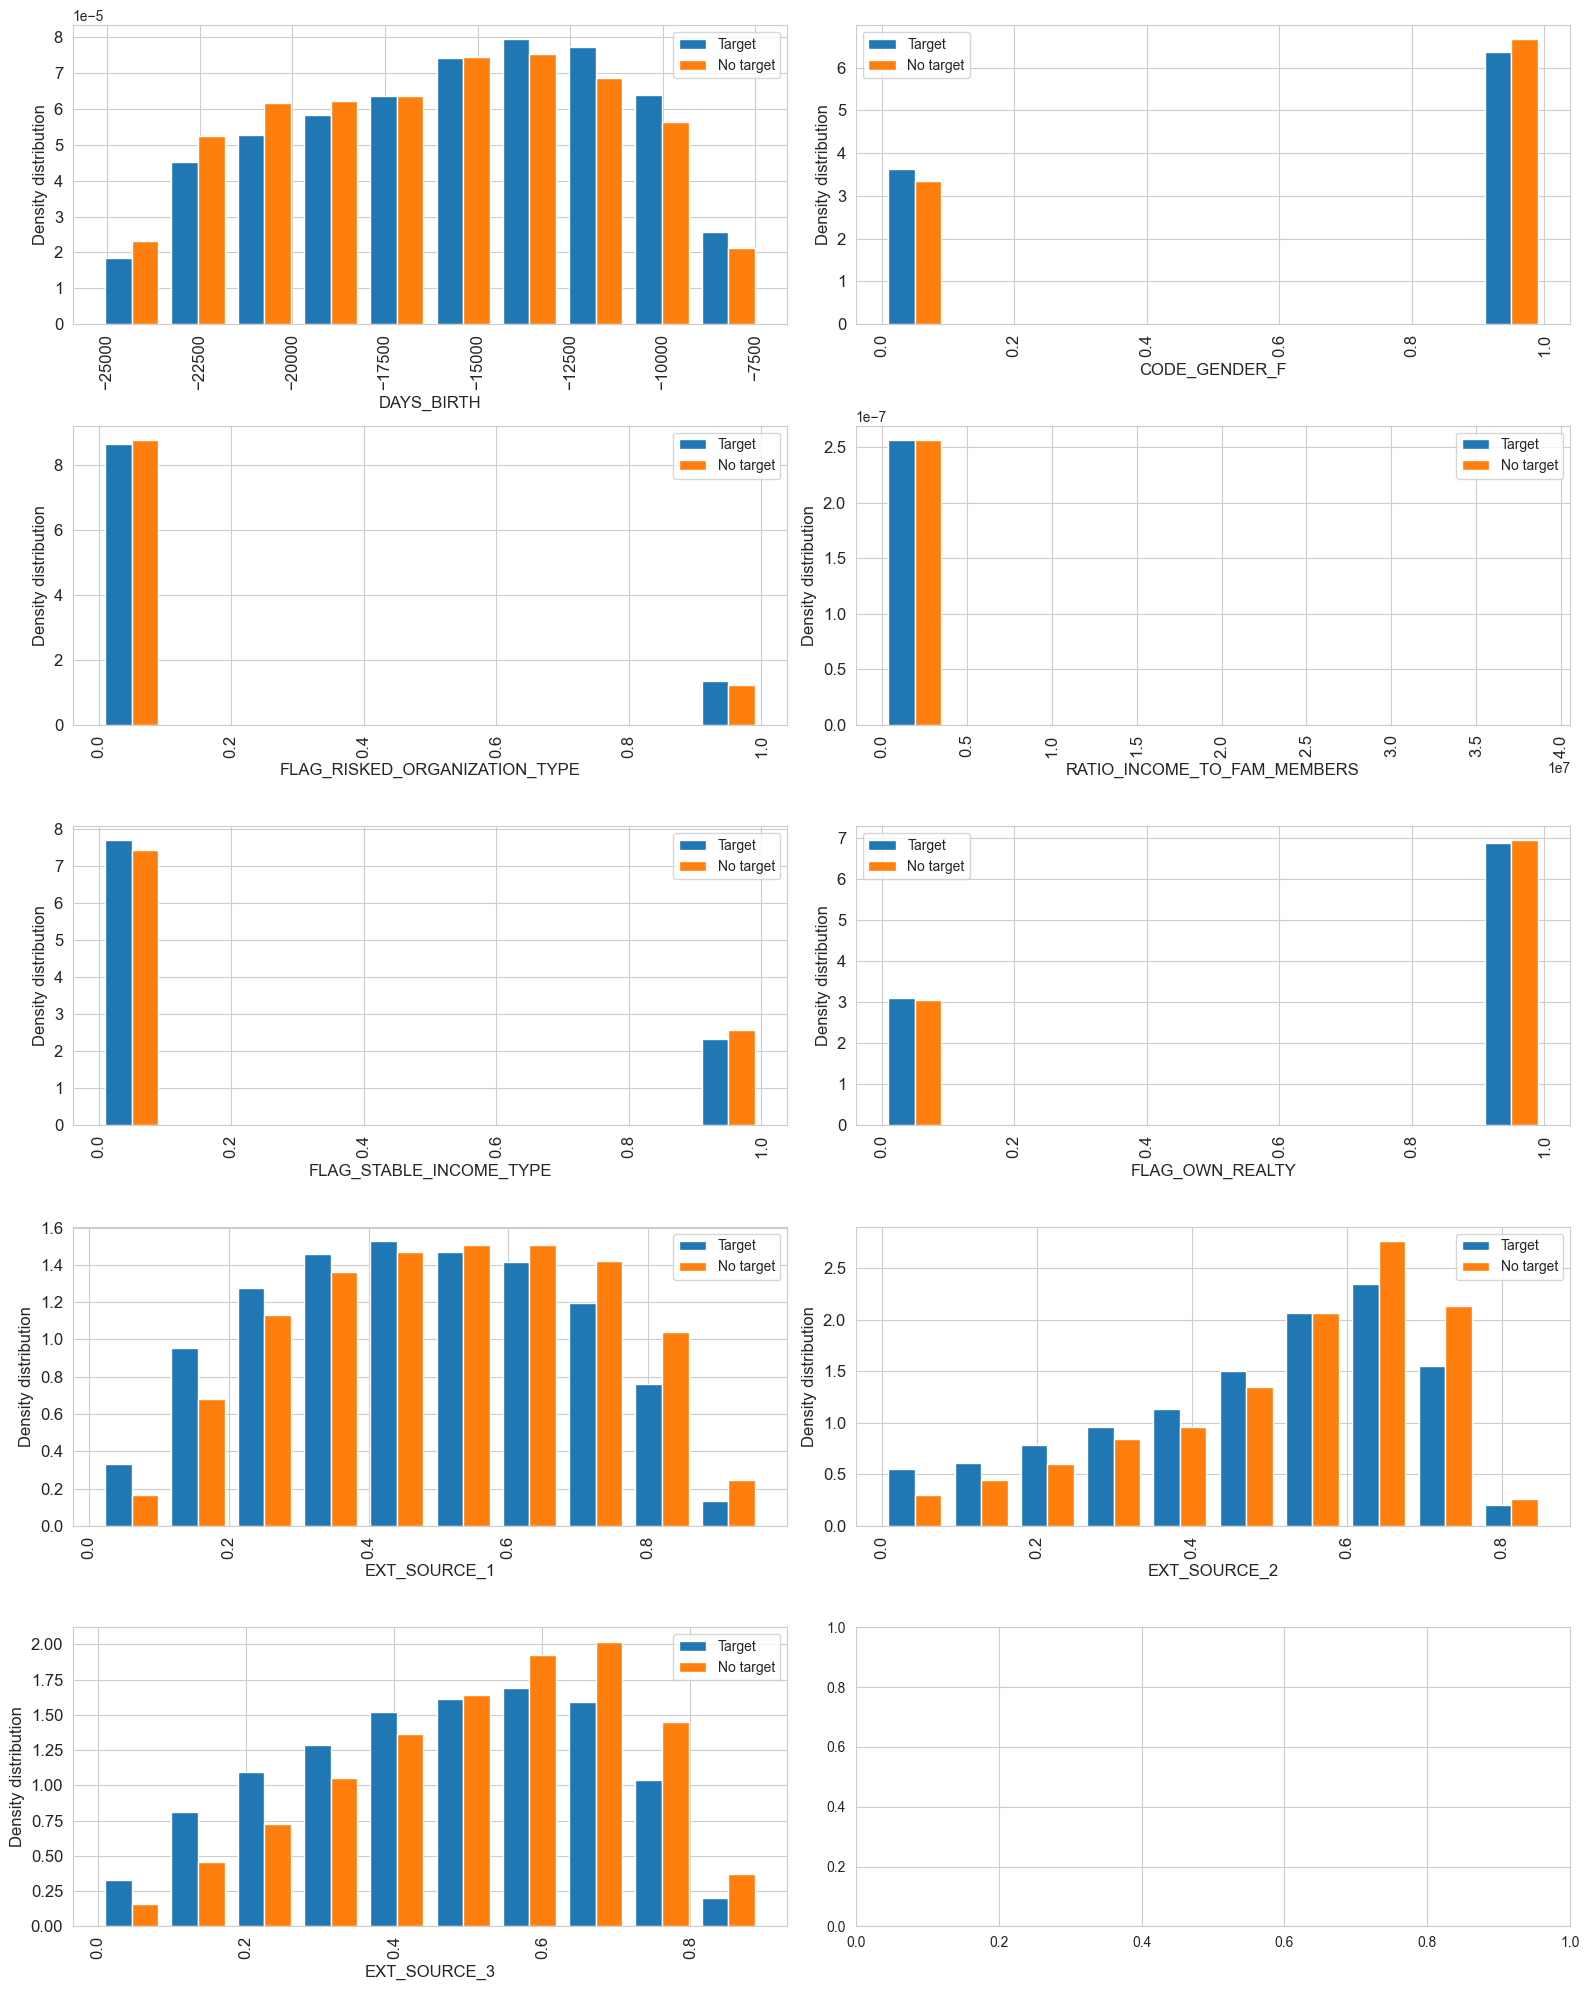

In [362]:
plot_distribution(df,domain_features)

In [363]:
df[domain_features].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   DAYS_BIRTH                     356255 non-null  int64  
 1   CODE_GENDER_F                  356255 non-null  int32  
 2   FLAG_RISKED_ORGANIZATION_TYPE  356255 non-null  int64  
 3   RATIO_INCOME_TO_FAM_MEMBERS    356255 non-null  float64
 4   FLAG_STABLE_INCOME_TYPE        356255 non-null  int64  
 5   FLAG_OWN_REALTY                356255 non-null  object 
 6   EXT_SOURCE_1                   162345 non-null  float64
 7   EXT_SOURCE_2                   355587 non-null  float64
 8   EXT_SOURCE_3                   286622 non-null  float64
dtypes: float64(4), int32(1), int64(3), object(1)
memory usage: 23.1+ MB


In [354]:
df[domain_features].describe()

,DAYS_BIRTH,CODE_GENDER_F,FLAG_RISKED_ORGANIZATION_TYPE,RATIO_INCOME_TO_FAM_MEMBERS,FLAG_STABLE_INCOME_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,356255.000000,356255.000000,356255.000000,3.562550e+05,356255.000000,162345.000000,3.555870e+05,286622.000000
mean,-16041.248841,0.659994,0.124439,9.378760e+04,0.252263,0.501965,5.148900e-01,0.509350
std,4358.803980,0.473712,0.330082,9.810257e+04,0.434312,0.210045,1.897531e-01,0.194141
min,-25229.000000,0.000000,0.000000,2.812500e+03,0.000000,0.013458,8.173617e-08,0.000527
25%,-19676.000000,0.000000,0.000000,4.950000e+04,0.000000,0.335503,3.949551e-01,0.368969
50%,-15755.000000,1.000000,0.000000,7.500000e+04,0.000000,0.506155,5.648491e-01,0.533482
75%,-12425.000000,1.000000,0.000000,1.125000e+05,1.000000,0.673344,6.629285e-01,0.665855
max,-7338.000000,1.000000,1.000000,3.900000e+07,1.000000,0.962693,8.549997e-01,0.896010


### Imputation External_source

In [366]:
df['EXT_SOURCE_1'] = df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_1'].mean())
df['EXT_SOURCE_2'] = df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_2'].mean())
df['EXT_SOURCE_3'] = df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_3'].mean())

In [367]:
df[domain_features].describe()

,DAYS_BIRTH,CODE_GENDER_F,FLAG_RISKED_ORGANIZATION_TYPE,RATIO_INCOME_TO_FAM_MEMBERS,FLAG_STABLE_INCOME_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,356255.000000,356255.000000,356255.000000,3.562550e+05,356255.000000,356255.000000,3.562550e+05,356255.000000
mean,-16041.248841,0.659994,0.124439,9.378760e+04,0.252263,0.501965,5.148900e-01,0.509350
std,4358.803980,0.473712,0.330082,9.810257e+04,0.434312,0.141792,1.895751e-01,0.174137
min,-25229.000000,0.000000,0.000000,2.812500e+03,0.000000,0.013458,8.173617e-08,0.000527
25%,-19676.000000,0.000000,0.000000,4.950000e+04,0.000000,0.501965,3.954098e-01,0.413597
50%,-15755.000000,1.000000,0.000000,7.500000e+04,0.000000,0.501965,5.643868e-01,0.509350
75%,-12425.000000,1.000000,0.000000,1.125000e+05,1.000000,0.501965,6.627672e-01,0.634706
max,-7338.000000,1.000000,1.000000,3.900000e+07,1.000000,0.962693,8.549997e-01,0.896010


C:\Users\innov\AppData\Local\Temp\ipykernel_17836\2186146958.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()  # Adjust the spacing between subplots


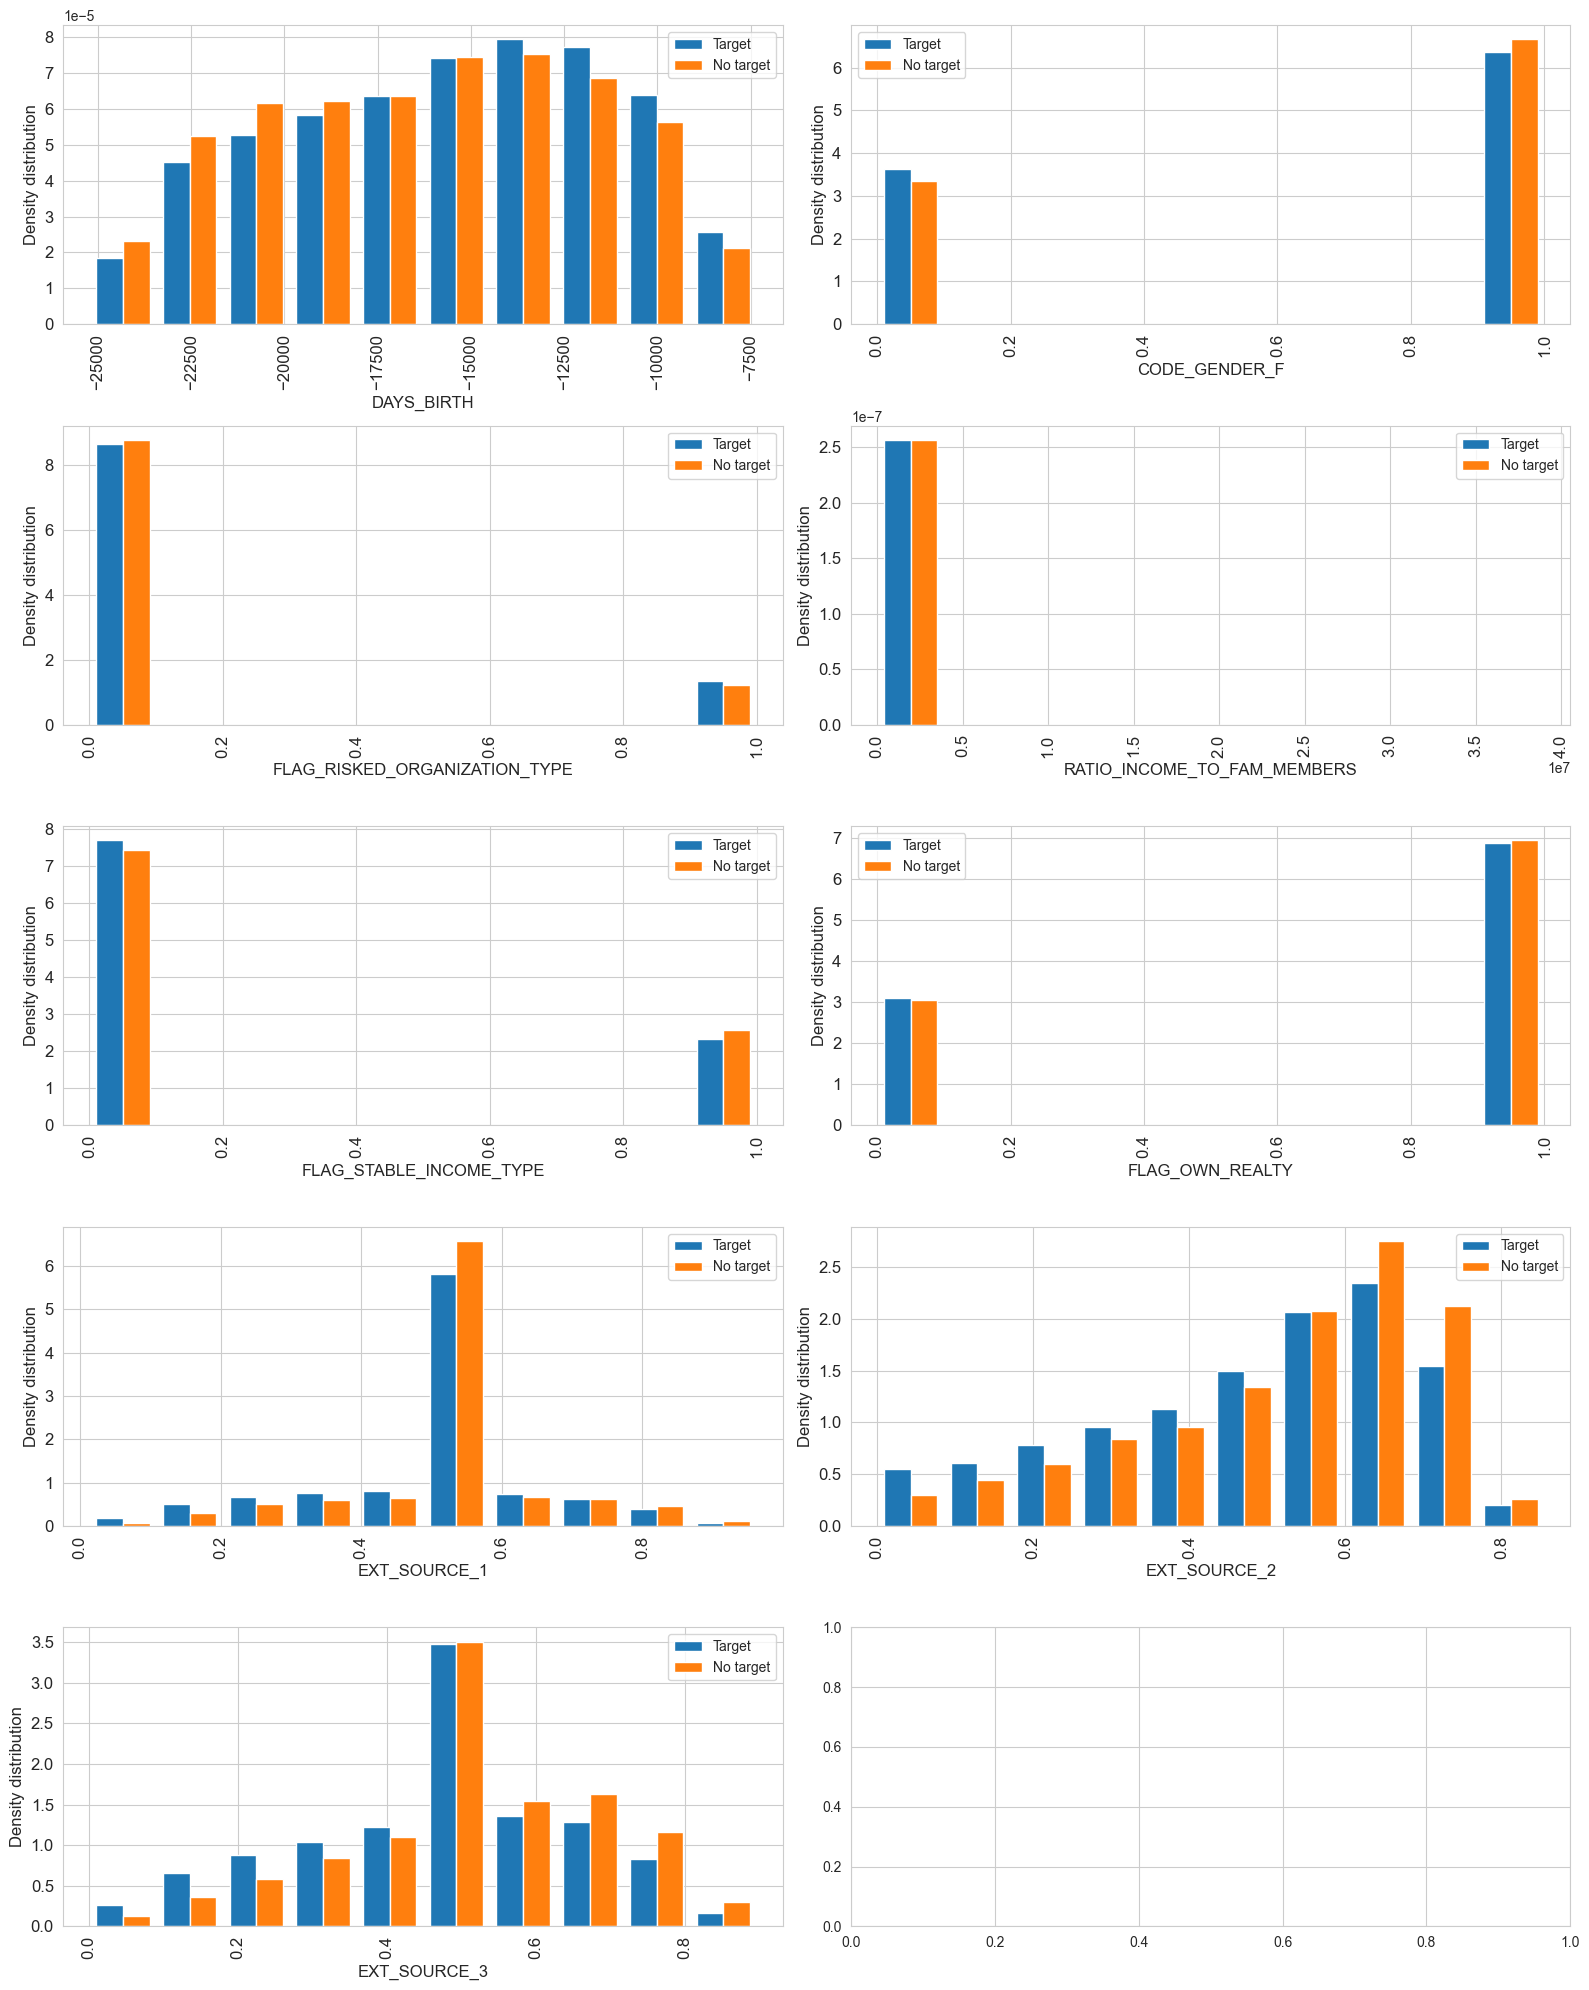

In [368]:
plot_distribution(df,domain_features)

### Outliers Revenu

Text(0.5, 0, 'RATIO_INCOME_TO_FAM_MEMBERS')

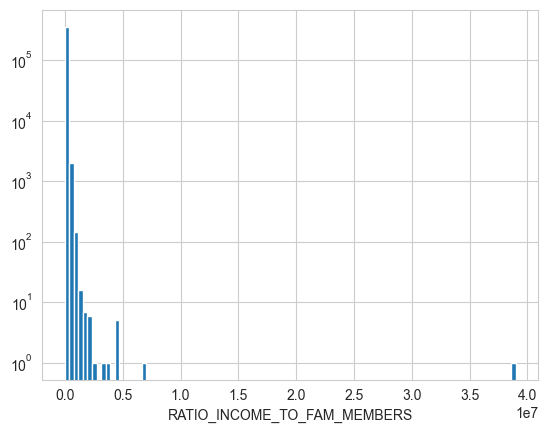

In [371]:
df['RATIO_INCOME_TO_FAM_MEMBERS'].hist(bins=100, log=True)
plt.xlabel('RATIO_INCOME_TO_FAM_MEMBERS')

In [373]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Columns: 147 entries, index to CODE_GENDER_XNA
dtypes: float64(85), int32(5), int64(43), object(14)
memory usage: 392.8+ MB


In [374]:
# Suppression 1 outlier :
df = df.loc[df['RATIO_INCOME_TO_FAM_MEMBERS'] <= 3.5E7]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356254 entries, 0 to 356254
Columns: 147 entries, index to CODE_GENDER_XNA
dtypes: float64(85), int32(5), int64(43), object(14)
memory usage: 395.5+ MB


Text(0.5, 0, 'RATIO_INCOME_TO_FAM_MEMBERS')

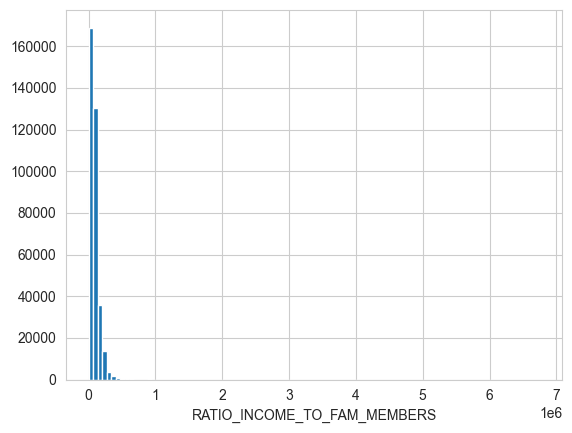

In [381]:
df['RATIO_INCOME_TO_FAM_MEMBERS'].hist(bins=100, log=False)
plt.xlabel('RATIO_INCOME_TO_FAM_MEMBERS')

C:\Users\innov\AppData\Local\Temp\ipykernel_17836\2186146958.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()  # Adjust the spacing between subplots


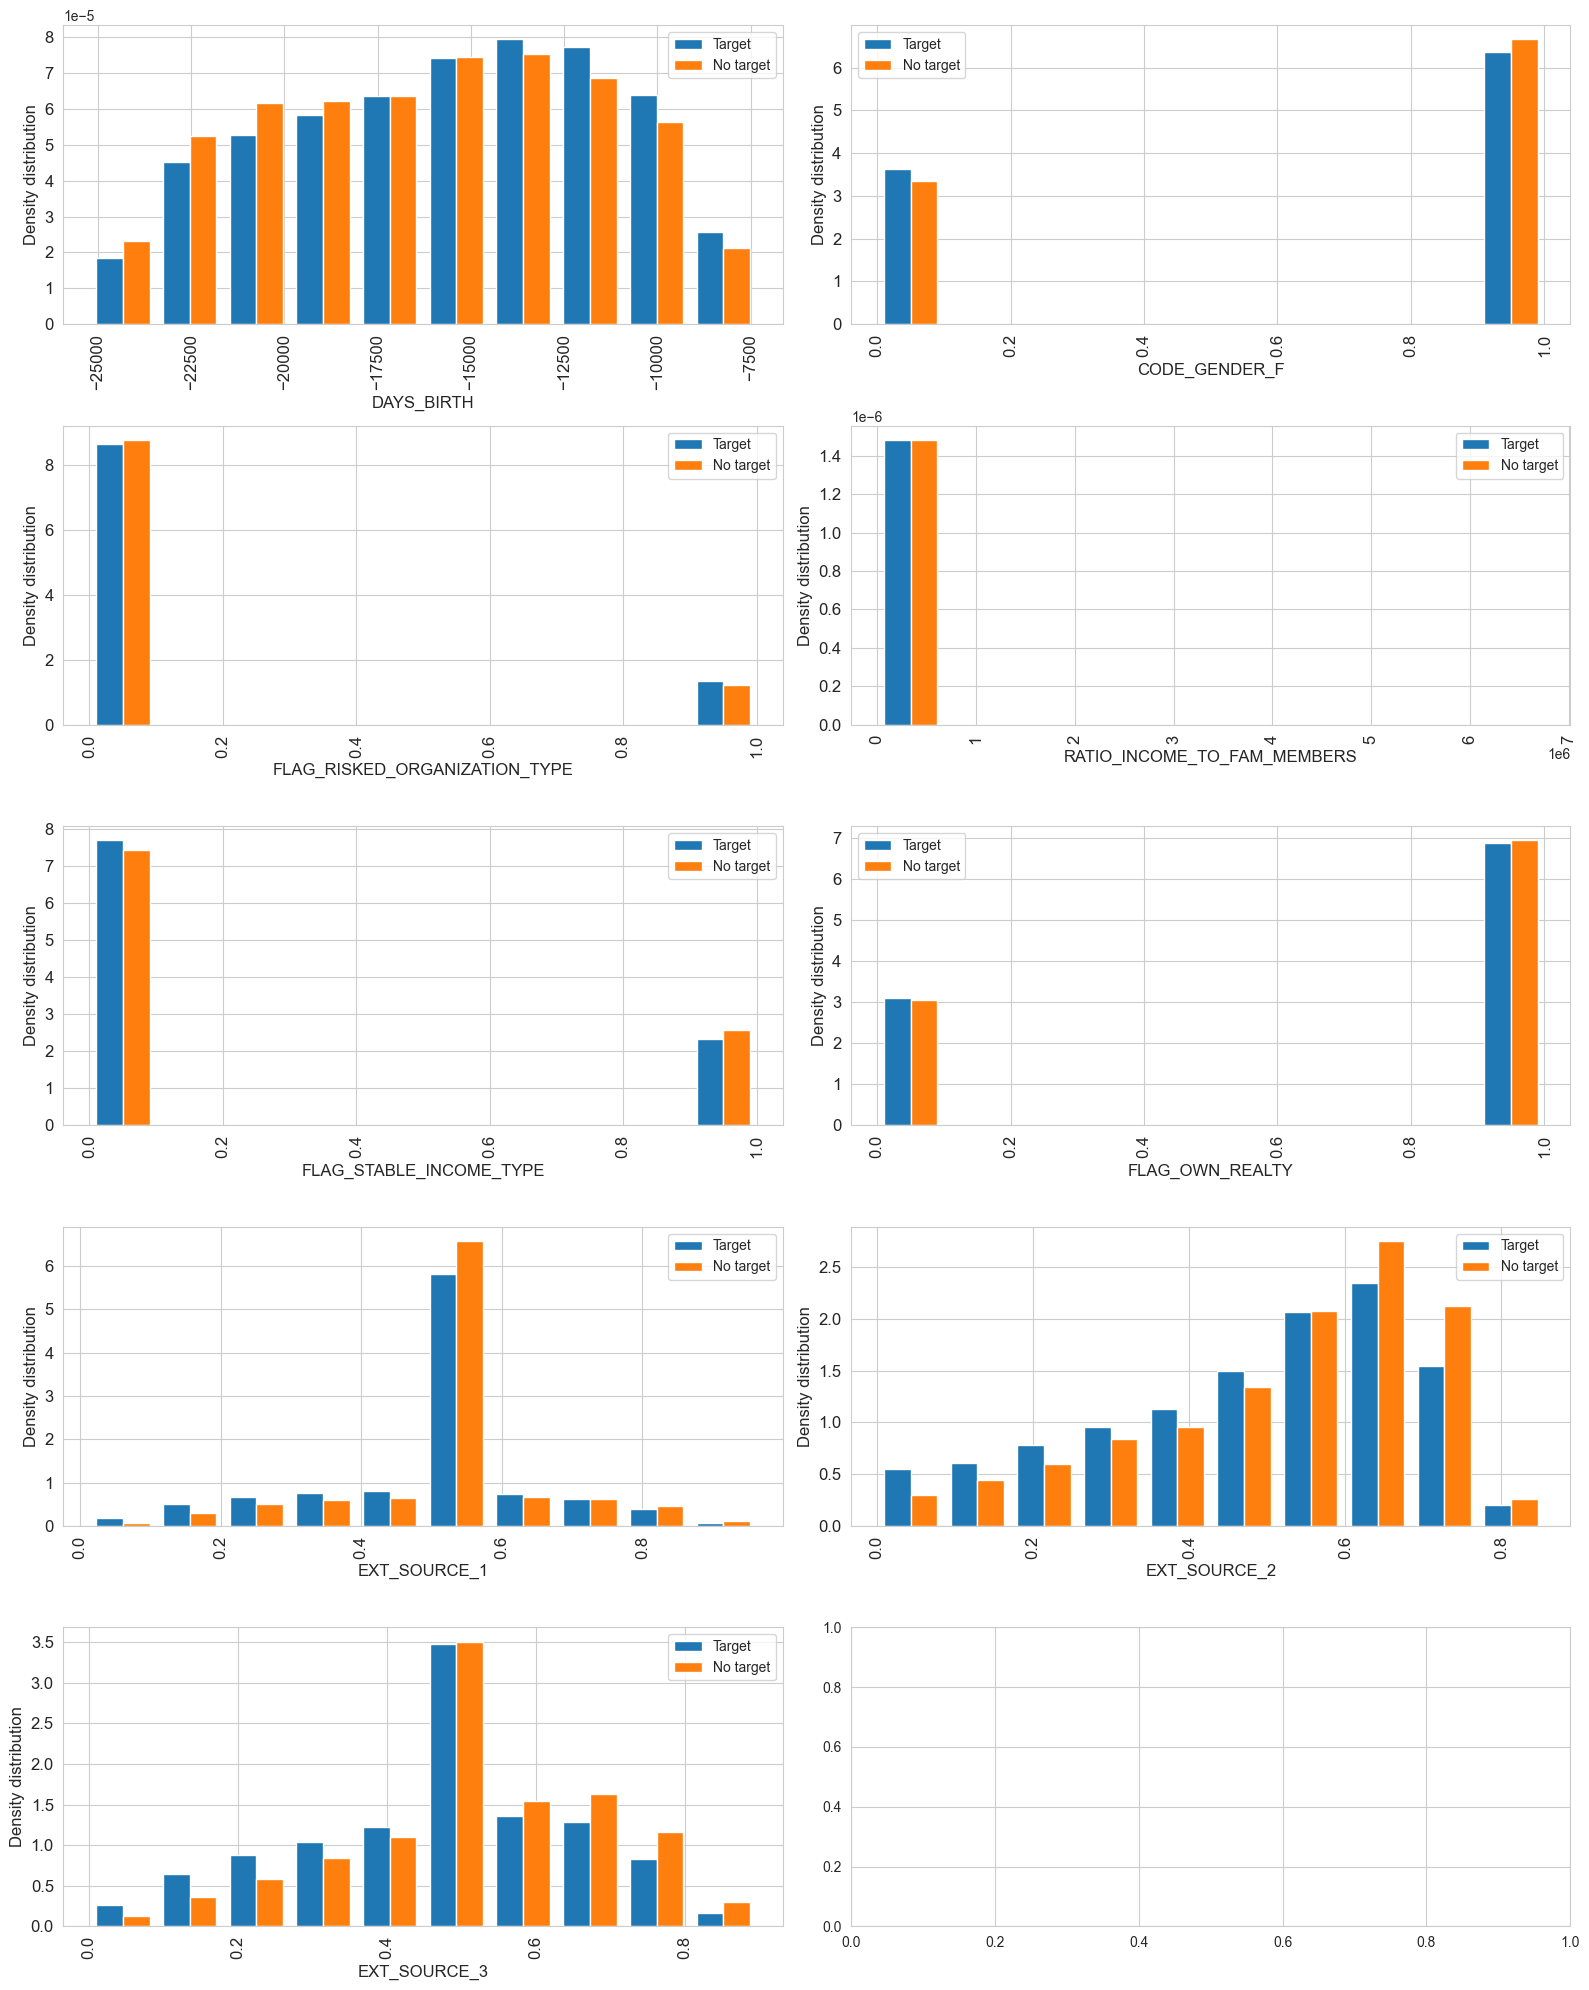

In [383]:
plot_distribution(df,domain_features)

## Son historique des crédits

In [384]:
df.iloc[:, 130:].info()

<class 'pandas.core.frame.DataFrame'>
Index: 356254 entries, 0 to 356254
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   AMT_PREV_SUM            356254 non-null  float64
 1   AMT_PREV_SUM_DEBT       356254 non-null  float64
 2   AMT_PREV_SUM_OVERDUE    356254 non-null  float64
 3   AMT_PREV_MAX_OVERDUE    356254 non-null  float64
 4   CNT_CREDIT              356254 non-null  float64
 5   AMT_CREDIT_SUM          356254 non-null  float64
 6   AMT_CREDIT_SUM_DEBT     356254 non-null  float64
 7   AMT_CREDIT_SUM_OVERDUE  356254 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  356254 non-null  float64
 9   CNT_ALL                 356254 non-null  float64
 10  AMT_ALL_SUM             356254 non-null  float64
 11  AMT_ALL_SUM_DEBT        356254 non-null  float64
 12  AMT_ALL_SUM_OVERDUE     356254 non-null  float64
 13  AMT_ALL_MAX_OVERDUE     356254 non-null  float64
 14  CODE_GENDER_F           3

In [409]:
domain_features=['AMT_ALL_SUM', 'CNT_ALL', 'AMT_ALL_SUM_DEBT', 'AMT_ALL_SUM_OVERDUE', 'AMT_ALL_MAX_OVERDUE']

C:\Users\innov\AppData\Local\Temp\ipykernel_17836\2186146958.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()  # Adjust the spacing between subplots


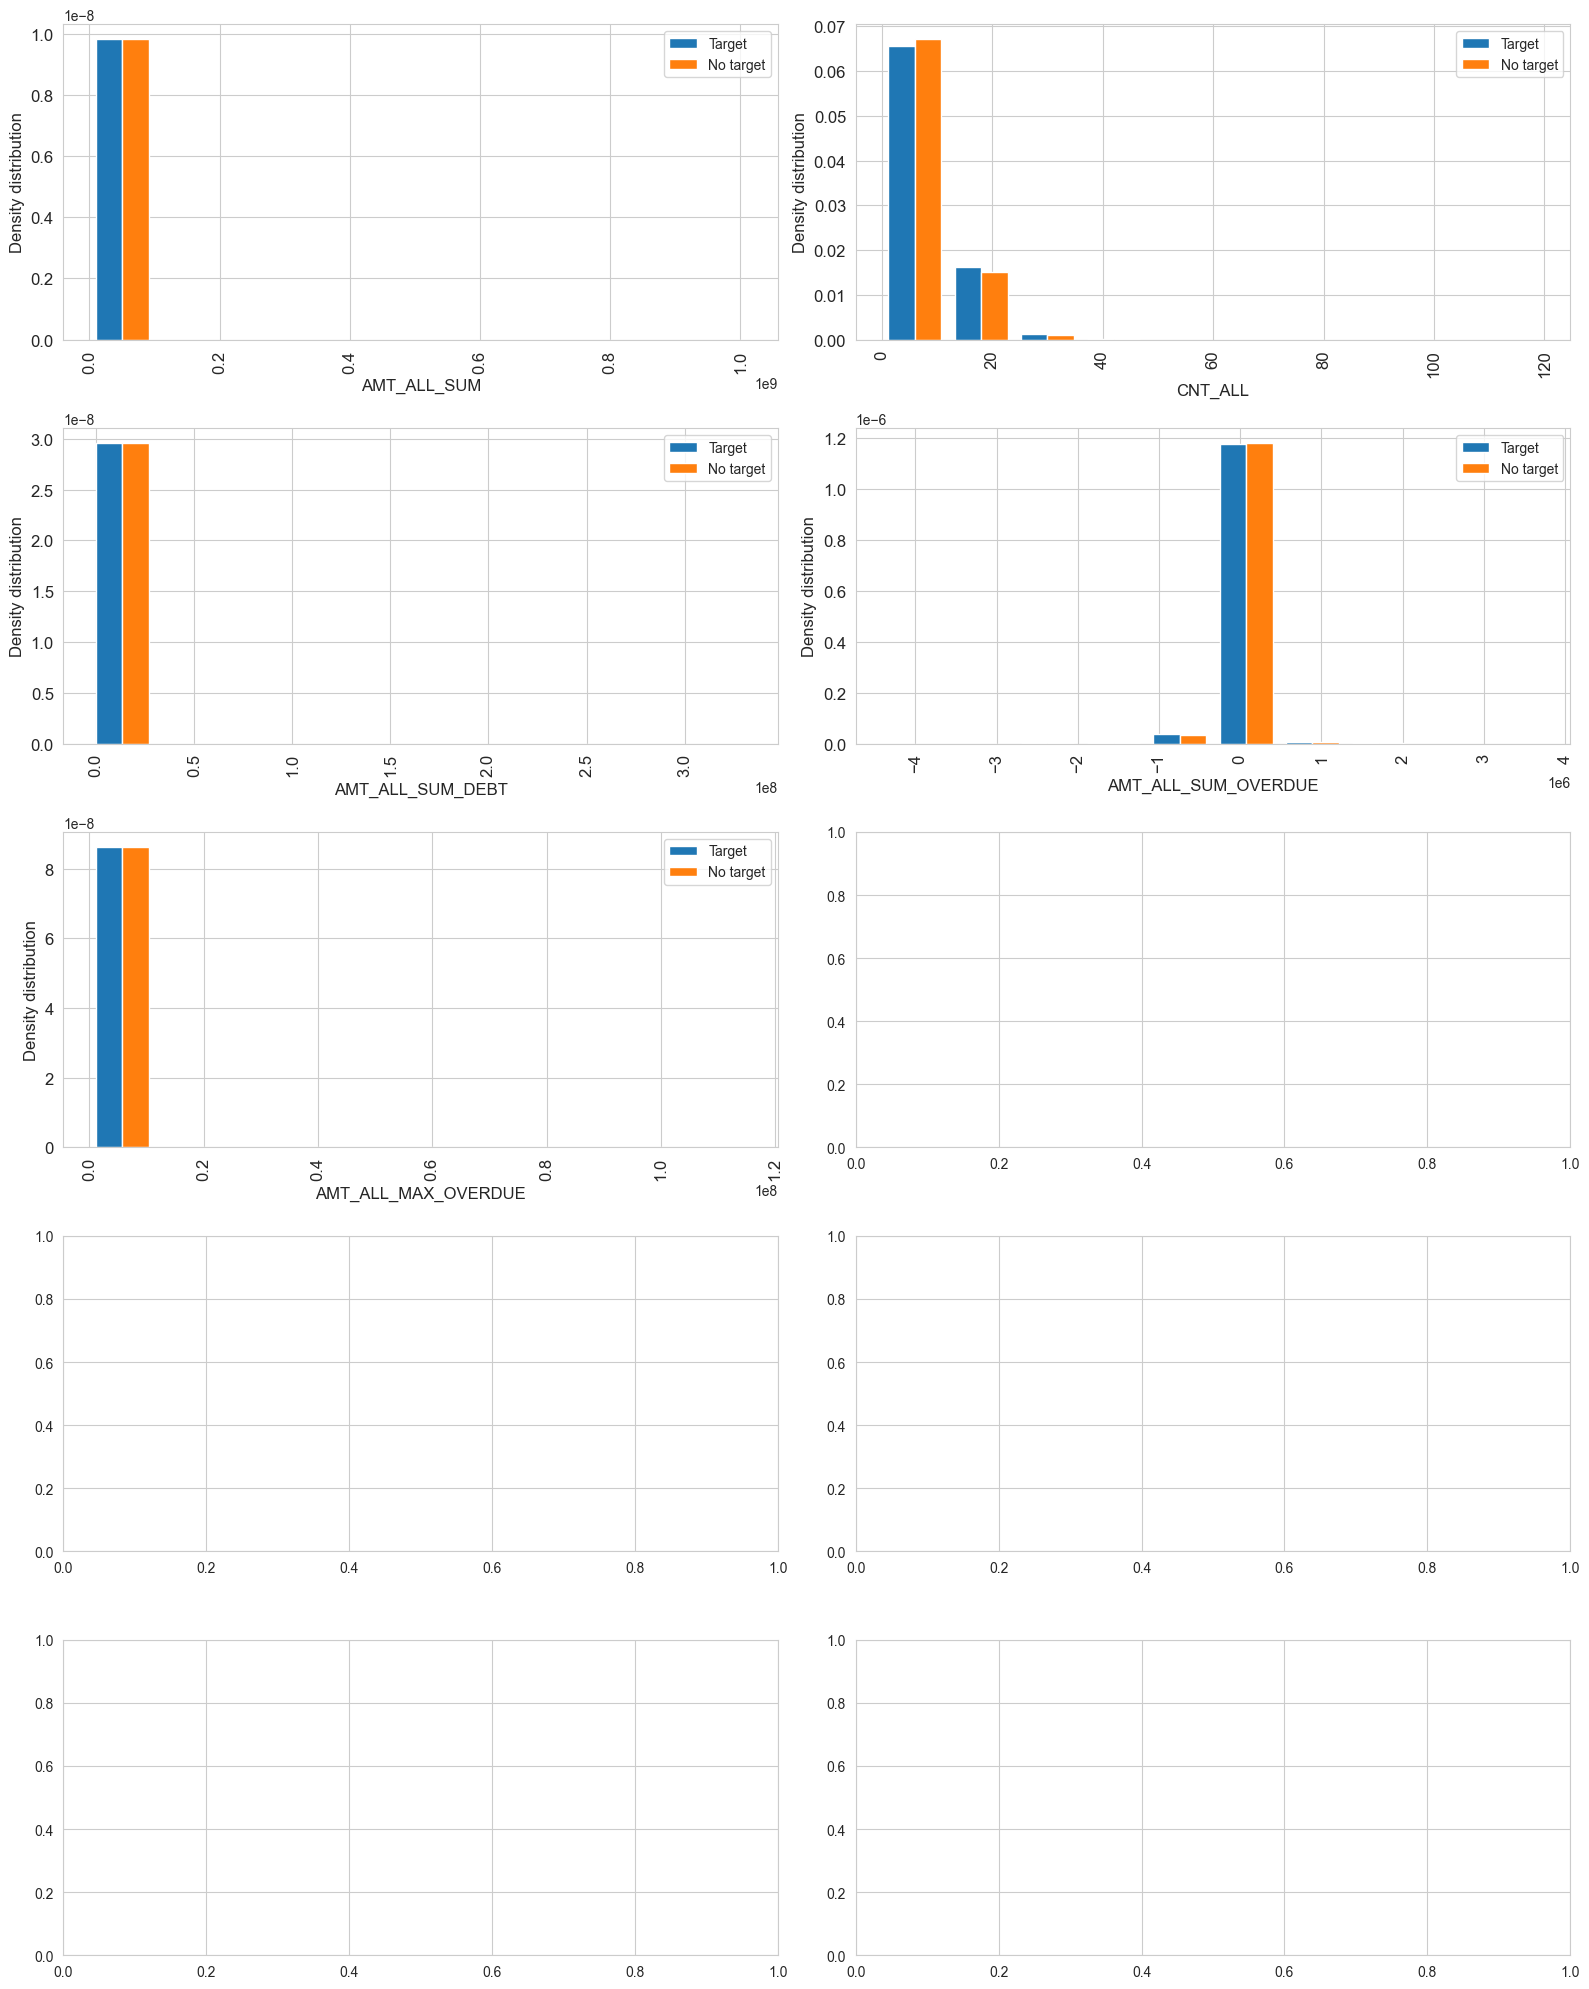

In [410]:
plot_distribution(df,domain_features)

In [406]:
# Montant moyen crédit
mask = df['CNT_ALL'] > 0
df['AMT_ALL_SUM_MEAN'] = df.loc[mask, 'AMT_ALL_SUM'] / df.loc[mask, 'CNT_ALL']
df['AMT_ALL_SUM_MEAN'] = df['AMT_ALL_SUM_MEAN'].fillna(0)

In [407]:
# Ratio défaut de paiement
df['RATIO_ALL_SUM_OVERDUE_TO_INCOME'] = df['AMT_ALL_SUM_OVERDUE'] / df['AMT_INCOME_TOTAL']

In [405]:
# Ratio Max overdue mensuel par rapport au revenu mensuel
df['RATIO_ALL_MAX_OVERDUE_TO_INCOME'] = df['AMT_ALL_MAX_OVERDUE'] / (df['AMT_INCOME_TOTAL'] / 12)

In [411]:
# Ratio d'endettement
df['RATIO_ALL_SUM_DEBT_TO_INCOME'] = df['AMT_ALL_SUM_DEBT'] / df['AMT_INCOME_TOTAL']

In [412]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 356254 entries, 0 to 356254
Data columns (total 151 columns):
 #    Column                               Non-Null Count   Dtype  
---   ------                               --------------   -----  
 0    index                                356254 non-null  int64  
 1    SK_ID_CURR                           356254 non-null  int64  
 2    TARGET                               307510 non-null  float64
 3    FLAG_OWN_CAR                         356254 non-null  object 
 4    FLAG_OWN_REALTY                      356254 non-null  object 
 5    CNT_CHILDREN                         356254 non-null  int64  
 6    AMT_INCOME_TOTAL                     356254 non-null  float64
 7    AMT_CREDIT                           356254 non-null  float64
 8    AMT_ANNUITY                          356218 non-null  float64
 9    AMT_GOODS_PRICE                      356254 non-null  float64
 10   NAME_TYPE_SUITE                      354051 non-null  object 
 11   NAM

In [413]:
domain_features=['AMT_ALL_SUM_MEAN', 'RATIO_ALL_SUM_DEBT_TO_INCOME', 'RATIO_ALL_SUM_OVERDUE_TO_INCOME', 'RATIO_ALL_MAX_OVERDUE_TO_INCOME']

C:\Users\innov\AppData\Local\Temp\ipykernel_17836\2186146958.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()  # Adjust the spacing between subplots


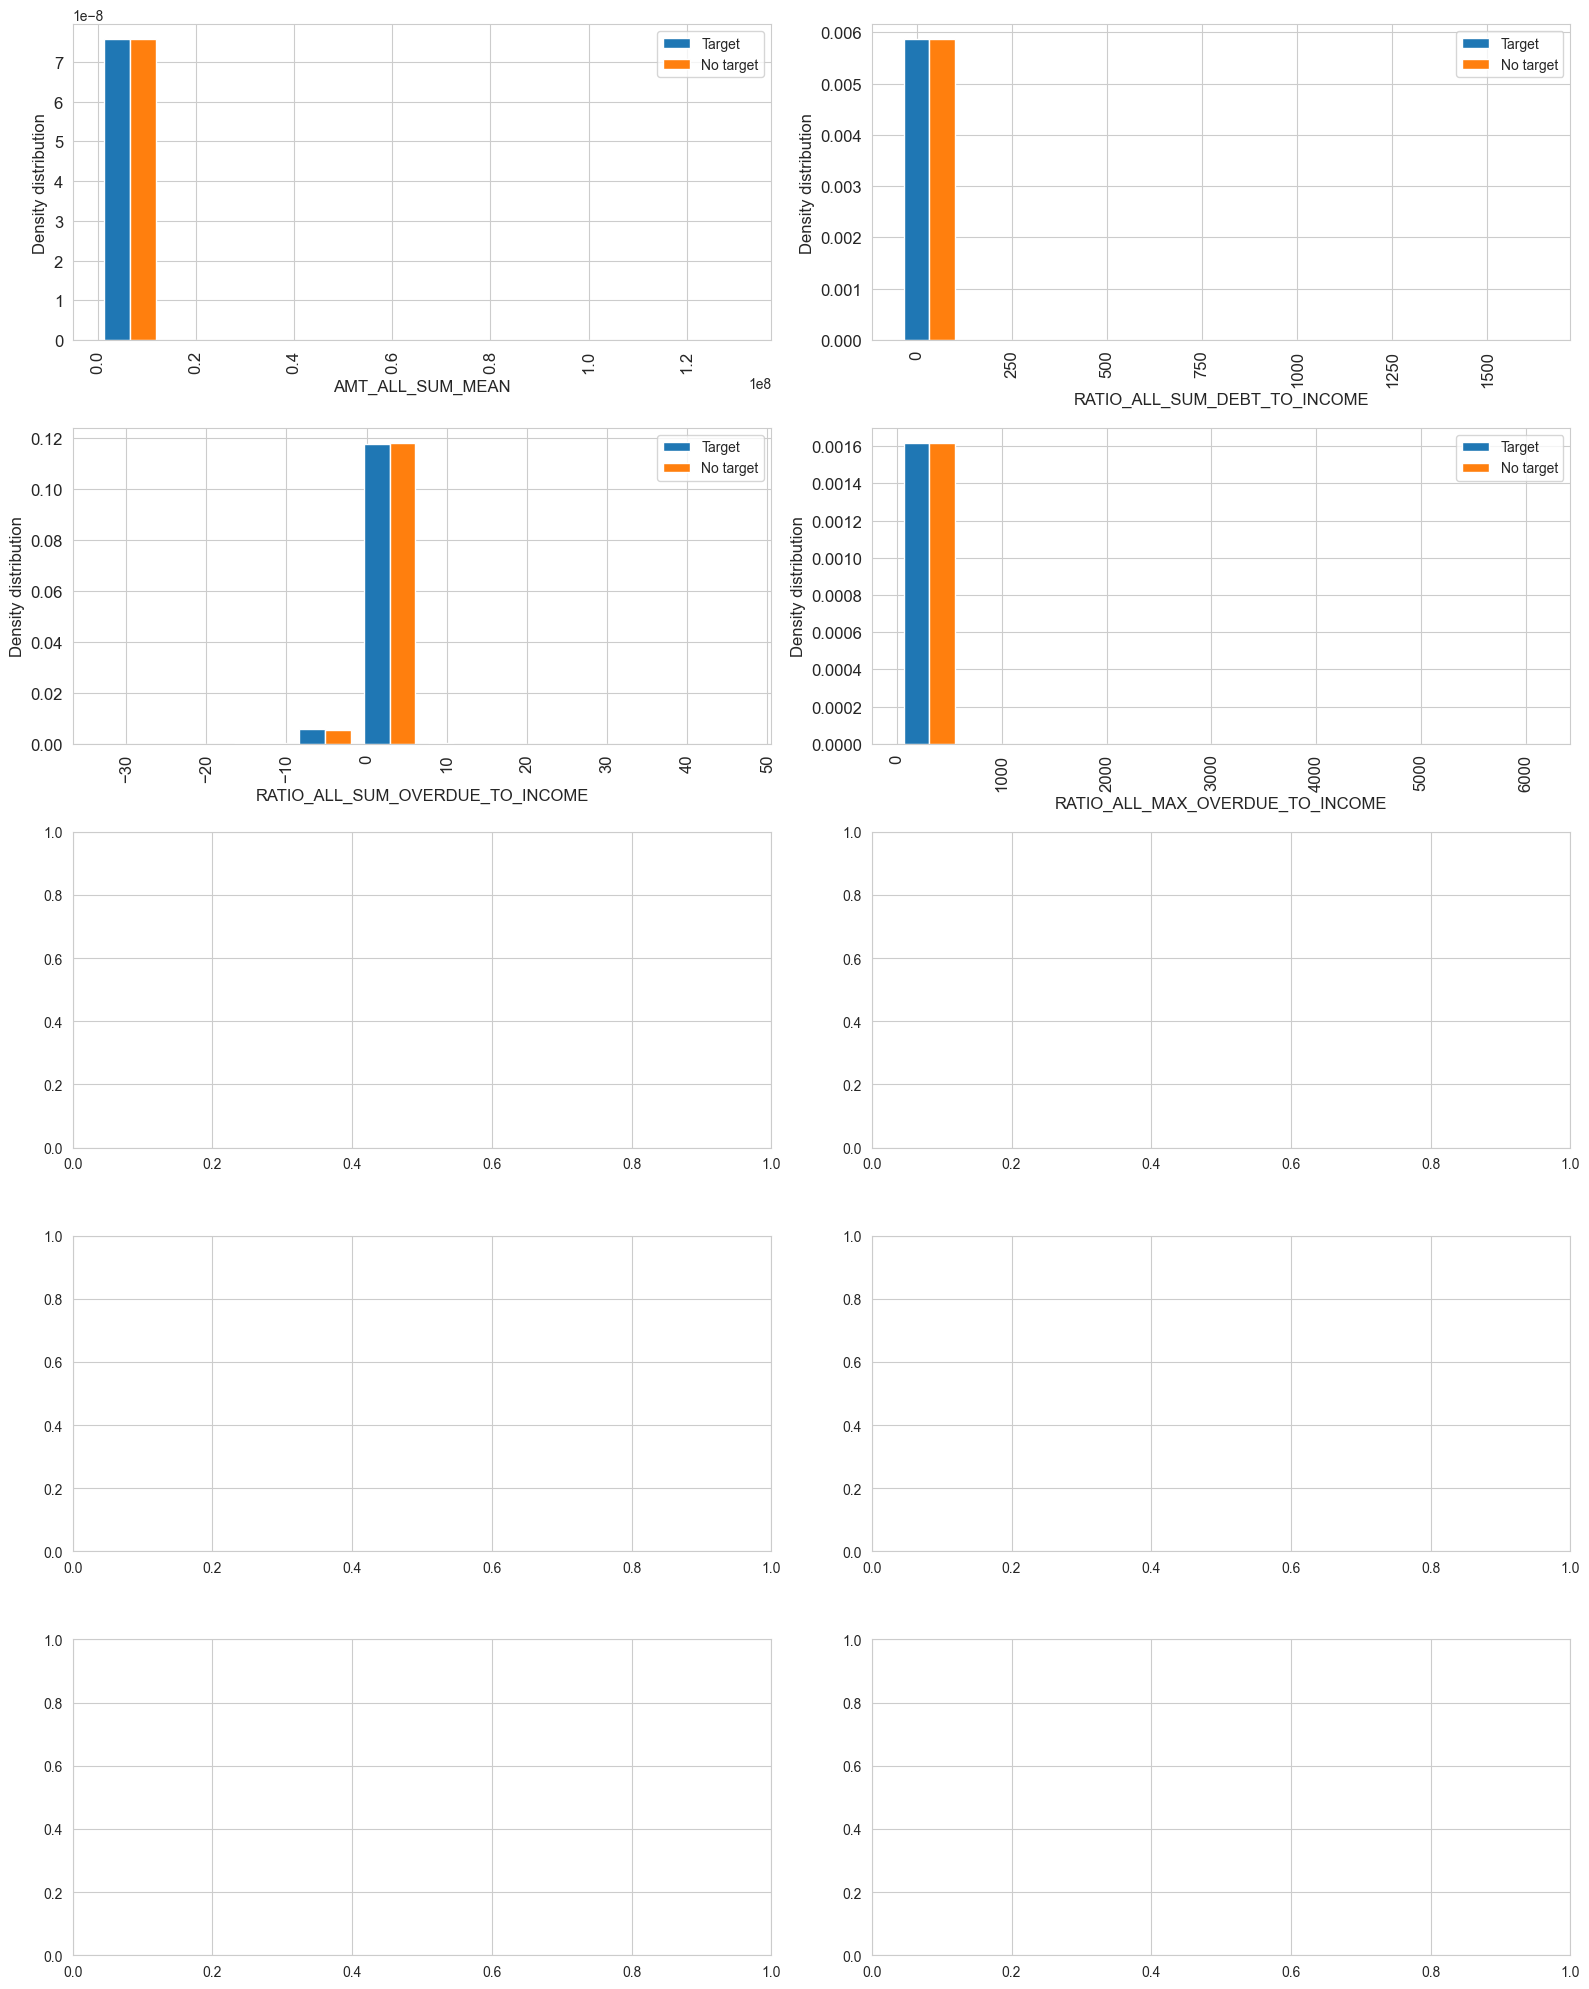

In [414]:
plot_distribution(df,domain_features)

In [7]:
# Sauvegarde df
# df.to_csv('./input/df_20250102.csv')

In [8]:
# df = pd.read_csv('./input/df_20250102.csv')

# Séparatation train vs test

In [11]:
df_test = df.loc[df['TARGET'].isna(), :]
df_train = df.loc[~df['TARGET'].isna(), :]
print("Train samples: {}, test samples: {}".format(len(df_train), len(df_test)))
df_train.to_csv('./input/application_train_20250103.csv')
df_test.to_csv('./input/application_test_20250103.csv')

Train samples: 307510, test samples: 48744
